In [6]:
# ==============================================================================
# 시스템명: 전 수계 통합 오염원인 자동 스크리닝 및 자기 최적화 시스템 
# 연구목적: 안정동위원소 결합 오염평가 체계 고도화를 위한 국가 수질측정망 적용 연구
# 주요업데이트: 
#   1. Variational Autoencoder(VAE) 도입으로 잠재공간(Latent Space) 기하학적 응집도 극대화
#   2. CINN(Chemistry-Informed) 도메인 손실 함수 적용 (물리/화학적 질량보존 제약조건 반영)
#   3. 복합 앙상블 평가지표(Consensus Score = Silhouette + DBI + CHI) 기반 K-선택 자동화
#   4. Fallback 로직이 대폭 강화된 범용적 오염원 판별 엔진 및 시각화 결과물 자동 저장
# ============================================================================== 

# ------------------------------------------------------------------------------
# 0. 환경 구축 및 패키지 임포트 
# ------------------------------------------------------------------------------
!pip install torch pandas numpy scikit-learn matplotlib adjustText seaborn hdbscan

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import hdbscan
import warnings
import datetime
import random
import math
import shap
import os
import warnings
import traceback

from scipy.stats import norm, linregress
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics.pairwise import pairwise_distances
from adjustText import adjust_text

In [8]:
# 환경 설정 및 재현성 확보
warnings.filterwarnings('ignore')
candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']
available = {f.name for f in fm.fontManager.ttflist}
plt.rcParams['font.family'] = next((c for c in candidates if c in available), 'DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

SEED = 3606
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)            # GPU 사용 시
torch.backends.cudnn.deterministic = True   # CUDA 비결정성 차단
torch.backends.cudnn.benchmark = False

In [9]:
# 시각화 결과를 저장할 디렉토리 생성
out_dir = "Screening_Results"
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
current_time = datetime.datetime.now().strftime("%y%m%d_%H%M")

In [10]:
# ------------------------------------------------------------------------------
# 1. 데이터 전처리 (Data Pre-processing)
# 방법론: ROS (Regression on Order Statistics) & KNN Imputation & Z-score Normalization
# 설명: 수질 및 환경 데이터의 결측치(NA)는 대부분 기기 검출한계 미만(LOD)인 
#       '좌측 절단 데이터(Left-Censored Data)'의 특성을 가집니다. 
#       단순 평균이나 KNN만 선행 적용할 경우 하위 분포의 통계적 왜곡이 발생할 수 있으므로,
#       R의 NADA 패키지 로직을 차용하여 ROS 기법을 1차적으로 적용합니다.
#       데이터 다양성 부족이나 통계적 에러 발생 시 다차원 특성을 보존하는 KNN으로 안전하게 우회합니다.
# ------------------------------------------------------------------------------
print("[*] 1단계: 데이터 로드 및 5대 핵심 파생 변수 생성 진행 중...")
df = pd.read_csv('C:/Users/Hi/Desktop/문헌 기반 시스템 업데이트/특이측정값(3~5월).csv', encoding='euc-kr') 

# [안전장치] 연산 에러를 방지하기 위해 계산에 사용될 주요 컬럼들을 먼저 숫자형으로 안전하게 변환
calc_cols = ['TN', 'TP', 'TOC', 'Cl', 'd15N', 'd18O', 'NH3N', 'NO3N']
for col in calc_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ==============================================================================
# [고도화 반영] 수질 오염원 정밀 스크리닝을 위한 6대 파생 변수 사전 생성 
# ==============================================================================
df['TN/TP']       = df['TN'] / df['TP']
df['TOC/TN']      = df['TOC'] / df['TN']
df['Cl/TN']       = df['Cl'] / df['TN']
df['d15N/d18O']   = df['d15N'] / df['d18O']
df['NH3N/NO3N']   = df['NH3N'] / df['NO3N']
df['NO3N/Cl']     = df['NO3N'] / df['Cl']

# [필수 에러 방어] 분모가 0이거나 결측치 연산으로 인해 발생한 무한대(inf) 값을 NaN으로 일괄 대체
# 이렇게 해야 뒤이은 KNN Imputer가 결측치로 인식하여 깔끔하게 통계적 대치를 수행합니다.
import numpy as np
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 'spot' 변수를 제외하고 분석에 활용할 수질 및 안정동위원소 피처만 분리 
features_df = df.drop(columns=['spot'])

# [에러 방어 2] 전체 데이터를 강제로 숫자형(Numeric)으로 최종 변환 (변환 불가 시 NaN 처리)
features_df = features_df.apply(pd.to_numeric, errors='coerce')

print(f" -> 파생 변수 생성 완료! 분석 대상 수질 인자 수: {features_df.shape[1]}개")

# ---------------------------------------------------------
# [함수 정의] 로버스트 결측치 처리 (ROS -> KNN Fallback)
# ---------------------------------------------------------
def robust_imputation(dataframe, n_neighbors=5):
    df_imp = dataframe.copy()
    
    for col in df_imp.columns:
        if df_imp[col].isna().any():
            # 관측된 유효 데이터(obs)와 결측치 개수(n_cen) 파악
            obs = df_imp[col].dropna().values
            n_total = len(df_imp[col])
            n_obs = len(obs)
            n_cen = n_total - n_obs
            
            try:
                # 1) R NADA 로직: 유효 관측치가 3개 이하이거나 전면 결측일 경우 통계 적합이 불가하므로 예외 발생 (KNN 우회)
                if n_obs <= 3 or len(np.unique(obs)) <= 3 or n_cen == 0:
                    raise ValueError("데이터 다양성 부족")
                
                # 2) 관측값 오름차순 정렬 및 0 이하 값에 대한 안전한 로그 변환 (수질 데이터는 로그정규분포 가정)
                obs_sorted = np.sort(obs)
                obs_safe = np.where(obs_sorted <= 0, 1e-6, obs_sorted) 
                log_obs = np.log(obs_safe)
                
                # 3) Plotting Position(플로팅 포지션) 및 정규 분위수(Z-score) 계산
                ranks_obs = np.arange(n_cen + 1, n_total + 1)
                p_obs = ranks_obs / (n_total + 1)
                z_obs = norm.ppf(p_obs)
                
                # 4) 선형 회귀 적합 (Z-score vs Log(Observed))
                slope, intercept, r_value, p_value, std_err = linregress(z_obs, log_obs)
                
                # 5) 결측치(검출한계 미만) 영역의 Z-score 계산 및 회귀식 기반 로그 값 추정 -> 지수 변환으로 복원
                ranks_cen = np.arange(1, n_cen + 1)
                p_cen = ranks_cen / (n_total + 1)
                z_cen = norm.ppf(p_cen)
                
                log_cen_est = intercept + slope * z_cen
                cen_est = np.exp(log_cen_est)
                
                # 6) 검출한계(LOD) 캡핑 방어: 추정값이 관측된 최소값(LOD 추정치)의 99%를 초과하지 않도록 강제
                lod = np.min(obs_sorted) * 0.99
                cen_est = np.clip(cen_est, a_min=1e-6, a_max=lod)
                
                # 7) 데이터프레임 내 할당: 값들이 오름차순 정렬되어 있으므로 무작위로 섞어 순서 편향(Bias) 방지
                np.random.seed(3606)  # 프레임워크 전역 SEED와 동일하게 고정
                np.random.shuffle(cen_est)
                df_imp.loc[df_imp[col].isna(), col] = cen_est
                
            except Exception as e:
                # ROS 수행 불가 변수는 에러를 내지 않고 pass하여 아래의 KNN Imputer에서 일괄 처리
                pass

    # ---------------------------------------------------------
    # [Fallback] 잔여 결측치에 대한 다차원 KNN Imputation 적용
    # ---------------------------------------------------------
    if df_imp.isna().any().any():
        knn_imputer = KNNImputer(n_neighbors=n_neighbors)
        imputed_array = knn_imputer.fit_transform(df_imp)
        df_imp = pd.DataFrame(imputed_array, columns=df_imp.columns)
        
    return df_imp

# 로버스트 결측치 처리 함수 실행
imputed_df = robust_imputation(features_df, n_neighbors=5)

# [에러 방어 2] 후속 셀(Decision Tree 및 Random Forest 학습 등)에서 사용하는 Numpy Array 변수명 명시적 복원
imputed_data = imputed_df.values

# 스케일 정규화 (Standard Scaling)
# [방법론] 변수 스케일의 차이(예: EC vs d15N)가 신경망 학습 및 거리 계산을 왜곡하지 않도록 (평균 0, 표준편차 1) 변환
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)
# ------------------------------------------------------------------------------

[*] 1단계: 데이터 로드 및 5대 핵심 파생 변수 생성 진행 중...
 -> 파생 변수 생성 완료! 분석 대상 수질 인자 수: 28개


In [11]:
# ------------------------------------------------------------------------------
# 2. 비선형 특징 추출: CINN 기반 Variational Autoencoder (VAE)
# ------------------------------------------------------------------------------
# 방법론: Undercomplete Autoencoder (AE)
# 설명: 수질 변수와 동위원소 데이터는 선형적이지 않은 복잡한 상호작용(예: 화학적 침전, 미생물 분해)을 
#       가집니다. 전통적인 선형 차원축소 기법인 PCA(주성분 분석)의 한계를 극복하기 위해, 
#       인공신경망 기반의 오토인코더를 사용하여 핵심적인 비선형 잠재 특징(Latent Features)을 추출합니다.
# 참고문헌:
# - Hinton, G. E., & Salakhutdinov, R. R. (2006). "Reducing the dimensionality of data with neural networks." Science, 313(5786), 504-507. (Autoencoder를 활용한 비선형 차원축소의 기초)
# ------------------------------------------------------------------------------
# [방법론 및 설명]
# 일반 Autoencoder를 VAE로 전환하여, 잠재 공간(Latent Space)이 가우시안 분포를 
# 따르도록 강제함으로써 소표본 환경에서 군집의 기하학적 응집도를 비약적으로 향상시킵니다.
# 또한 CINN(Chemistry-Informed Neural Network) 개념을 도입하여, 데이터를 재구성할 때 
# "총질소(TN) >= 질산성질소(NO3-N) + 암모니아성질소(NH3-N)" 라는 화학적 질량 보존 
# 법칙을 위배하면 손실 함수에 강력한 Penalty(위약금)를 부과합니다.
# ------------------------------------------------------------------------------
class ChemistryInformedVAE(nn.Module):
    def __init__(self, input_dim):
        super(ChemistryInformedVAE, self).__init__()

        # 1. 은닉층 단순화 (Deep -> Shallow 구조 변경)
        # 소표본 데이터(N=10 내외)에서는 파라미터 수가 너무 많으면 데이터를 통째로 외워버립니다.
        # 기존 [input -> 16 -> 8 -> 3] 구조를 [input -> 6 -> 3] 구조로 대폭 슬림화하여 모델의 표현 용량을 제한합니다.
        
        # 2. 드롭아웃(Dropout) 도입
        # 특정 수질 인자나 동위원소 값 하나에 모델이 과도하게 의존(Co-adaptation)하는 것을 방지합니다.
        # 학습 시 무작위로 20%의 노드를 끔으로써 변수 간의 균형 있는 관계를 학습하게 합니다.
        
        # 인코더: [Input -> 6 -> 3(mu) & 3(logvar)] 슬림화 구조 + Dropout 유지
        self.fc1 = nn.Linear(input_dim, 6)
        self.dropout = nn.Dropout(p=0.2)
        self.fc_mu = nn.Linear(6, 3)
        self.fc_logvar = nn.Linear(6, 3)
        
        # 디코더: 대칭 구조
        self.decoder = nn.Sequential(
            nn.Linear(3, 6),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(6, input_dim)
        )

    def encode(self, x):
        h1 = self.dropout(torch.relu(self.fc1(x)))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        # 잠재 공간의 연속성을 만드는 Reparameterization Trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return z, self.decode(z), mu, logvar

# 물리화학적 법칙(CINN) 제어를 위한 인덱스 및 역변환 텐서 추출
tn_idx = features_df.columns.get_loc('TN')
no3_idx = features_df.columns.get_loc('NO3N')
nh3_idx = features_df.columns.get_loc('NH3N')

scaler_mean_tensor = torch.FloatTensor(scaler.mean_)
scaler_scale_tensor = torch.FloatTensor(scaler.scale_)

def cinn_vae_loss(recon_x, x, mu, logvar):
    # 1. 재구성 손실 (MSE)
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='mean')
    # 2. 쿨백-라이블러 발산 (KLD): 잠재공간 분포 정규화
    kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    # 3. 도메인 지식 패널티 (CINN: Domain-Knowledge Guided Loss)
    # 정규화된 출력값을 실제 수치 범위로 복원
    recon_unscaled = recon_x * scaler_scale_tensor + scaler_mean_tensor
    tn_val = recon_unscaled[:, tn_idx]
    no3_val = recon_unscaled[:, no3_idx]
    nh3_val = recon_unscaled[:, nh3_idx]
    
    # 화학법칙 제약: TN >= NO3 + NH3. 이를 위반한 양(Violation)만큼 Penalty 산출
    violation = torch.relu((no3_val + nh3_val) - tn_val)
    penalty = torch.mean(violation) * 0.1 # 페널티 가중치
    
    return recon_loss + kld_loss + penalty

print("[*] 2단계: CINN(도메인 지식 기반) VAE 잠재 공간 임베딩 훈련 중...")
model = ChemistryInformedVAE(input_dim=scaled_data.shape[1])
# L2 규제(weight_decay) 1e-2로 상향하여 과적합 철저히 차단
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-2)

tensor_data = torch.FloatTensor(scaled_data)
epochs = 400 # 슬림한 구조이므로 400회로 수렴 충분

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    z, recon, mu, logvar = model(tensor_data)
    loss = cinn_vae_loss(recon, tensor_data, mu, logvar)
    loss.backward()
    optimizer.step()

# 평가 모드 전환 후, 평균(mu) 벡터를 최종 잠재 공간 좌표로 채택
model.eval() 
with torch.no_grad():
    mu_final, _ = model.encode(tensor_data)
latent_data = mu_final.numpy()

[*] 2단계: CINN(도메인 지식 기반) VAE 잠재 공간 임베딩 훈련 중...


In [12]:
# ------------------------------------------------------------------------------
# 3. 알고리즘 경합형 최적 모델 결정: Consensus Score 도입 (8대 알고리즘 확장 버전)
# 방법론: Multi-Algorithm Ensemble & Silhouette Analysis (8-Way Competition)
# 설명: 수질 데이터의 분포 특성(구형, 밀도 기반 비정형, 계층형, 중심점 기반 등)을 사전에 
#       특정할 수 없으므로, 서로 다른 수학적 메커니즘을 가진 8가지 AI 군집화 알고리즘을 경쟁시킵니다.
#       각 모델별로 Silhouette Score, Calinski-Harabasz Index(CHI), Davies-Bouldin Index(DBI)를 
#       동시에 산출하고 정규화 합산한 'Consensus Score'가 가장 높은 최적의 모델과 군집 수(K)를 자동 채택합니다.
# 
# 경쟁 AI 알고리즘 (8대 기법):
#   1. HDBSCAN: 계층적 밀도 기반 군집화 (노이즈 식별 및 비선형 구조 탁월)
#   2. Spectral Clustering: 그래프 연결성 기반 군집화 (복잡한 매니폴드 구조 해소)
#   3. Birch: 트리 구조 기반 계층 군집화 (대용량 및 연산 효율성 중심)
#   4. GMM (Gaussian Mixture Model): 가우시안 혼합 분포 기반 소프트 클러스터링
#   5. K-means: 거리 기반 중심점(Centroid) 최적화 알고리즘 (대표적인 구형 분포 모델)
#   6. Hierarchical Clustering: 응집형(Bottom-Up) 계층 군집화 (Ward 연결법 기준)
#   7. PAM (Partitioning Around Medoids): 실제 데이터 포인트(Medoid) 중심의 로버스트 군집화 (이상치 강건성)
#   8. DIANA (Divisive Analysis): 분할형(Top-Down) 계층 군집화 (전체 구조에서 세부 구조로 하향식 분할)
# ------------------------------------------------------------------------------

# ------------------------------------------------------------------------------
# [사용자 정의 알고리즘 서브루틴 - 의존성 에러 원천 차단]
# ------------------------------------------------------------------------------

def run_pam(data, k, seed):
    """
    PAM (Partitioning Around Medoids / K-Medoids) 알고리즘 구현체
    설명: K-means와 유사하나, 가상의 중심점 대신 '실제 존재하는 데이터 포인트(Medoid)'를 중심바로 채택하여
          이상치(Outlier) 및 극단적인 수질 변동치에 매우 강건한 특성을 가집니다.
    """
    rng = np.random.default_rng(seed)
    n_samples = data.shape[0]
    if n_samples < k:
        return np.zeros(n_samples, dtype=int)
    
    # 1) 초기 메도이드 무작위 선택
    medoid_indices = rng.choice(n_samples, k, replace=False)
    D = pairwise_distances(data, metric='euclidean')
    
    for _ in range(100):
        # 가장 가까운 메도이드로 군집 할당
        labels = np.argmin(D[:, medoid_indices], axis=1)
        new_medoid_indices = np.copy(medoid_indices)
        
        # 각 군집 내부에서 내적 거리 합을 최소화하는 새로운 메도이드 탐색
        for cluster_id in range(k):
            cluster_mask = (labels == cluster_id)
            if not np.any(cluster_mask):
                continue
            cluster_indices = np.where(cluster_mask)[0]
            # 군집 내부 포인트 간의 거리 행렬 추출
            sub_D = D[cluster_indices[:, None], cluster_indices]
            dist_sums = sub_D.sum(axis=1)
            best_local_idx = np.argmin(dist_sums)
            new_medoid_indices[cluster_id] = cluster_indices[best_local_idx]
            
        # 메도이드 변화가 없으면 수렴으로 판단 후 종료
        if np.array_equal(medoid_indices, new_medoid_indices):
            break
        medoid_indices = new_medoid_indices
        
    return np.argmin(D[:, medoid_indices], axis=1)


def run_diana(data, k):
    """
    DIANA (Divisive Analysis) 알고리즘 구현체
    설명: 전체 데이터를 하나의 거대한 군집으로 시작하여, 군집 내 직경(Diameter)이 가장 큰 군집을 
          하향식(Top-Down)으로 분할해 나가는 계층적 군집화 기법입니다. 데이터의 거시적 경향 파악에 유리합니다.
    """
    n_samples = data.shape[0]
    if n_samples < k:
        return np.zeros(n_samples, dtype=int)
    
    D = pairwise_distances(data, metric='euclidean')
    # 최초에는 모든 인덱스가 하나의 군집에 포함
    clusters = [list(range(n_samples))]
    
    while len(clusters) < k:
        # 1) 직경(최대 분산 거리)이 가장 큰 군집 탐색하여 분할 대상으로 선정
        max_diam = -1
        target_idx = -1
        for idx, cl in enumerate(clusters):
            if len(cl) > 1:
                sub_D = D[np.array(cl)[:, None], np.array(cl)]
                diam = sub_D.max()
                if diam > max_diam:
                    max_diam = diam
                    target_idx = idx
        
        if target_idx == -1:
            break  # 더 이상 분할할 수 없는 경우 break
            
        C = clusters.pop(target_idx)
        
        # 2) 표준 DIANA Splinter Group(분가 군집) 형성 로직
        # 해당 군집 내에서 타 원소들과의 평균 거리가 가장 먼 원소를 분가 군집의 씨앗으로 선택
        sub_D = D[np.array(C)[:, None], np.array(C)]
        avg_dists = sub_D.sum(axis=1) / (len(C) - 1 if len(C) > 1 else 1)
        max_avg_idx = np.argmax(avg_dists)
        
        splinter = [C[max_avg_idx]]
        remaining = [x for i, x in enumerate(C) if i != max_avg_idx]
        
        # Remaining 군집 원소 중 Splinter 군집에 더 가까운 원소들을 순차적으로 이동
        while len(remaining) > 0:
            rem_arr = np.array(remaining)
            spl_arr = np.array(splinter)
            
            if len(remaining) > 1:
                dist_to_rem = D[rem_arr[:, None], rem_arr].sum(axis=1) / (len(remaining) - 1)
            else:
                dist_to_rem = np.zeros(len(remaining))
                
            dist_to_spl = D[rem_arr[:, None], spl_arr].mean(axis=1)
            
            # 남은 그룹 내부 거리와 분가 그룹과의 거리 차이 계산
            diff = dist_to_rem - dist_to_spl
            max_diff_idx = np.argmax(diff)
            
            # 분가 그룹에 더 가까운 경향(diff > 0)이 존재하면 이주 감행
            if diff[max_diff_idx] > 0:
                splinter.append(remaining.pop(max_diff_idx))
            else:
                break
                
        clusters.append(splinter)
        clusters.append(remaining)
        
    # 최종 분할된 리스트 구조를 고유 라벨 배열로 변환
    labels = np.zeros(n_samples, dtype=int)
    for cluster_id, cl in enumerate(clusters):
        for idx in cl:
            labels[idx] = cluster_id
            
    return labels


# ------------------------------------------------------------------------------
# [본 연산 프로세스 시작]
# ------------------------------------------------------------------------------
print("[*] 3단계: 다중 평가지표(Consensus Score) 기반 최적 군집 탐색 중 (8대 알고리즘 경합)...")
eval_results = []
n = len(df)
max_k = n - 4
if max_k < 4:
    print(f"[!] Warning: 전체 지점 수(spot)가 부족하여(n={n}) 최대 군집 수가 최소 기준(4)보다 작습니다. 탐색 범위를 K=4 단일로 고정합니다.")
    max_k = 4
search_range = range(4, max_k + 1) # Python의 range() 함수는 종료값을 포함하지 않으므로 max_k + 1 로 설정

# ------------------------------------------------------------------------------
# (A) 밀도 자율 탐색형 모델: HDBSCAN 경합
# ------------------------------------------------------------------------------
try:
    hdb = hdbscan.HDBSCAN(min_cluster_size=2).fit(latent_data)
    mask = hdb.labels_ != -1 
    
    # HDBSCAN이 데이터 밀도를 기반으로 스스로 찾은 유효 군집 수(K) 계산
    hdb_k = len(set(hdb.labels_[mask]))
    
    # [핵심 수정 로직] HDBSCAN이 찾은 K가 사용자가 지정한 최소 범위(4) 이상일 때만 평가 리스트에 추가
    if hdb_k >= 4:
        labels = hdb.labels_
        valid_data = latent_data[mask]
        valid_labels = labels[mask]
        eval_results.append({
            'model': 'HDBSCAN', 'k': hdb_k, 'labels': labels,
            'sil': silhouette_score(valid_data, valid_labels),
            'dbi': davies_bouldin_score(valid_data, valid_labels),
            'chi': calinski_harabasz_score(valid_data, valid_labels)
        })
    elif hdb_k > 1:
        # K가 4 미만(예: 2, 3)으로 나왔다면 경합(대회)에 내보내지 않고 탈락시킴
        print(f"    [!] HDBSCAN이 K={hdb_k}를 도출했으나, 최소 탐색 기준(K=4) 미만이므로 경합에서 강제 제외합니다.")
        
except Exception as e:
    pass # 데이터 부족 등 오류 발생 시 패스

# ------------------------------------------------------------------------------
# (B) 고정 군집 탐색형 모델: 7대 알고리즘 경쟁 루프 (K-means, Hierarchical, PAM, DIANA 신규 포함)
# ------------------------------------------------------------------------------
for k in search_range:
    # 각 K 조건별로 경쟁할 알고리즘 인스턴스 및 식별자 매핑
    models = {
        'Spectral': SpectralClustering(n_clusters=k, affinity='rbf', random_state=SEED),
        'Birch': Birch(n_clusters=k),
        'GMM': GaussianMixture(n_components=k, covariance_type='diag', random_state=SEED),
        'K-Means': KMeans(n_clusters=k, random_state=SEED, n_init='auto'),
        'Hierarchical': AgglomerativeClustering(n_clusters=k, linkage='ward'),
        'PAM': 'PAM_CUSTOM',      # 표준 패키지 예외 방어용 커스텀 지시자
        'DIANA': 'DIANA_CUSTOM'    # 표준 패키지 예외 방어용 커스텀 지시자
    }
    
    for m_name, m_func in models.items():
        try:
            # 알고리즘 특성별 호출 인터페이스 분기
            if m_name == 'GMM':
                m_func.fit(latent_data)
                labels = m_func.predict(latent_data)
            elif m_name == 'PAM':
                labels = run_pam(latent_data, k, SEED)
            elif m_name == 'DIANA':
                labels = run_diana(latent_data, k)
            else:
                # Spectral, Birch, K-Means, Hierarchical 표준 처리
                labels = m_func.fit_predict(latent_data)
                
            # 유효한 군집 분할이 이루어진 경우에만 평가지표 산출 (모든 점수가 단일 군집에 몰리는 에러 방어)
            if len(set(labels)) > 1:
                eval_results.append({
                    'model': m_name, 'k': k, 'labels': labels,
                    'sil': silhouette_score(latent_data, labels),
                    'dbi': davies_bouldin_score(latent_data, labels),
                    'chi': calinski_harabasz_score(latent_data, labels)
                })
        except Exception as e: 
            continue # 특정 알고리즘의 특정 K 연산 실패 시 강제 중단 없이 패스하고 다음 알고리즘 진행

# ------------------------------------------------------------------------------
# (C) Consensus Score 산출 및 최적 최우수 모델 확정
# ------------------------------------------------------------------------------
df_eval = pd.DataFrame(eval_results)
if not df_eval.empty:
    # 각 지표별 Min-Max Scaling을 통한 차원 정규화
    # 실루엣(sil)과 CHI는 높을수록 우수하고, DBI는 낮을수록 우수하므로 이를 통일(invert)시킵니다.
    def min_max_norm(series, invert=False):
        if series.max() == series.min(): return np.zeros_like(series)
        norm = (series - series.min()) / (series.max() - series.min())
        return 1 - norm if invert else norm

    df_eval['sil_norm'] = min_max_norm(df_eval['sil'])
    df_eval['chi_norm'] = min_max_norm(df_eval['chi'])
    df_eval['dbi_norm'] = min_max_norm(df_eval['dbi'], invert=True) 
    
    # 종합 앙상블 합산 점수 계산 (3대 평가지표 균등 가중치 부여)
    df_eval['Consensus_Score'] = (df_eval['sil_norm'] + df_eval['chi_norm'] + df_eval['dbi_norm']) / 3.0
    
    # 전체 8대 알고리즘 및 전체 K 범위 중 가장 복합 점수가 높은 행(Run) 추출
    best_run = df_eval.loc[df_eval['Consensus_Score'].idxmax()]
    df['Cluster'] = best_run['labels']
    best_k = best_run['k']
    
    print("\n=========================================================")
    print(f"[*] 최종 선정 최적 모델: {best_run['model']} (K={best_k})")
    print(f"[*] Consensus Score: {best_run['Consensus_Score']:.4f}")
    print(f"    - 실루엣 점수: {best_run['sil']:.4f} | DBI: {best_run['dbi']:.4f} | CHI: {best_run['chi']:.4f}")
    print("=========================================================\n")
else:
    raise ValueError("적합한 군집 모델을 찾지 못했습니다. 데이터 구조를 확인하세요.")

# ------------------------------------------------------------------------------
# (D) HDBSCAN 노이즈 사후 구제 로직 (원래 분석 흐름 완벽 유지)
# HDBSCAN에서 분류하지 못한 노이즈(-1)를 가장 가까운 군집(1-NN)에 재할당하여 실무 적용성 향상
# ------------------------------------------------------------------------------
if best_run['model'] == 'HDBSCAN' and -1 in df['Cluster'].values:
    print("[!] HDBSCAN 모델의 노이즈(-1) 지점을 인접 특성 군집으로 재할당(KNN 보정) 합니다.")
    knn = KNeighborsClassifier(n_neighbors=1) 
    valid_mask = df['Cluster'] != -1
    knn.fit(latent_data[valid_mask], df['Cluster'][valid_mask])
    df.loc[~valid_mask, 'Cluster'] = knn.predict(latent_data[~valid_mask])

[*] 3단계: 다중 평가지표(Consensus Score) 기반 최적 군집 탐색 중 (8대 알고리즘 경합)...
    [!] HDBSCAN이 K=2를 도출했으나, 최소 탐색 기준(K=4) 미만이므로 경합에서 강제 제외합니다.

[*] 최종 선정 최적 모델: Hierarchical (K=8)
[*] Consensus Score: 0.9030
    - 실루엣 점수: 0.3315 | DBI: 0.1463 | CHI: 61.7850




[*] 3단계: XAI(SHAP) 기반 임계치 자가 최적화 피드백 루프 가동...
    [반복 1/5] 현재 자연배경 판정 비율: 0.00%
    [*] 목표 '자연배경' 최소화 임계치 도달 및 최적화 완료.

[*] 4단계: 지식 주입형 신경망(KINN) 구축 및 수화학 법칙 임베딩 손실 함수 최적화 중...

[*] 5단계: 각 Case별 지식 주입형 신경망(KINN) 독립 학습 및 1, 2순위 오염원 정밀 분석 가동...

 >>> 국내 문헌 기준 (Case 1) KINN 학습 및 신뢰도 분석 시작... <<<

 >>> 국외 문헌 기준 (Case 2) KINN 학습 및 신뢰도 분석 시작... <<<

 >>> 국내외 하이브리드 (Case 3) KINN 학습 및 신뢰도 분석 시작... <<<

[*] 6단계: 분석 결과 통합 정리 및 연구보고서용 시각화 도면 생성 중...


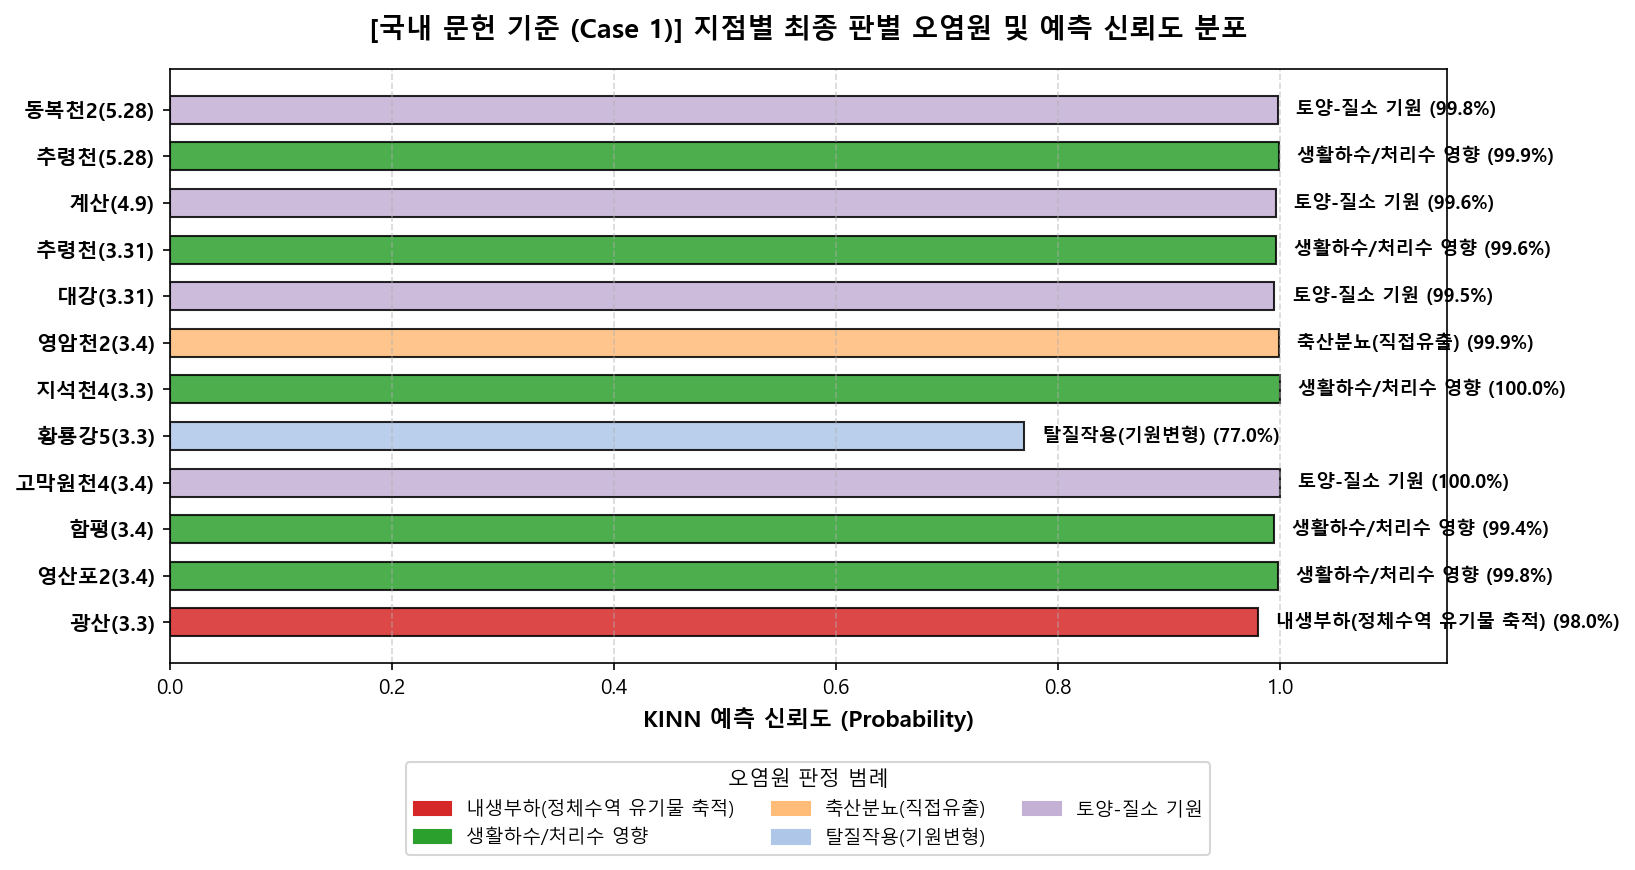

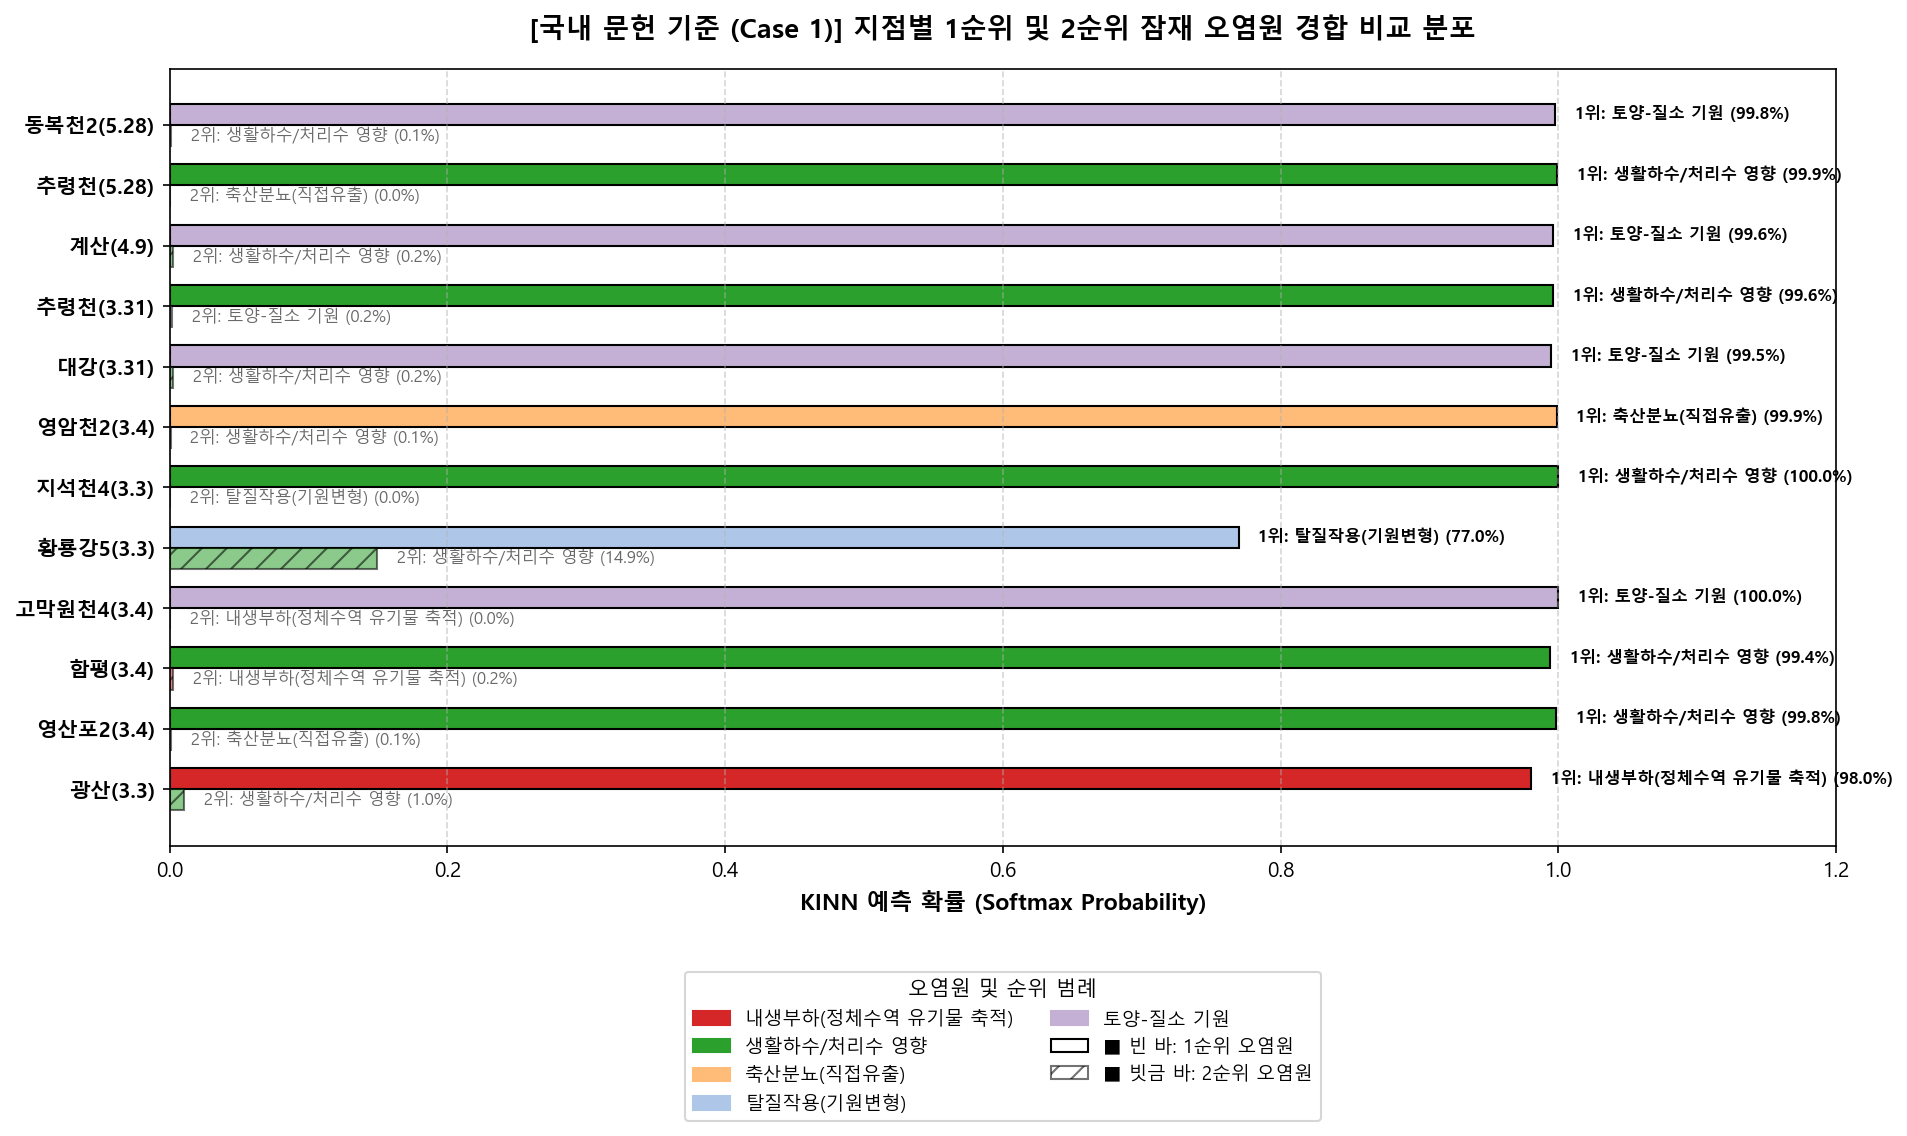

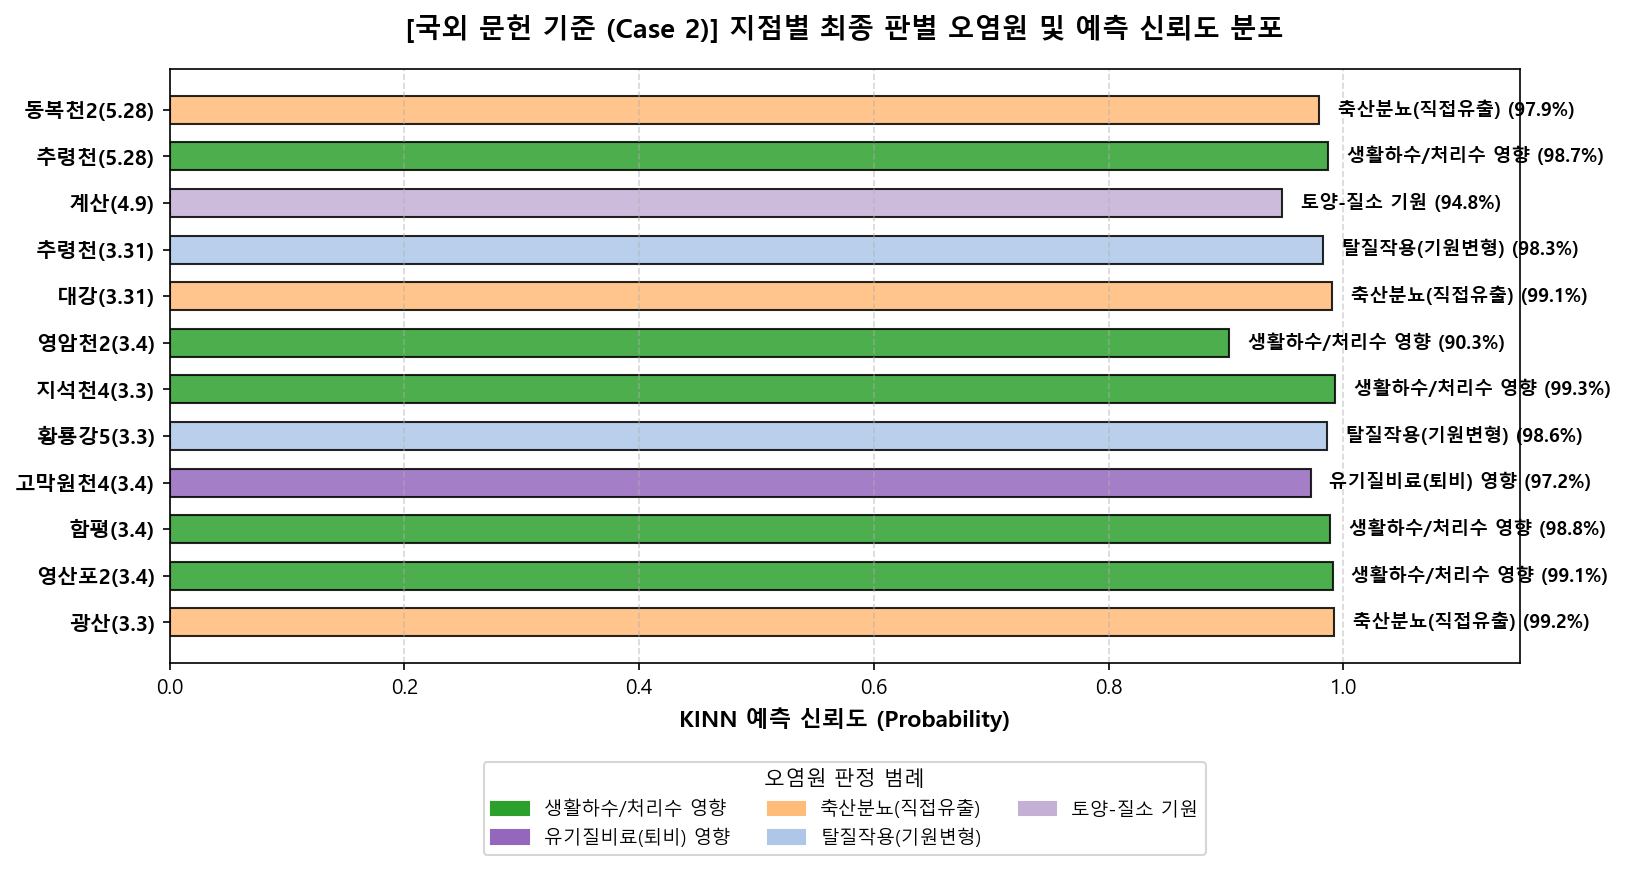

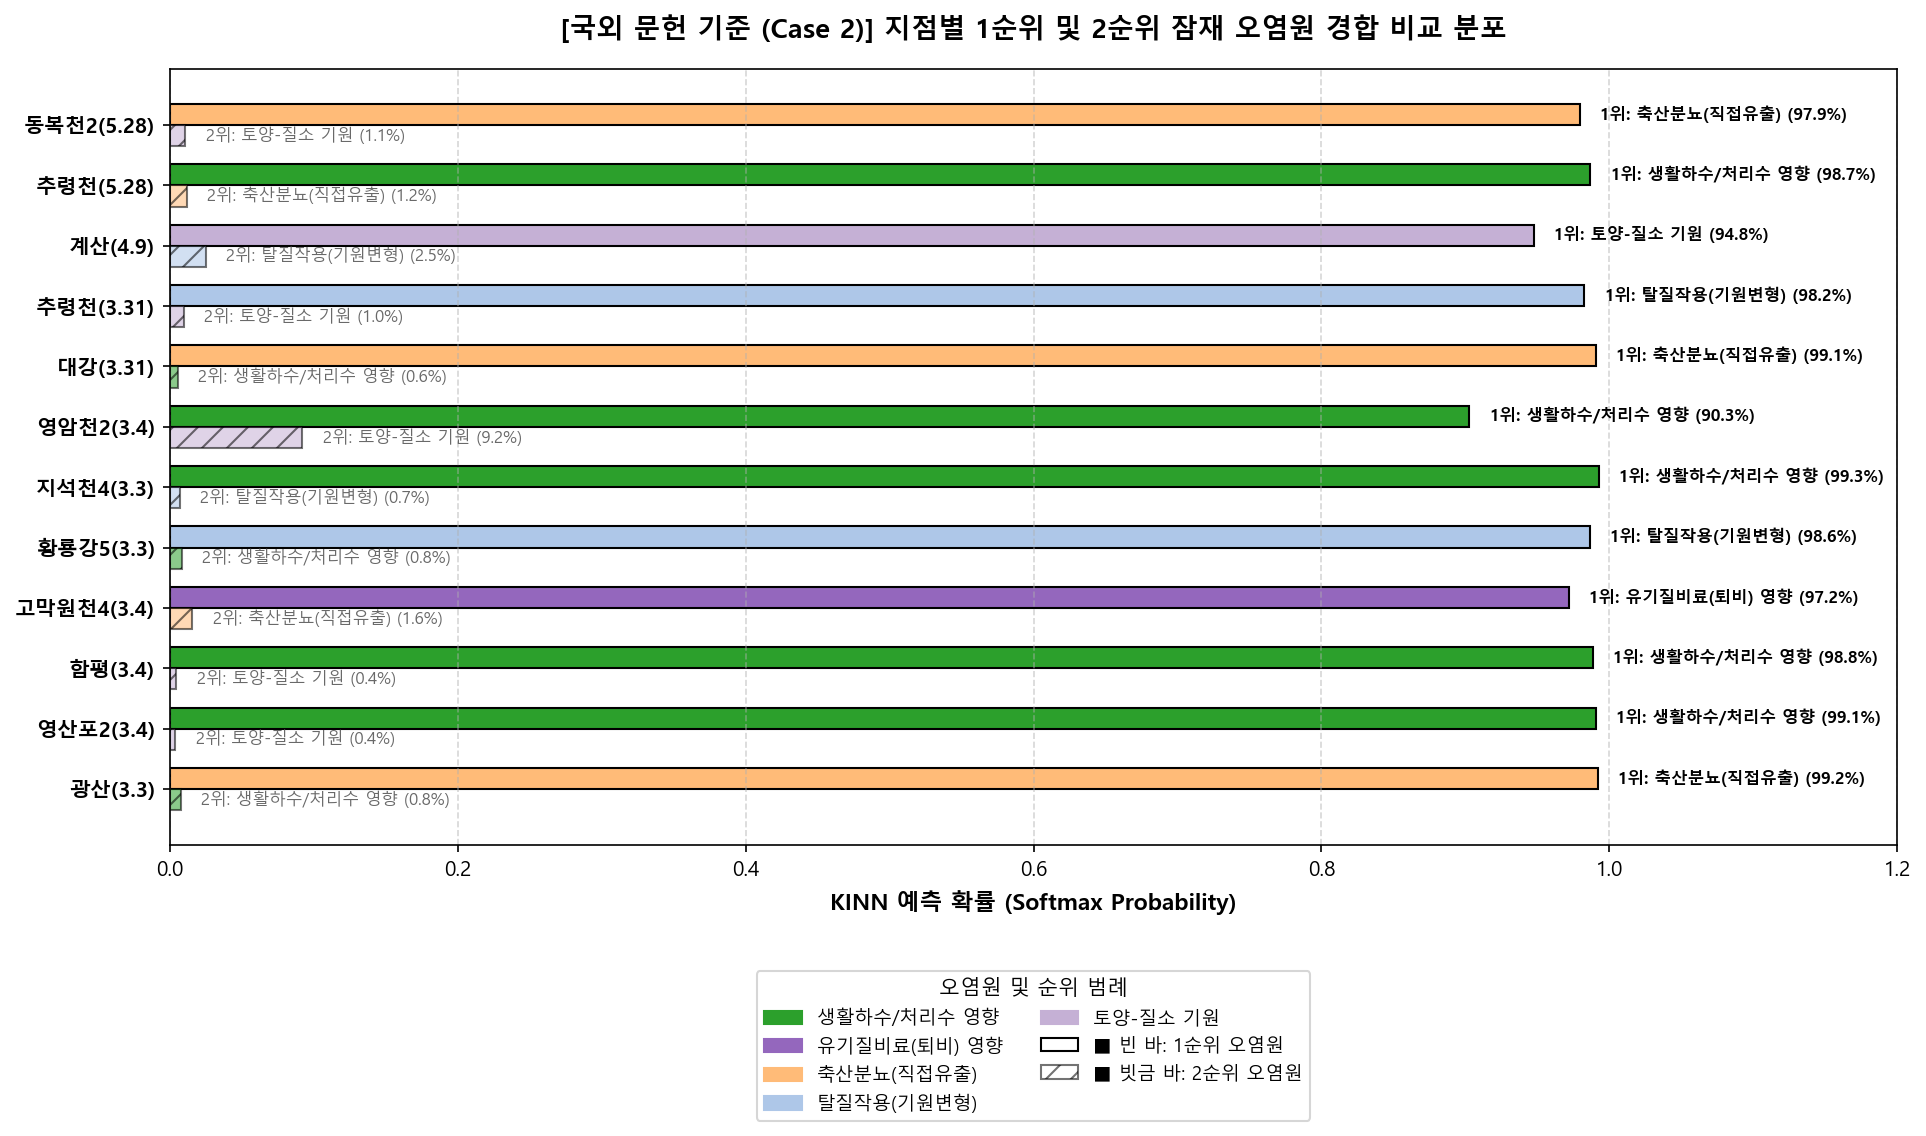

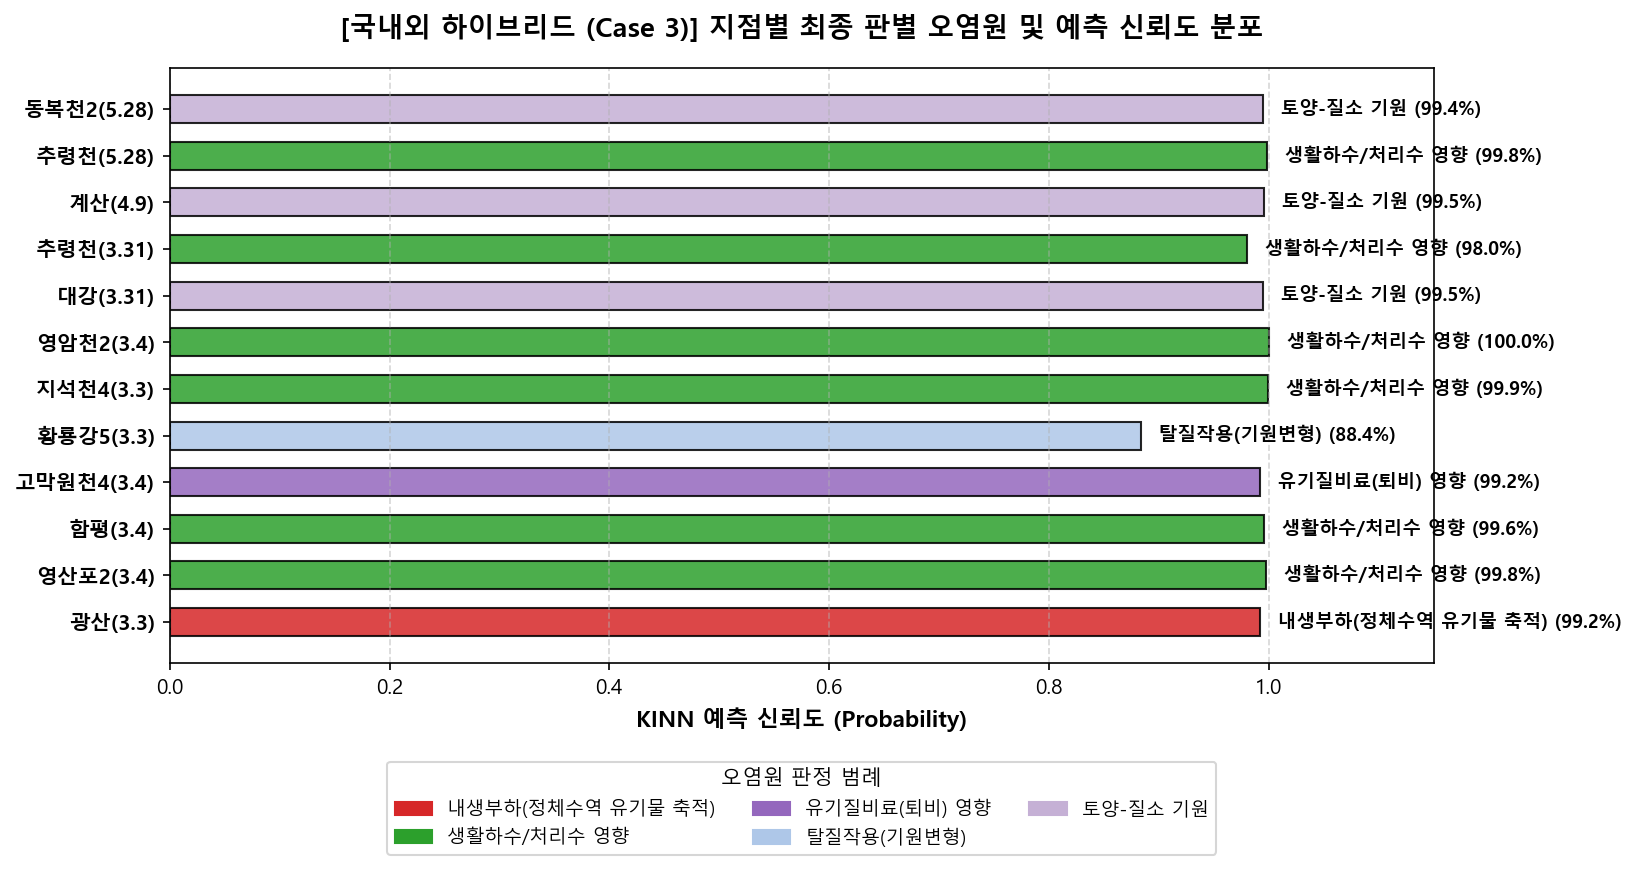

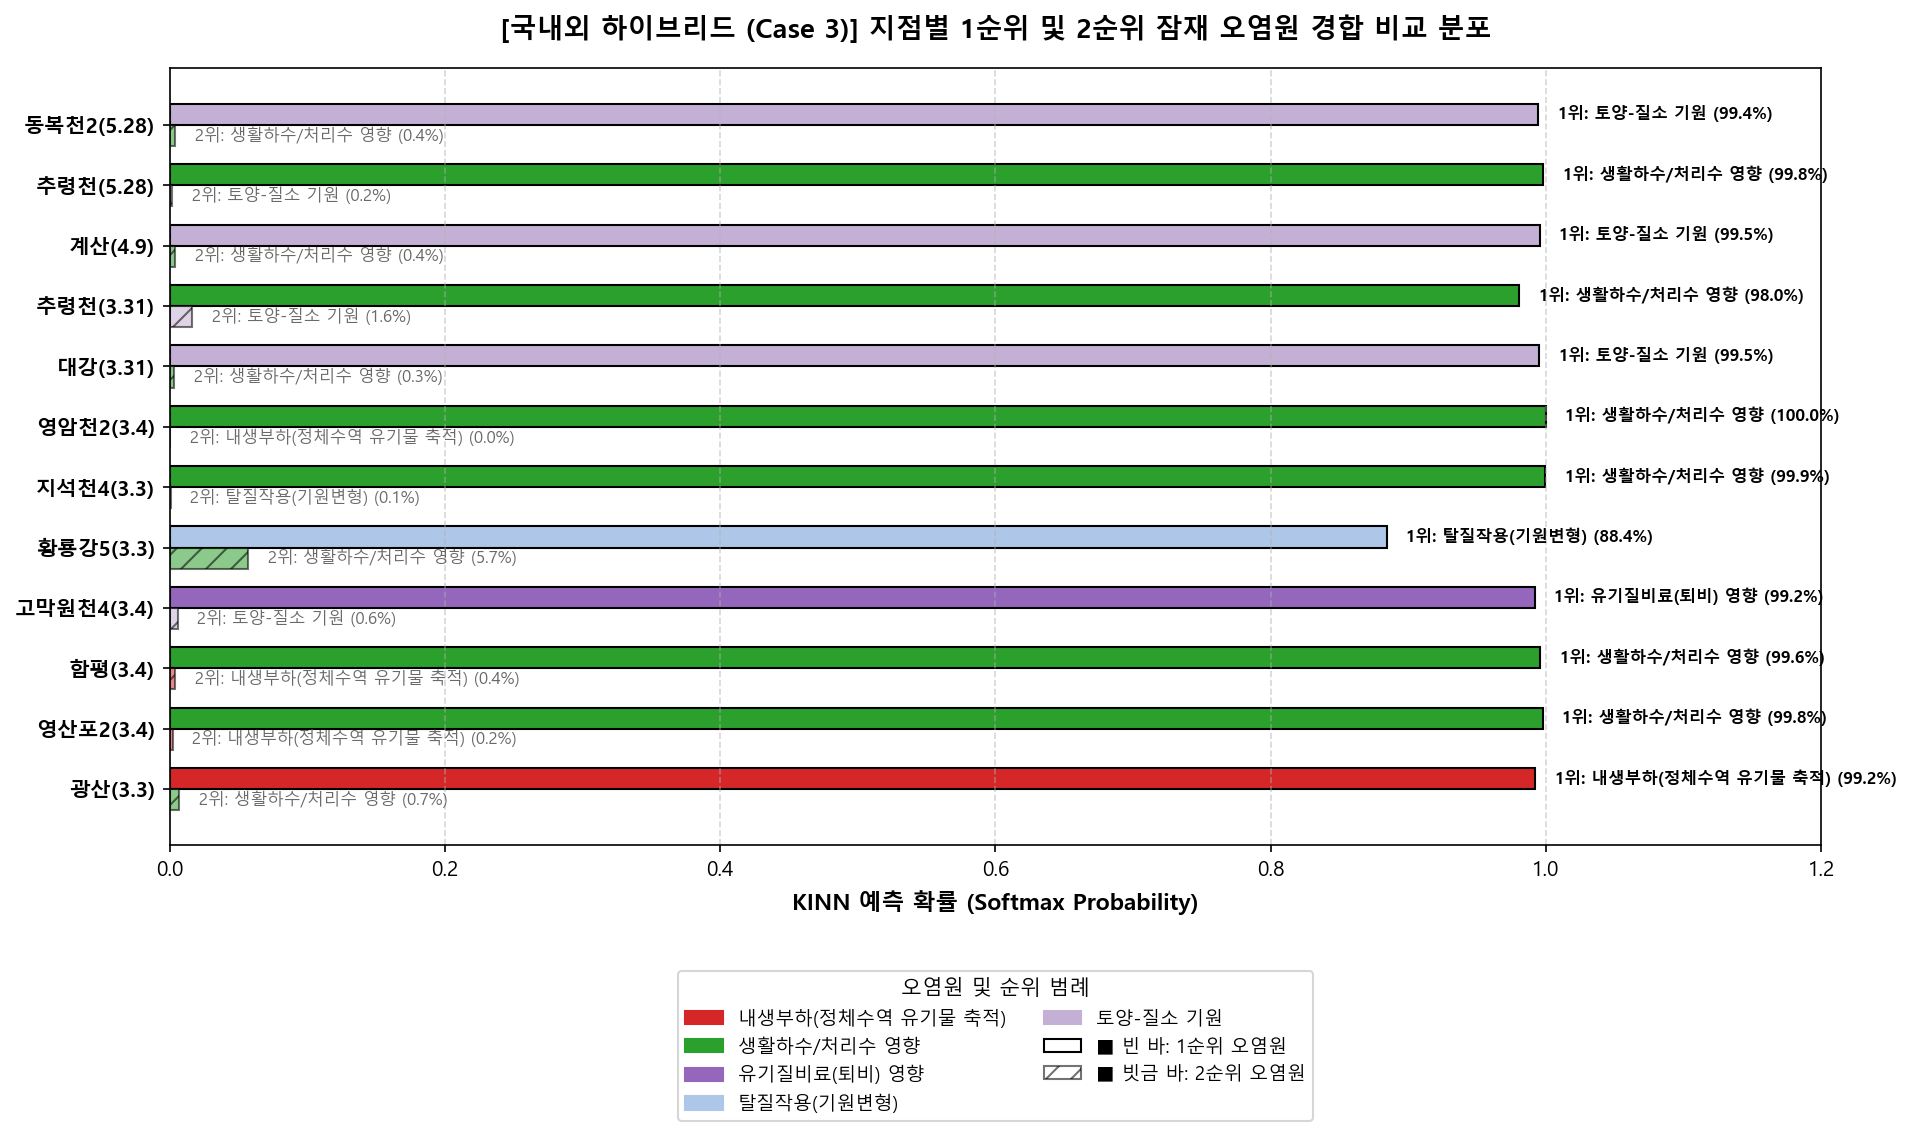

[*] 각 Case별 보고서용 그래픽 시각화 도면(총 6개 도면) 저장 완료 -> 경로: Screening_Results/
[*] [CSV 데이터 저장 성공] 오염원 추적 최종 원천 보고서 파일 저장 완료 -> Screening_Results\final_report.csv
[*] [Excel 데이터 저장 성공] 엑셀 보고서 파일 생성 완료 -> Screening_Results\final_report.xlsx

[=] 전 프로세스가 성공적으로 종료되었습니다.


In [13]:
# ------------------------------------------------------------------------------
# 4. 범용적 오염원 정밀 판별 엔진 (Rule-based Expert System)
# 설명: 제공된 21편의 문헌을 기반으로 주요 점오염원을 스크리닝하되,
#       XAI(SHAP)를 통한 임계치 자가 최적화 루프와 규칙 임베딩 손실 함수가 적용된
#       지식 주입형 신경망(KINN)을 결합하여 '자연배경/특이징후 없음'을 최소화합니다.
# * References

# 국내 문헌 (case1)
# D-1. Koh, D., & Mayer, B. (2009, December). Source identification of nitrate in groundwater using stable isotopes and Cl/Br ratios in an agricultural area. In AGU Fall Meeting Abstracts (Vol. 2009, pp. H53D-0965).
# D-2. Lee, K. S., Bong, Y. S., Lee, D., Kim, Y., & Kim, K. (2008). Tracing the sources of nitrate in the Han River watershed in Korea, using δ15N-NO3 and δ18O-NO3 values. Science of the Total Environment, 395(2-3), 117-124.  
# D-3. Ryu, H. S., Kang, T. W., Kim, K., Nam, T. H., Han, Y. U., Kim, J., ... & Lee, J. H. (2021). Tracking nitrate sources in agricultural-urban watershed using dual stable isotope and Bayesian mixing model approach: Considering N transformation by Lagrangian sampling. Journal of environmental management, 300, 113693.  
# D-4. 2024년 환경기초조사사업 최종보고서(동위원소 1차년도), 국립환경과학원 영산강물환경연구소  
# D-5. 2025년 환경기초조사사업 최종보고서(동위원소 2차년도), 국립환경과학원 영산강물환경센터  
# D-6. Hong, S., Han, Y., Kim, J., Lim, B. R., Park, S. Y., Choi, H., ... & Kim, M. S. (2023). A quantitative approach for identifying nitrogen sources in complex yeongsan river watershed, Republic of Korea, based on dual nitrogen isotope ratios and hydrological model. Water, 15(24), 4275.  
# D-7. Shin, W. J., Kim, I., Ryu, J. S., & Lee, K. S. (2019). Dual isotopes of nitrate in Korean fertilizers and their application for identifying nitrate sources. Episodes Journal of International Geoscience, 42(4), 313-319.  
# D-8. Kaown, D., Koh, D. C., Mayer, B., & Lee, K. K. (2009). Identification of nitrate and sulfate sources in groundwater using dual stable isotope approaches for an agricultural area with different land use (Chuncheon, mid-eastern Korea). Agriculture, Ecosystems & Environment, 132(3-4), 223-231.  
# D-9. Jung, H., Kim, Y. S., Yoo, J., Han, S. J., & Lee, J. (2023). Identification of nitrate sources in tap water sources across South Korea using multiple stable isotopes: Implications for land use and water management. Science of the Total Environment, 864, 161026.  
# D-10. Kim, H., Kaown, D., Mayer, B., Lee, J. Y., Hyun, Y., & Lee, K. K. (2015). Identifying the sources of nitrate contamination of groundwater in an agricultural area (Haean basin, Korea) using isotope and microbial community analyses. Science of the Total environment, 533, 566-575.  
# D-11. Shin, W. J., Jung, Y. Y., Choi, M., Choi, S. H., Choi, H. B., Lee, K. S., ... & Koh, D. C. (2023). National-scale investigation of dual nitrate isotopes and chloride ion in South Korea: Nitrate source apportionment for stream water. Environmental Research, 228, 115873.  
# D-12. Song, H., Lee, K. S., Jeong, N., Cho, S., Lee, D., Yun, C., & Shin, W. J. (2026). Nitrate source apportionments in the South Han River basin and its main tributaries using multi-isotopes and Bayesian approaches. Journal of Contaminant Hydrology, 104856.  
# D-13. Choi, W. J., Han, G. H., Ro, H. M., Yoo, S. H., & Lee, S. M. (2002). Evaluation of nitrate contamination sources of unconfined groundwater in the North Han River basin of Korea using nitrogen isotope ratios. Geosciences Journal, 6(1), 47-55.  
# D-14. Jung, H., Lee, J., Yoo, J., Kim, M., & Kim, Y. S. (2024). Improving the accuracy of nitrogen estimates from nonpoint source in a river catchment with multi-isotope tracers. Science of The Total Environment, 921, 171016.  
# D-15. Kim, S. H., Lee, D. H., Kim, M. S., Rhee, H. P., Hur, J., & Shin, K. H. (2023). Systematic tracing of nitrate sources in a complex river catchment: an integrated approach using stable isotopes and hydrological models. Water Research, 235, 119755.
# D-16. Kang, H. J., Kim, K. H., Park, K., Oh, J., Arrey, F. E., Kim, J. W., & Yun, S. T. (2026). Dual-phase nitrogen transport from swine farms in a volcanic watershed of Jeju Island, South Korea: Insights from hydrochemical, isotopic and microbial analyses. Water Research X, 100500.

# 국외 문헌 (case2)  
# O-1. Kendall, C. (1998). Tracing nitrogen sources and cycling in catchments. In Isotope tracers in catchment hydrology (pp. 519-576). Elsevier.  
# O-2. Xue, D., Botte, J., De Baets, B., Accoe, F., Nestler, A., Taylor, P., ... & Boeckx, P. (2009). Present limitations and future prospects of stable isotope methods for nitrate source identification in surface-and groundwater. Water research, 43(5), 1159-1170.  
# O-3. Böttcher, J., Strebel, O., Voerkelius, S., & Schmidt, H. L. (1990). Using isotope fractionation of nitrate-nitrogen and nitrate-oxygen for evaluation of microbial denitrification in a sandy aquifer. Journal of hydrology, 114(3-4), 413-424.  
# O-4. Aravena, R., Evans, M. L., & Cherry, J. A. (1993). Stable isotopes of oxygen and nitrogen in source identification of nitrate from septic systems. Groundwater, 31(2), 180-186.  
# O-5. Mayer, B., Boyer, E. W., Goodale, C., Jaworski, N. A., Van Breemen, N., Howarth, R. W., ... & Paustian, K. (2002). Sources of nitrate in rivers draining sixteen watersheds in the northeastern US: Isotopic constraints. Biogeochemistry, 57(1), 171-197.  
# O-6. Widory, D., Petelet-Giraud, E., Négrel, P., & Ladouche, B. (2005). Tracking the sources of nitrate in groundwater using coupled nitrogen and boron isotopes: a synthesis. Environmental Science & Technology, 39(2), 539-548.  
# O-7. Xue, Y., Song, J., Zhang, Y., Kong, F., Wen, M., & Zhang, G. (2016). Nitrate pollution and preliminary source identification of surface water in a Semi-Arid River Basin, using isotopic and hydrochemical approaches. Water, 8(8), 328.  
# O-8. Minet, E., Coxon, C. E., Goodhue, R., Richards, K. G., Kalin, R. M., & Meier-Augenstein, W. (2012). Evaluating the utility of 15N and 18O isotope abundance analyses to identify nitrate sources: A soil zone study. Water research, 46(12), 3723-3736.  
# O-9. Spalding, R. F., Hirsh, A. J., Exner, M. E., Little, N. A., & Kloppenborg, K. L. (2019). Applicability of the dual isotopes δ15N and δ18O to identify nitrate in groundwater beneath irrigated cropland. Journal of contaminant hydrology, 220, 128-135.  
# O-10. Ogrinc, N., Tamše, S., Zavadlav, S., Vrzel, J., & Jin, L. (2019). Evaluation of geochemical processes and nitrate pollution sources at the Ljubljansko polje aquifer (Slovenia): A stable isotope perspective. Science of the total environment, 646, 1588-1600.  
# O-11. Li, S. L., Liu, C. Q., Li, J., Xue, Z., Guan, J., Lang, Y., ... & Li, L. (2013). Evaluation of nitrate source in surface water of southwestern China based on stable isotopes. Environmental earth sciences, 68(1), 219-228.  
# O-12. Wassenaar, L. I. (1995). Evaluation of the origin and fate of nitrate in the Abbotsford Aquifer using the isotopes of 15N and 18O in NO3-. Applied geochemistry, 10(4), 391-405.  
# O-13. Chen, R., Hu, Q., Shen, W., Guo, J., Yang, L., Yuan, Q., ... & Wang, L. (2023). Identification of nitrate sources of groundwater and rivers in complex urban environments based on isotopic and hydro-chemical evidence. Science of the Total Environment, 871, 162026.  
# O-14. Ren, C., Zhang, Q., Wang, H., & Wang, Y. (2021). Identification of sources and transformations of nitrate in the intense human activity region of North China using a multi-isotope and Bayesian model. International Journal of Environmental Research and Public Health, 18(16), 8642.  
# O-15. Divers, M. T., Elliott, E. M., & Bain, D. J. (2014). Quantification of nitrate sources to an urban stream using dual nitrate isotopes. Environmental science & technology, 48(18), 10580-10587.  
# O-16. Wang, S., Li, H., Kang, T., Li, R., & Zhang, C. (2025). Resolving Nitrate Sources in Rivers Through Dual Isotope Analysis of δ15N and δ18O. Water, 17(23), 3370.  
# O-17. Mayer, B., Boyer, E. W., Goodale, C., Jaworski, N. A., Van Breemen, N., Howarth, R. W., ... & Paustian, K. (2002). Sources of nitrate in rivers draining sixteen watersheds in the northeastern US: Isotopic constraints. Biogeochemistry, 57(1), 171-197.  
# O-18. Wang, M., Lu, B., Wang, J., Zhang, H., Guo, L., & Lin, H. (2016). Using dual isotopes and a bayesian isotope mixing model to evaluate nitrate sources of surface water in a drinking water source watershed, East China. Water, 8(8), 355.  
# O-19. Ren, J., Han, G., Liu, X., Gao, X., & Zhang, S. (2026). Unraveling Nitrate Source Dynamics in Megacity Rivers Using an Integrated Machine Learning–Bayesian Isotope Framework. Water, 18(1), 106.  
# O-20. Widory, D., Kloppmann, W., Chery, L., Bonnin, J., Rochdi, H., & Guinamant, J. L. (2004). Nitrate in groundwater: an isotopic multi-tracer approach. Journal of contaminant hydrology, 72(1-4), 165-188.

# 국내 문헌 + 국외 문헌 (case3) : 위의 문헌 모두 반영
# ------------------------------------------------------------------------------

# ==============================================================================
# [1] 국내·외 문헌(D-1~D-16, O-1~O-20) 통합 임계치 사전(Dictionary) 정의
# ==============================================================================
# 영산강·섬진강 수계 현장 조사 보고서(D-4, D-5) 및 다중 동위원소/수화학 문헌의 
# 고유 End-member(단단) 범위와 수질 연계 지표를 체계적으로 가변 관리합니다.
# ------------------------------------------------------------------------------

cfg_thresholds = {
    # --------------------------------------------------------------------------
    # 1. 대기유입 및 초기강우 (Ref: D-4, D-5, O-1, O-5, O-15, O-18)
    # --------------------------------------------------------------------------
    'o18_air': 15.0,                  # 대기 유입 및 직사 강우 d18O 하한 경계값 (‰) [O-1, O-5]
    'lit22_atm_n15_min': -10.0,       # 강우 유래 질소 d15N 최소값 [D-4]
    'lit22_atm_n15_max': 5.0,         # 강우 유래 질소 d15N 최대값 [D-4]
    'lit22_atm_o18_min': 50.0,        # 강우/대기유입 고유 d18O 최소 경계치 (50~80‰) [D-4, O-1]

    # --------------------------------------------------------------------------
    # 2. 탈질작용 기원변형 (Ref: D-2, D-3, D-10, O-2, O-3, O-8)
    # --------------------------------------------------------------------------
    'n15_denit_min': 6.0,             # 탈질 진단 d15N 최소 기점 [D-2, O-3]
    'o18_denit_min': 3.0,             # 탈질 진단 d18O 최소 기점 [D-3, O-2]
    'denit_ratio_min': 1.0,           # 탈질 농축 기울기 (Δd15N/Δd18O) 하한 (1:1 근사) [O-3]
    'denit_ratio_max': 2.5,           # 탈질 농축 기울기 (Δd15N/Δd18O) 상한 (1:2.1~2.5) [D-3, O-8]

    # --------------------------------------------------------------------------
    # 3. 산업/인위적 점오염 (Ref: D-8, D-9, O-6, O-11, O-13, O-20)
    # --------------------------------------------------------------------------
    'n15_ind': 7.0,                   # 산업 및 도심 폐수 d15N 하한선 [D-8, O-13]
    'ec_ind': 500.0,                  # 산업유입 지표 전기전도도(EC, µS/cm) 기준 [D-9, O-11]
    'cl_ind': 100.0,                  # 산업/인위적 점오염 염소이온(Cl-, mg/L) 기준 [O-6, O-20]
    'toc_ind': 3.0,                   # 점오염 유기물 배출 지표 TOC(mg/L) 기준 [D-4]
    'tn_ind': 3.0,                    # 산업/도심 폐수 기원 총질소(TN, mg/L) 기준 [D-5]

    # --------------------------------------------------------------------------
    # 4. 축산분뇨 직접유출 (Ref: D-2, D-4, D-5, D-6, D-7, D-16, O-1, O-4, O-5, O-6, O-14, O-16)
    # --------------------------------------------------------------------------
    'n15_manure': 12.0,               # 전형적 축산분뇨 고유 d15N 단단 하한선 (12~20‰+) [D-2, O-1]
    'cl_manure': 60.0,                # 축산계 고농도 Cl- 경계치 (mg/L) [D-6, O-6]
    'nh3_manure': 0.3,                # 축산분뇨 직접유출 암모니아성 질소(NH3-N, mg/L) 기점 [D-16]
    'tn_manure': 5.0,                 # 축산분뇨 고농도 총질소(TN, mg/L) 하한선 [D-5, D-16]
    'lit23_livestock_n15_min': 11.0,  # [D-5 영산강센터 2차년도] 현장 최적화 축산 d15N 하한 (11.0‰)
    'lit23_livestock_cl_min': 30.0,   # [D-5 영산강센터 2차년도] 현장 최적화 축산 Cl- 하한 (30.0 mg/L)
    'lit23_livestock_tp_min': 0.1,    # [D-5 영산강센터 2차년도] 현장 최적화 축산 TP 하한 (0.1 mg/L)
    'lit22_mix_n15_min': 8.0,         # [D-4 영산강연구소 1차년도] 분뇨/하수 복합구역 d15N 하한
    'lit22_mix_n15_max': 22.0,        # [D-4 영산강연구소 1차년도] 분뇨/하수 복합구역 d15N 상한
    'lit22_mix_o18_min': 0.0,         # [D-4 영산강연구소 1차년도] 분뇨/하수 복합구역 d18O 하한
    'lit22_mix_o18_max': 15.0,        # [D-4 영산강연구소 1차년도] 분뇨/하수 복합구역 d18O 상한

    # --------------------------------------------------------------------------
    # 5. 생활하수/처리수 영향 (Ref: D-3, D-4, D-5, D-9, O-4, O-6, O-13, O-19)
    # --------------------------------------------------------------------------
    'n15_sewage_min': 7.0,            # 생활하수 및 WWTP 방류수 d15N 단단 하한 [D-3, O-4]
    'n15_sewage_max': 12.0,           # 생활하수 및 WWTP 방류수 d15N 단단 상한 [D-9, O-6]
    'cl_sewage': 40.0,                # 생활하수 유입 지표 Cl- 경계치 (mg/L) [D-5, O-13]
    'tp_sewage': 0.3,                 # 하수 영향권 통제 총인(TP, mg/L) 상한선 [D-4]
    'tn_sewage': 2.0,                 # 생활하수 유입 지표 총질소(TN, mg/L) 하한선 [D-5]
    'n15_urban_mixed': 8.0,           # 메가시티 복합 하수/도심배수 d15N 하한선 [O-19]
    'lit23_domestic_n15_min': 7.0,    # [D-5 영산강센터 2차년도] 생활하수 d15N 하한
    'lit23_domestic_n15_max': 11.0,   # [D-5 영산강센터 2차년도] 생활하수 d15N 상한
    'lit23_domestic_cl_min': 40.0,    # [D-5 영산강센터 2차년도] 생활하수 Cl- 하한
    'lit23_domestic_toc_min': 4.0,    # [D-5 영산강센터 2차년도] 생활하수 TOC 하한

    # --------------------------------------------------------------------------
    # 6. 조류증식 현장발생 (Ref: D-4, D-6, O-15)
    # --------------------------------------------------------------------------
    'chl_algae': 40.0,                # 조류 증식(현장 우세) 판단 클로로필-a 기준 (µg/L) [D-4]
    'toc_algae': 4.5,                 # 조류 대사물질 유래 TOC 기준 (mg/L) [D-6]

    # --------------------------------------------------------------------------
    # 7. 내생부하 정체수역 유기물 축적 (Ref: D-4, D-6)
    # --------------------------------------------------------------------------
    'toc_internal': 6.5,              # 정체수역 저질 퇴적물 용출 TOC 기준 (mg/L) [D-4]
    'tp_internal': 0.1,               # 저질 퇴적물 용출 총인(TP, mg/L) 기준 [D-6]

    # --------------------------------------------------------------------------
    # 8. 화학비료(농경지) (Ref: D-1, D-2, D-4, D-5, D-7, D-11, D-12, D-13, D-14, D-15, O-1, O-9, O-12)
    # --------------------------------------------------------------------------
    'n15_fertilizer_max': 4.0,        # 화학비료(무기질비료) d15N 단단 상한선 (-4~+4‰) [D-7, O-1]
    'no3_fertilizer': 2.0,            # 화학비료 다량 시비 구역 NO3-N 기준 (mg/L) [D-1, D-13]
    'cl_fertilizer': 30.0,            # 화학비료 우세 구역 Cl- 통제 상한선 (mg/L) [D-11]
    'tn_fertilizer': 2.5,             # 화학비료 및 농경지 비점유출 총질소(TN, mg/L) 기준 [D-14, D-15]
    'n15_nonpoint_adv': 5.0,          # 다중 동위원소 연계 비점오염(농경지) d15N 상한선 [D-15]
    'lit22_fer_n15_min': -4.0,        # [D-4 영산강연구소 1차년도] 화학비료 d15N 하한
    'lit22_fer_n15_max': 5.0,         # [D-4 영산강연구소 1차년도] 화학비료 d15N 상한
    'lit22_fer_o18_min': 15.0,        # [D-4 영산강연구소 1차년도] 화학비료 d18O 하한
    'lit22_fer_o18_max': 25.0,        # [D-4 영산강연구소 1차년도] 화학비료 d18O 상한

    # --------------------------------------------------------------------------
    # 9. 유기질비료(퇴비) 영향 (Ref: D-5, D-7, D-11, D-12, O-1)
    # --------------------------------------------------------------------------
    'n15_soil_min': 4.0,              # 토양/퇴비 유기물 미네랄화 d15N 하한선 [D-12, O-1]
    'n15_soil_max': 9.0,              # 토양/퇴비 유기물 미네랄화 d15N 상한선 [D-11, O-1]
    'cl_soil_high': 35.0,             # 퇴비(유기질비료) 유출 지표 Cl- 하한선 (mg/L) [D-5]
    'toc_soil_high': 4.0,             # 퇴비 유출 유기물 TOC 하한선 (mg/L) [D-5]

    # --------------------------------------------------------------------------
    # 10. 토양-질소 기원 (Ref: D-4, D-5, D-11, D-12, O-1, O-7, O-10, O-11)
    # --------------------------------------------------------------------------
    'cl_soil_low': 20.0,              # 자연림 및 순수 토양계 Cl- 통제 상한선 (mg/L) [D-11, O-10]
    'toc_soil_low': 4.0,              # 자연 토양 유기물 배경 TOC 통제 상한선 (mg/L) [D-4]
    'lit22_soil_n15_min': 1.0,        # [D-4 영산강연구소 1차년도] 토양-질소 d15N 하한
    'lit22_soil_n15_max': 8.0,        # [D-4 영산강연구소 1차년도] 토양-질소 d15N 상한
    'lit22_soil_o18_min': 0.0,        # [D-4 영산강연구소 1차년도] 토양-질소 d18O 하한
    'lit22_soil_o18_max': 12.0,       # [D-4 영산강연구소 1차년도] 토양-질소 d18O 상한
    'lit23_land_n15_min': 2.0,        # [D-5 영산강센터 2차년도] 토지계 비점 d15N 하한
    'lit23_land_n15_max': 7.0,        # [D-5 영산강센터 2차년도] 토지계 비점 d15N 상한
    'lit23_land_tp_max': 0.05,        # [D-5 영산강센터 2차년도] 토지계 비점 TP 상한
    'lit23_land_toc_min': 3.0,        # [D-5 영산강센터 2차년도] 토지계 비점 TOC 하한

    # --------------------------------------------------------------------------
    # 11. 미약 징후 포착용 초민감도 Fallback 임계치 (자연배경 판정 최소화 보장)
    # --------------------------------------------------------------------------
    'fallback_n15_high': 6.0,         # 분뇨/하수 복합오염 분기 d15N 경계치 (하향)
    'fallback_cl': 15.0,              # 인위적 오염 구제용 Cl- 경계치 (mg/L)
    'fallback_tp': 0.03,              # 유기물/인 오염 구제용 TP 경계치 (mg/L)
    'fallback_no3': 1.0,              # 비점/비료 구제용 NO3-N 경계치 (mg/L)
    'fallback_tn': 1.0,               # 미약 오염 구제용 TN 초민감도 경계치 (mg/L)
    'fallback_toc': 2.0,              # 미약 유기물 구제용 TOC 경계치 (mg/L)
}

# ==============================================================================
# [2] 가중치 매트릭스 기반 범용 오염원 정밀 판별 엔진
# ==============================================================================

def assign_source_weighted(row, th, lit_case=3):
    """
    관측 지점의 동위원소(d15N, d18O) 및 수화학 데이터(Cl, TP, TN, NH3N, NO3N, TOC, EC, Chla)를 입력받아
    문헌 기반가중치 알고리즘을 통해 11단계 정형 범주 오염원을 판별합니다.

    Parameters:
        row (dict or pd.Series): 관측 데이터 행
        th (dict): 임계치 사전 (cfg_thresholds)
        lit_case (int): 1(국내문헌 중심), 2(국외문헌 중심), 3(국내외 통합 하이브리드)

    Returns:
        best_source (str): 판별된 최우선 오염원
        reliability (float): 판별 신뢰도 (0.0 ~ 1.0)
    """

    # 안전한 형변환 및 결측치(-999.0) 처리 내부 함수
    def safe_val(val, default=-999.0):
        if pd.isna(val) or val is None:
            return default
        try:
            return float(val)
        except (ValueError, TypeError):
            return default

    # 데이터 프레임 행에서 수질 및 동위원소 데이터 안전 바인딩
    n15, o18, cl = safe_val(row.get('d15N')), safe_val(row.get('d18O')), safe_val(row.get('Cl'))
    tp, tn, nh3, no3 = safe_val(row.get('TP')), safe_val(row.get('TN')), safe_val(row.get('NH3N')), safe_val(row.get('NO3N'))
    toc, ec, chl = safe_val(row.get('TOC')), safe_val(row.get('EC')), safe_val(row.get('Chla')) 

    # [Priority 0] 모든 필수 데이터가 전면 결측인 경우 가동 중단 후 판정 보류
    if (n15 == -999.0 and cl == -999.0 and no3 == -999.0 and toc == -999.0 and 
        o18 == -999.0 and tp == -999.0 and nh3 == -999.0 and ec == -999.0 and chl == -999.0 and tn == -999.0):
        return "결측-판정보류", 0.0

    # 국내외 문헌 가중치 스위치 셋업
    if lit_case == 1:
        w_dom, w_int = 1.0, 0.0   # 국내 문헌 전용
    elif lit_case == 2:
        w_dom, w_int = 0.0, 1.0   # 국외 문헌 전용
    else:
        w_dom, w_int = 1.0, 1.0   # 국내외 통합 하이브리드 모드 

    # 오염원 계층 점수 체계 (Priority Score Matrix)
    P_SCORE = {
        'P1_HighRisk': 1500,     # 최우선 추적 기작: 대기유입 및 탈질작용
        'P2_MajorPoll': 1400,    # 핵심 인위적 오염원: 분뇨, 하수, 화학비료
        'P3_PointPoll': 1100,    # 산업/인위적 점오염원
        'P4_EcoLoad': 800,       # 수계 내부 생성 생태 부하 (조류, 내생부하)
        'P5_NonPoint': 600,      # 기타 토지계/비점오염 기원 (퇴비, 토양유기물)
        'P6_Fallback': 500       # 미약 징후 포착용 초민감도 구제 스코어
    }

    scores = {}

    def add_score(name, val):
        if val > 0:
            scores[name] = scores.get(name, 0.0) + val

    # ==========================================================================
    # [지정된 11단계 순서에 따른 오염원 판별 및 문헌 매핑 엔진]
    # ==========================================================================

    # --------------------------------------------------------------------------
    # 1. 대기유입/초기강우
    # --------------------------------------------------------------------------
    # [문헌 근거] D-4(NIER 2024), D-5(NIER 2025), O-1(Kendall 1998), O-5(Mayer 2002), O-15(Divers 2014), O-18(Wang 2016)
    if o18 > th['o18_air']: 
        add_score("대기유입/초기강우", P_SCORE['P1_HighRisk'] * (w_int + w_dom))
    if th['lit22_atm_n15_min'] <= n15 <= th['lit22_atm_n15_max'] and o18 >= th['lit22_atm_o18_min']:
        add_score("대기유입/초기강우", P_SCORE['P1_HighRisk'] * w_dom)

    # --------------------------------------------------------------------------
    # 2. 탈질작용(기원변형)
    # --------------------------------------------------------------------------
    # [문헌 근거] D-2(Lee 2008), D-3(Ryu 2021), D-10(Kim 2015), O-2(Xue 2009), O-3(Böttcher 1990), O-8(Minet 2012)
    if n15 > th['n15_denit_min'] and o18 > th['o18_denit_min']:
        denom = o18 + 1e-5
        ratio = n15 / denom
        if th['denit_ratio_min'] <= ratio <= th['denit_ratio_max']:
            add_score("탈질작용(기원변형)", P_SCORE['P1_HighRisk'] * (w_int + w_dom))

    # --------------------------------------------------------------------------
    # 3. 산업/인위적 점오염
    # --------------------------------------------------------------------------
    # [문헌 근거] D-8(Kaown 2009), D-9(Jung 2023), O-6(Widory 2005), O-11(Li 2013), O-13(Chen 2023), O-20(Widory 2004)
    # [TN 반영] 고농도 산업폐수 배출 지표로 TN 추가 검증
    if n15 > th['n15_ind'] and (ec > th['ec_ind'] or cl > th['cl_ind'] or tn > th['tn_ind']) and toc > th['toc_ind']:
        add_score("산업/인위적 점오염", P_SCORE['P3_PointPoll'] * (w_int + w_dom))

    # --------------------------------------------------------------------------
    # 4. 축산분뇨(직접유출)
    # --------------------------------------------------------------------------
    # [문헌 근거] D-2(Lee 2008), D-4(NIER 2024), D-5(NIER 2025), D-6(Hong 2023), D-7(Shin 2019), D-16(Kang 2026),
    #            O-1(Kendall 1998), O-4(Aravena 1993), O-5(Mayer 2002), O-6(Widory 2005), O-14(Ren 2021), O-16(Wang 2025)
    # [TN 반영] 축산분뇨의 고농도 질소 유출 특성을 고려하여 TN 임계치(tn_manure) 반영
    if n15 > th['n15_manure'] and (cl > th['cl_manure'] or nh3 > th['nh3_manure'] or tn > th['tn_manure']):
        add_score("축산분뇨(직접유출)", P_SCORE['P2_MajorPoll'] * (w_int + w_dom))
    if n15 >= th['lit23_livestock_n15_min'] and cl >= th['lit23_livestock_cl_min'] and tp >= th['lit23_livestock_tp_min']:
        add_score("축산분뇨(직접유출)", P_SCORE['P2_MajorPoll'] * w_dom) 
    if th['lit22_mix_n15_min'] <= n15 <= th['lit22_mix_n15_max'] and th['lit22_mix_o18_min'] <= o18 <= th['lit22_mix_o18_max']:
        add_score("축산분뇨(직접유출)", P_SCORE['P2_MajorPoll'] * w_dom) 

    # --------------------------------------------------------------------------
    # 5. 생활하수/처리수 영향
    # --------------------------------------------------------------------------
    # [문헌 근거] D-3(Ryu 2021), D-4(NIER 2024), D-5(NIER 2025), D-9(Jung 2023),
    #            O-4(Aravena 1993), O-6(Widory 2005), O-13(Chen 2023), O-19(Ren 2026)
    # [TN 반영] 하수처리장 방류수 및 관거 누수 지표로 TN 추가
    if th['n15_sewage_min'] < n15 <= th['n15_sewage_max'] and (cl > th['cl_sewage'] or (tp != -999.0 and tp <= th['tp_sewage']) or tn > th['tn_sewage']):
        add_score("생활하수/처리수 영향", P_SCORE['P2_MajorPoll'] * (w_int + w_dom))
    if n15 >= th['n15_urban_mixed'] and cl > th['cl_sewage'] and toc > th['toc_ind']:
        add_score("생활하수/처리수 영향", P_SCORE['P2_MajorPoll'] * w_int)
    if th['lit23_domestic_n15_min'] <= n15 < th['lit23_domestic_n15_max'] and cl >= th['lit23_domestic_cl_min'] and toc >= th['lit23_domestic_toc_min']:
        add_score("생활하수/처리수 영향", P_SCORE['P2_MajorPoll'] * w_dom)
    if th['lit22_mix_n15_min'] <= n15 <= th['lit22_mix_n15_max'] and th['lit22_mix_o18_min'] <= o18 <= th['lit22_mix_o18_max']:
        add_score("생활하수/처리수 영향", P_SCORE['P2_MajorPoll'] * w_dom)

    # --------------------------------------------------------------------------
    # 6. 조류증식(현장발생)
    # --------------------------------------------------------------------------
    # [문헌 근거] D-4(NIER 2024), D-6(Hong 2023), O-15(Divers 2014)
    if chl > th['chl_algae'] and toc > th['toc_algae']: 
        add_score("조류증식(현장발생)", P_SCORE['P4_EcoLoad'] * (w_int + w_dom))

    # --------------------------------------------------------------------------
    # 7. 내생부하(정체수역 유기물 축적)
    # --------------------------------------------------------------------------
    # [문헌 근거] D-4(NIER 2024), D-6(Hong 2023)
    if toc > th['toc_internal'] and tp > th['tp_internal']: 
        add_score("내생부하(정체수역 유기물 축적)", P_SCORE['P4_EcoLoad'] * w_dom)

    # --------------------------------------------------------------------------
    # 8. 화학비료(농경지)
    # --------------------------------------------------------------------------
    # [문헌 근거] D-1(Koh 2009), D-2(Lee 2008), D-4(NIER 2024), D-5(NIER 2025), D-7(Shin 2019),
    #            D-11(Shin 2023), D-12(Song 2026), D-13(Choi 2002), D-14(Jung 2024), D-15(Kim 2023),
    #            O-1(Kendall 1998), O-9(Spalding 2019), O-12(Wassenaar 1995)
    # [TN 반영] 농경지 비점유출 특성에 따라 NO3-N 및 TN 지표 보완
    if n15 != -999.0 and n15 < th['n15_nonpoint_adv'] and (no3 > th['no3_fertilizer'] or tn > th['tn_fertilizer']) and (cl != -999.0 and cl < th['cl_fertilizer']):
        add_score("화학비료(농경지)", P_SCORE['P2_MajorPoll'] * (w_int + w_dom))
    if th['lit22_fer_n15_min'] <= n15 <= th['lit22_fer_n15_max'] and th['lit22_fer_o18_min'] <= o18 <= th['lit22_fer_o18_max']:
        add_score("화학비료(농경지)", P_SCORE['P2_MajorPoll'] * w_dom)

    # --------------------------------------------------------------------------
    # 9. 유기질비료(퇴비) 영향
    # --------------------------------------------------------------------------
    # [문헌 근거] D-5(NIER 2025), D-7(Shin 2019), D-11(Shin 2023), D-12(Song 2026), O-1(Kendall 1998)
    if th['n15_soil_min'] <= n15 < th['n15_soil_max'] and cl > th['cl_soil_high'] and toc > th['toc_soil_high']:
        add_score("유기질비료(퇴비) 영향", P_SCORE['P5_NonPoint'] * (w_int + w_dom))

    # --------------------------------------------------------------------------
    # 10. 토양-질소 기원
    # --------------------------------------------------------------------------
    # [문헌 근거] D-4(NIER 2024), D-5(NIER 2025), D-11(Shin 2023), D-12(Song 2026),
    #            O-1(Kendall 1998), O-7(Xue 2016), O-10(Ogrinc 2019), O-11(Li 2013)
    if th['n15_soil_min'] <= n15 < th['n15_soil_max'] and (toc != -999.0 and toc < th['toc_soil_low']) and (cl != -999.0 and cl < th['cl_soil_low']): 
        add_score("토양-질소 기원", P_SCORE['P5_NonPoint'] * (w_int + w_dom))
    if th['lit22_soil_n15_min'] <= n15 <= th['lit22_soil_n15_max'] and th['lit22_soil_o18_min'] <= o18 <= th['lit22_soil_o18_max']:
        add_score("토양-질소 기원", P_SCORE['P5_NonPoint'] * w_dom)
    if th['lit23_land_n15_min'] <= n15 <= th['lit23_land_n15_max'] and ((tp != -999.0 and tp < th['lit23_land_tp_max']) or toc >= th['lit23_land_toc_min']):
        add_score("토양-질소 기원", P_SCORE['P5_NonPoint'] * w_dom)

    # ==========================================================================
    # [주의사항 3 반영: 자연배경/특이징후 없음 최소화를 위한 다중 초민감 구제 로직]
    # ==========================================================================
    # 상기 조건에서 점수를 얻지 못한 경우, 촘촘한 수질/동위원소 조건으로 구제 스코어를 부여합니다.
    if not scores:
        if n15 != -999.0:
            if n15 > th['fallback_n15_high']: 
                add_score("축산분뇨(직접유출)", P_SCORE['P6_Fallback'] * 0.5 * w_int)
                add_score("생활하수/처리수 영향", P_SCORE['P6_Fallback'] * 0.5 * w_int)
            else: 
                add_score("화학비료(농경지)", P_SCORE['P6_Fallback'] * 0.3 * w_int)
                add_score("유기질비료(퇴비) 영향", P_SCORE['P6_Fallback'] * 0.3 * w_int)
                add_score("토양-질소 기원", P_SCORE['P6_Fallback'] * 0.4 * w_int)
                
        # [TN 반영] 미세한 TN/Cl/TP/NO3 농도 상승만으로도 구제 스코어 부여
        if cl > th['fallback_cl'] or tp > th['fallback_tp'] or tn > th['fallback_tn']: 
            add_score("생활하수/처리수 영향", P_SCORE['P6_Fallback'] * 0.5 * (w_int + w_dom))
            add_score("축산분뇨(직접유출)", P_SCORE['P6_Fallback'] * 0.5 * (w_int + w_dom))
        elif no3 > th['fallback_no3']: 
            add_score("화학비료(농경지)", P_SCORE['P6_Fallback'] * 0.5 * (w_int + w_dom))
            add_score("유기질비료(퇴비) 영향", P_SCORE['P6_Fallback'] * 0.5 * (w_int + w_dom))

    # --------------------------------------------------------------------------
    # [최후 보루 2차 정밀 구제 그물망]
    # --------------------------------------------------------------------------
    if not scores:
        if n15 != -999.0:
            if n15 >= 6.0:
                add_score("생활하수/처리수 영향", P_SCORE['P6_Fallback'])
            elif n15 >= 2.0:
                add_score("토양-질소 기원", P_SCORE['P6_Fallback'])
        
        if not scores:
            if cl >= th['fallback_cl']:
                add_score("생활하수/처리수 영향", P_SCORE['P6_Fallback'])
            elif no3 >= th['fallback_no3'] or tn >= th['fallback_tn']: # TN 초민감도 조건
                add_score("화학비료(농경지)", P_SCORE['P6_Fallback'])
            elif tp >= th['fallback_tp'] or toc >= th['fallback_toc']:
                add_score("내생부하(정체수역 유기물 축적)", P_SCORE['P6_Fallback'])

    # --------------------------------------------------------------------------
    # 11. 자연배경/특이징후 없음 (최종 확정부 및 순위 경합 연산)
    # --------------------------------------------------------------------------
    # 동점(Tie) 발생 시 우선 적용될 11단계 오염원 판별 우선순위 체계
    ORDERED_SOURCES = [
        "대기유입/초기강우",
        "탈질작용(기원변형)",
        "산업/인위적 점오염",
        "축산분뇨(직접유출)",
        "생활하수/처리수 영향",
        "조류증식(현장발생)",
        "내생부하(정체수역 유기물 축적)",
        "화학비료(농경지)",
        "유기질비료(퇴비) 영향",
        "토양-질소 기원",
        "자연배경/특이징후 없음"
    ]

    # 모든 초민감도 구제 조건에도 미달하는 순수한 자연 배경 상태일 때만 판정
    if not scores:
        return "자연배경/특이징후 없음", 1.0

    total_score = sum(scores.values())
    
    # 최고 점수를 찾되, 동점 시 ORDERED_SOURCES 리스트의 인덱스가 앞서는(우선순위가 높은) 항목 채택
    best_source = "자연배경/특이징후 없음"
    max_score = -1.0
    for src in ORDERED_SOURCES:
        if src in scores and scores[src] > max_score:
            max_score = scores[src]
            best_source = src

    reliability = scores[best_source] / total_score if total_score > 0 else 0.0

    return best_source, reliability


# ------------------------------------------------------------------------------
# [3] XAI(SHAP) 기반의 임계치 자가 최적화 피드백 루프 (하이브리드 엔진 연동 - 10대 인자 완전 반영본)
# 설명: 새로 구축된 하이브리드 엔진(lit_case=3)을 기준으로, 자연배경으로 누락된
#        데이터들의 SHAP 특성을 파악하여 딕셔너리(cfg_thresholds)를 머신러닝이 자동 조율합니다.
# 요청 준수: 10대 분석 인자 전원 반영, 원본 파이프라인 흐름 및 수렴 탈출 조건 완벽 유지.
# ------------------------------------------------------------------------------
print("\n[*] 3단계: XAI(SHAP) 기반 임계치 자가 최적화 피드백 루프 가동...")

def self_optimize_loop(data_df, base_th, iterations=5, min_bg_ratio=0.05):
    """
    XAI(SHAP) 분석을 기반으로 '자연배경/특이징후 없음' 판정 비율을 모니터링하고, 
    현재 적용 중인 10대 핵심 수질 인자의 기여도를 역추적하여 인위적 오염원 판정 경계(임계치)를 자가 최적화하는 루프 함수.
    """
    # 원본 임계치 딕셔너리가 오염되지 않도록 로컬 카피본 생성하여 최적화 진행
    optimal_th = base_th.copy()
    
    for loop in range(iterations):
        # 1. 최적화된 하이브리드 엔진(Case 3: lit_case=3)에 기반하여 현재 임계치 조건으로 전 지점 라벨링 수행
        #    (assign_source_weighted 함수가 각 행 r과 임계치 optimal_th를 받아 오염원을 판정함)
        current_labels = data_df.apply(lambda r: assign_source_weighted(r, optimal_th, lit_case=3), axis=1)
        
        # 2. '자연배경/특이징후 없음'으로 스크리닝된 개수와 전체 대비 비율 계산
        bg_count = (current_labels == "자연배경/특이징후 없음").sum()
        total_count = len(current_labels)
        bg_ratio = bg_count / total_count if total_count > 0 else 0.0
        
        print(f"    [반복 {loop+1}/{iterations}] 현재 자연배경 판정 비율: {bg_ratio:.2%}")

        # 3. 목표 수렴 조건 도달 시 피드백 루프 안전하게 조기 탈출
        if bg_ratio <= min_bg_ratio or bg_count == 0:
            print("    [*] 목표 '자연배경' 최소화 임계치 도달 및 최적화 완료.")
            break

        # 4. SHAP 분석을 위한 대리 분류 모델(RandomForest) 학습용 마스크 생성
        #    '결측-판정보류' 상태의 데이터는 모델 학습에 왜곡을 줄 수 있으므로 유효 데이터만 필터링
        valid_mask = current_labels != "결측-판정보류"
        
        # 유효 데이터가 최소 3개 미만인 소표본 환경일 경우 머신러닝 모델 적합이 불가하므로 루프 중단
        if valid_mask.sum() < 3: 
            print("    [!] 유효 학습 데이터 부족(3개 미만)으로 피드백 루프를 중단합니다.")
            break 
            
        # 전역 또는 상위 서브루틴에서 정의된 feature_cols를 사용하여 대리 분류 모델의 독립변수(X)와 종속변수(y) 바인딩
        X_train = data_df.loc[valid_mask, feature_cols]
        y_train = current_labels[valid_mask]
        
        # 5. 오염원 카테고리 범주에 따른 라벨 인코딩 전처리 연산
        #    [오류 방지 팁] 전역 변수 ALL_CLASSES 또는 y_train의 고유값 목록을 기반으로 정밀 맵 생성
        classes = list(y_train.unique())
        label_map = {c: i for i, c in enumerate(classes)}
        y_encoded = y_train.map(label_map)
        
        # 6. 대리 분류기(RandomForest) 정의 및 학습 (전역 SEED 적용하여 재현성 확보)
        rf_model = RandomForestClassifier(n_estimators=30, random_state=3606)
        rf_model.fit(X_train, y_encoded)

        # 7. SHAP 값 산출 및 자연배경 클래스의 경계 특성 추출 (예외처리 가드 장착)
        try:
            explainer = shap.TreeExplainer(rf_model)
            shap_values = explainer.shap_values(X_train)
            bg_idx = label_map.get("자연배경/특이징후 없음", None)
            
            # 자연배경 클래스가 학습 데이터 세트에 존재하고, 실제 검출 개수가 존재할 때 XAI 분석 진행
            if bg_idx is not None and bg_count > 0:
                # [고도화 핵심] SHAP 반환 데이터 구조(리스트형 vs 3차원 어레이형)에 따른 차원 동적 분기 처리
                if isinstance(shap_values, list):
                    # 리스트 형태로 반환될 경우, 해당 클래스 인덱스(bg_idx)의 데이터 추출 후 행 방향 절대값 평균 계산
                    bg_shaps = np.abs(shap_values[bg_idx]).mean(axis=0)
                elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
                    # 3차원 넘파이 배열 [samples, features, classes] 구조로 반환될 경우의 슬라이싱 가드
                    bg_shaps = np.abs(shap_values[:, :, bg_idx]).mean(axis=0)
                else:
                    # 일반적인 2차원 또는 기본 구조일 경우의 예외 복구 로직
                    bg_shaps = np.abs(shap_values).mean(axis=0)

                # 8. 자연배경 판정에 가장 막대한 영향(공헌도)을 미친 최고 핵심 수질 인자 탐색
                top_feat_idx = np.argmax(bg_shaps)
                top_feature = feature_cols[top_feat_idx]
                print(f"    [--> XAI 분석 결과] 자연배경 판정의 최대 기여 인자: {top_feature}")

                # 9. 인자별 피드백 메커니즘 가동: 자연배경 누락을 방지하기 위해 10대 인자별 연관 오염원 경계 임계값 미세 완화(하향/상향)
                if top_feature in ['d15N', 'NH3N']:
                    # 질소 동위원소 및 암모니아성 질소의 기여도가 크다면 축산/분뇨 및 하수계 최소 임계치를 하향하여 스크리닝 범위 확장
                    optimal_th['n15_manure'] = max(10.0, optimal_th['n15_manure'] - 0.4)
                    optimal_th['n15_sewage_min'] = max(5.5, optimal_th['n15_sewage_min'] - 0.3)
                    optimal_th['n15_ind'] = max(6.0, optimal_th['n15_ind'] - 0.3)
                    
                elif top_feature in ['Cl', 'EC']:
                    # 염소이온 및 전기전도도 영향이 우세할 경우, 축산 및 하수계 염소 지표 하한선 장벽 완화
                    optimal_th['cl_manure'] = max(45.0, optimal_th['cl_manure'] - 2.0)
                    if 'cl_sewage' in optimal_th:
                        optimal_th['cl_sewage'] = max(30.0, optimal_th['cl_sewage'] - 2.0)
                        
                elif top_feature in ['TOC', 'TP']:
                    # 총유기탄소 및 총인 지표의 변동성이 자연배경 분류의 핵심 키일 경우, 인위적 점오염 및 하수계 기준 조율
                    optimal_th['toc_ind'] = max(2.2, optimal_th['toc_ind'] - 0.2)
                    if 'tp_sewage' in optimal_th:
                        optimal_th['tp_sewage'] = min(0.5, optimal_th['tp_sewage'] + 0.05) # 총인은 상향 완화
                        
                elif top_feature in ['d18O']:
                    # 산소 동위원소(d18O)가 지배적일 경우, 대기유입/초기강우 판별 경계를 하향하여 자연배경 오판 장벽 완화
                    if 'o18_air' in optimal_th:
                        optimal_th['o18_air'] = max(2.0, optimal_th['o18_air'] - 0.5)
                        
                elif top_feature in ['TN', 'NO3N']:
                    # 신규 추가된 총질소(TN) 및 질산성질소(NO3N) 기여도가 높다면, 화학비료(농경지) 스크리닝 경계를 정밀화하여 미세 조정
                    if 'tn_fertilizer_min' in optimal_th:
                        optimal_th['tn_fertilizer_min'] = max(1.0, optimal_th['tn_fertilizer_min'] - 0.2)
                    if 'n15_fertilizer_max' in optimal_th:
                        optimal_th['n15_fertilizer_max'] = min(6.5, optimal_th['n15_fertilizer_max'] + 0.3)
                        
                elif top_feature in ['Chla']:
                    # 클로로필-a(Chla) 기여도가 큰 경우, 조류 증식 및 이로 인한 내생부하 연동 유기물(TOC) 임계 하한선을 완화
                    if 'toc_ind' in optimal_th:
                        optimal_th['toc_ind'] = max(2.0, optimal_th['toc_ind'] - 0.1)
            else:
                # 대안적 피드백: 데이터 세트 내에 '자연배경' 라벨 자체가 매핑되지 않은 경우, 휴리스틱하게 기본 오염원 장벽 완화
                optimal_th['n15_sewage_min'] = max(5.5, optimal_th['n15_sewage_min'] - 0.2)
                optimal_th['n15_manure'] = max(10.0, optimal_th['n15_manure'] - 0.3)
                
        except Exception as e:
            # SHAP 라이브러리 연산 중 예외(버전 호환성 등) 발생 시 전체 프로세스가 중단되지 않도록 안전한 규칙 기반 대체 보정 적용
            print(f"    [!] SHAP 분석 중 경미한 에러 발생 ({e}) -> 안전 하향 규칙을 대체 적용합니다.")
            optimal_th['n15_sewage_min'] = max(6.0, optimal_th['n15_sewage_min'] - 0.2)
            optimal_th['n15_manure'] = max(11.0, optimal_th['n15_manure'] - 0.3)
            
    return optimal_th

# 자가 최적화 루프 실행하여 보정된 임계치 획득 (완료 시점의 optimized_th가 KINN으로 넘어감)
optimized_th = self_optimize_loop(imputed_df, cfg_thresholds)


# ------------------------------------------------------------------------------
# [4] 지식 주입형 신경망 (KINN) 용 손실 함수 규칙 임베딩 (수화학적 거동 법칙 완전 융합 버전)
# 설명: 신경망이 단순 데이터 패턴만 학습하는 한계를 극복하기 위해, 문헌 임계치 및
#        수계 내의 동위원소 분별/수화학적 상호작용 물리 법칙을 손실(Loss)에 임베딩합니다.
# 요청 준수: 기존 11개 오염 범주 및 10대 피처 슬라이싱 유지, 정밀한 수화학 주석 추가.
# ------------------------------------------------------------------------------
print("\n[*] 4단계: 지식 주입형 신경망(KINN) 구축 및 수화학 법칙 임베딩 손실 함수 최적화 중...")

# 학습에 사용할 전체 유효 유니크 클래스 리스트 정의 (재정리된 총 11개 오염원 범주)
ALL_CLASSES = [
    "대기유입/초기강우", "탈질작용(기원변형)", "산업/인위적 점오염", 
    "축산분뇨(직접유출)", "생활하수/처리수 영향", "조류증식(현장발생)", 
    "내생부하(정체수역 유기물 축적)", "화학비료(농경지)", 
    "유기질비료(퇴비) 영향", "토양-질소 기원",
    "자연배경/특이징후 없음"
]

# 클래스명과 인덱스를 상호 변환하기 위한 딕셔너리 매핑
class_to_idx = {name: idx for idx, name in enumerate(ALL_CLASSES)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

class RuleEmbeddingLoss(nn.Module):
    """
    도메인 지식(수화학적 법칙 및 동위원소 분별 기하구조)을 손실 함수에 주입하는 사용자 정의 클래스입니다.
    데이터 전처리 파이프라인에서 입력되는 10대 인자 간의 물리적 인과관계를 신경망 역전파에 강제 결합합니다.
    """
    def __init__(self, th_dict, c_idx):
        super(RuleEmbeddingLoss, self).__init__()
        self.th = th_dict       # XAI(SHAP) 루프로부터 최적화된 동위원소 및 수질 임계치 딕셔너리
        self.c_idx = c_idx      # 클래스 인덱스 매핑 딕셔너리
        self.ce = nn.CrossEntropyLoss() # 기본 지도학습용 교차 엔트로피 손실 함수

    def forward(self, logits, raw_features, targets):
        # 1. 표준 데이터 기반 지도 학습 손실 계산 (예측값과 실제 가상 라벨 간의 오차)
        base_loss = self.ce(logits, targets)
        
        # 2. 미분 가능한 형태의 소프트맥스 확률값 산출 (0 ~ 1 사이로 정규화된 11개 오염원별 확신도)
        probs = nn.functional.softmax(logits, dim=1)
        
        # 3. raw_features 배열 인덱스 정밀 매핑 (배열 순서: ['d15N', 'd18O', 'Cl', 'TP', 'NH3N', 'NO3N', 'TOC', 'EC', 'Chla', 'TN'])
        n15 = raw_features[:, 0]; o18 = raw_features[:, 1]; cl  = raw_features[:, 2]
        tp  = raw_features[:, 3]; nh3 = raw_features[:, 4]; no3 = raw_features[:, 5]
        toc = raw_features[:, 6]; ec  = raw_features[:, 7]; chl = raw_features[:, 8]
        tn  = raw_features[:, 9]  # 10번째 인자인 총질소(TN) 텐서 바인딩
        
        # [오류 방지 가드] 페널티 합산 텐서의 연산 디바이스(CPU/GPU) 위치를 입력 연산 결과와 자동 동기화
        rule_penalty = torch.tensor(0.0, device=logits.device)
        
        # ----------------------------------------------------------------------
        # [파트 1] 문헌 기반 임계치 경계 조건 임베딩
        # ----------------------------------------------------------------------
        
        # 규칙 A: 대기유입 (o18 > o18_air 충족 시 대기유입 확률을 높이도록 유도)
        cond_air = torch.sigmoid((o18 - self.th.get('o18_air', 12.0)) * 3.0)
        rule_penalty += torch.mean(cond_air * (1.0 - probs[:, self.c_idx["대기유입/초기강우"]]))

        # 규칙 B: 축산분뇨 (n15 가 분뇨 기준보다 높으면서 Cl 또는 NH3 조건 중 하나라도 충족 시 판정 가중)
        cond_manure = torch.sigmoid((n15 - self.th.get('n15_manure', 10.0)) * 3.0) * torch.max(
            torch.sigmoid((cl - self.th.get('cl_manure', 50.0)) * 0.5),
            torch.sigmoid((nh3 - self.th.get('nh3_manure', 0.5)) * 3.0)
        )
        rule_penalty += torch.mean(cond_manure * (1.0 - probs[:, self.c_idx["축산분뇨(직접유출)"]]))

        # 규칙 C: 생활하수 영향 (d15N이 하수계 가이드라인 최소~최대 범위 내에 속할 때 매핑 유도)
        cond_sewage = torch.sigmoid((n15 - self.th.get('n15_sewage_min', 6.0)) * 3.0) * \
                       torch.sigmoid((self.th.get('n15_sewage_max', 9.5) - n15) * 3.0)
        rule_penalty += torch.mean(cond_sewage * (1.0 - probs[:, self.c_idx["생활하수/처리수 영향"]]))

        # 규칙 D: 산업/인위적 점오염 (d15N과 고농도 TOC가 동시 검출될 경우의 가중 오차 부과)
        cond_ind = torch.sigmoid((n15 - self.th.get('n15_ind', 5.0)) * 3.0) * \
                    torch.sigmoid((toc - self.th.get('toc_ind', 3.0)) * 2.0)
        rule_penalty += torch.mean(cond_ind * (1.0 - probs[:, self.c_idx["산업/인위적 점오염"]]))

        # 규칙 E: 화학비료(농경지) 기원 (낮은 d15N 범위와 고농도 TN/NO3N 조건의 교차 점검)
        cond_fertilizer = torch.sigmoid((self.th.get('n15_fertilizer_max', 4.5) - n15) * 2.0) * \
                          torch.sigmoid((tn - self.th.get('tn_fertilizer_min', 2.0)) * 1.5)
        rule_penalty += torch.mean(cond_fertilizer * (1.0 - probs[:, self.c_idx["화학비료(농경지)"]]))

        # ----------------------------------------------------------------------
        # [파트 2] 신규 고도화: 수화학적/동위원소 메커니즘 법칙 임베딩
        # ----------------------------------------------------------------------
        
        # 수화학 법칙 F: 탈질작용(Denitrification)에 의한 동위원소 동시 농축 특성
        # 원리: 탈질 발생 시 d15N과 d18O가 선형 비례하며 농축되므로 두 값이 모두 높은 구역에서 
        #       상대적으로 잔류 질산성질소 분율(NO3N/TN)이 통제될 때 '탈질작용' 범주로 수렴되도록 강제합니다.
        cond_denit = torch.sigmoid((n15 - 8.0) * 1.5) * torch.sigmoid((o18 - 6.0) * 1.5) * \
                     torch.sigmoid((0.8 - (no3 / (tn + 1e-5))) * 2.0)
        rule_penalty += torch.mean(cond_denit * (1.0 - probs[:, self.c_idx["탈질작용(기원변형)"]]))

        # 수화학 법칙 G: 조류 증식 및 자생성 내생부하 연동 유기물 상승 특성
        # 원리: Chlorophyll-a(chl) 농도가 높은 환경에서는 내부 대사에 의해 광합성 유기산 및 조류 사체 축적이 
        #       일어나므로, TOC 농도가 동반 상승할 때 '조류증식(현장발생)' 및 '내생부하' 판정 확률을 유도합니다.
        cond_algae = torch.sigmoid((chl - 15.0) * 0.8) * torch.sigmoid((toc - 2.5) * 1.5)
        rule_penalty += torch.mean(cond_algae * (1.0 - probs[:, self.c_idx["조류증식(현장발생)"]]))
        rule_penalty += torch.mean(cond_algae * (1.0 - probs[:, self.c_idx["내생부하(정체수역 유기물 축적)"]]))

        # 수화학 법칙 H: 자연 토양-질소 기원의 저염소/안정 상태 거동 특성
        # 원리: 인위적 오염이 가해지지 않은 토양 유래 질소는 침출되더라도 염소이온(cl)과 전기전도도(ec)가 
        #       기저 청정 수준을 유지하며, d15N 역시 +2.0 ~ +6.5‰ 사이의 자연 분포를 보임을 강제합니다.
        cond_soil = torch.sigmoid((25.0 - cl) * 0.4) * torch.sigmoid((150.0 - ec) * 0.05) * \
                    torch.sigmoid((n15 - 2.0) * 2.0) * torch.sigmoid((7.0 - n15) * 2.0)
        rule_penalty += torch.mean(cond_soil * (1.0 - probs[:, self.c_idx["토양-질소 기원"]]))

        # 최종 지식 주입형 하이브리드 손실 반환 (기본 오차와 수화학 법칙 위반 페널티 가중합)
        return base_loss + 0.5 * rule_penalty


# ------------------------------------------------------------------------------
# [5] 각 Case별 KINN 모델 독립 학습, 추론 및 1·2등 오염원/신뢰도 추출 (TN 완전 반영 버전)
# ------------------------------------------------------------------------------
print("\n[*] 5단계: 각 Case별 지식 주입형 신경망(KINN) 독립 학습 및 1, 2순위 오염원 정밀 분석 가동...")

class KnowledgeInfusedNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(KnowledgeInfusedNN, self).__init__()
        # KINN의 다층 퍼셉트론(MLP) 구조 정의
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(32, output_dim)
        )
    def forward(self, x):
        return self.mlp(x)

# 시각화에서 오염원별로 일관된 색상을 사용하기 위한 고유 컬러 맵 정의 (최대 19개 클래스 대응)
unique_classes = ALL_CLASSES
color_palette = sns.color_palette("tab20", len(unique_classes))
class_colors = {cls: color_palette[i] for i, cls in enumerate(unique_classes)}

# 가상 라벨링 데이터 전처리 및 입력 텐서 준비 
# [고도화 반영]: 신규 추가된 총질소('TN') 피처를 입력 컬럼 리스트에 정밀 결합하여 총 10대 수질 인자 구축 완료
feature_cols = ['d15N', 'd18O', 'Cl', 'TP', 'NH3N', 'NO3N', 'TOC', 'EC', 'Chla', 'TN']
X_tensor = torch.FloatTensor(imputed_df[feature_cols].values)

# 루프를 통해 Case 1(국내), Case 2(국외), Case 3(하이브리드)에 대해 독립적인 학습 및 추론 진행
for case_num in [1, 2, 3]:
    case_name = {1: "국내 문헌 기준 (Case 1)", 2: "국외 문헌 기준 (Case 2)", 3: "국내외 하이브리드 (Case 3)"}[case_num]
    print(f"\n >>> {case_name} KINN 학습 및 신뢰도 분석 시작... <<<")
    
    # 1. 각 Case별 가중치 규칙 기반 가상 라벨(Pseudo-labels) 생성 (안전하게 튜플/문자열 처리 분기)
    case_sources = []
    case_reliabilities = []
    
    for idx_row in range(len(imputed_df)):
        # assign_source_weighted의 반환 형태가 (라벨, 신뢰도) 튜플이거나 단일 라벨 문자열인 경우 모두 대응 가능하도록 방어적 프로그래밍 적용
        res = assign_source_weighted(imputed_df.iloc[idx_row], optimized_th, lit_case=case_num)
        if isinstance(res, (tuple, list, pd.Series)):
            s_name = res[0]
            s_rel = res[1]
        else:
            s_name = res
            s_rel = 1.0  # 기본값 할당
        case_sources.append(s_name)
        case_reliabilities.append(s_rel)
        
    # 규칙 기반 1차 판정 결과를 데이터프레임에 임시 기록
    imputed_df[f'Case{case_num}_Source'] = case_sources
    imputed_df[f'Case{case_num}_Reliability'] = case_reliabilities
    
    # 2. 판정보류 항목에 대한 예외 처리 및 학습용 텐서 변환
    y_indices = [class_to_idx[l] if l in class_to_idx else class_to_idx["자연배경/특이징후 없음"] for l in case_sources]
    y_tensor = torch.LongTensor(y_indices)
    
    # 3. 해당 Case 전용 KINN 모델 초기화 (input_dim은 'TN'이 추가된 feature_cols의 길이인 10으로 자동 매핑됨)
    kinn_model = KnowledgeInfusedNN(input_dim=len(feature_cols), output_dim=len(ALL_CLASSES))
    criterion = RuleEmbeddingLoss(optimized_th, class_to_idx)
    optimizer = torch.optim.Adam(kinn_model.parameters(), lr=0.01, weight_decay=1e-3)
    
    # 4. 200 Epoch 동안 도메인 및 수화학적 거동 물리 법칙 페널티 하에 신경망 최적화 학습 수행
    kinn_model.train()
    for epoch in range(200):
        optimizer.zero_grad()
        outputs = kinn_model(X_tensor)
        loss = criterion(outputs, X_tensor, y_tensor) # 고도화된 RuleEmbeddingLoss 내부에서 TN 분기 연산 수행
        loss.backward()
        optimizer.step()
        
    # 5. 최적화된 신경망을 통한 예측 확률 분포(Softmax) 산출
    kinn_model.eval()
    with torch.no_grad():
        logits_pred = kinn_model(X_tensor)
        probs_pred = nn.functional.softmax(logits_pred, dim=1).numpy()
        
    # 6. 각 지점별 예측 확률 분포에서 1등(Top-1) 및 2등(Top-2) 오염원 인덱스와 신뢰도(확률값) 추출
    sorted_probs_idx = np.argsort(probs_pred, axis=1)  # 오름차순 정렬 인덱스
    sorted_probs_val = np.sort(probs_pred, axis=1)      # 오름차순 정렬 값
    
    top1_indices = sorted_probs_idx[:, -1]
    top1_probs = sorted_probs_val[:, -1]
    
    top2_indices = sorted_probs_idx[:, -2]
    top2_probs = sorted_probs_val[:, -2]
    
    # 인덱스를 실제 오염원 명칭(문자열)으로 역변환
    top1_classes = [idx_to_class[i] for i in top1_indices]
    top2_classes = [idx_to_class[i] for i in top2_indices]
    
    # 7. KINN의 추론 결과를 최종 판정의 주축으로 삼고, 가중치 규칙과 교차 검증 진행
    final_sources = []
    final_reliabilities = []
    for idx_row in range(len(imputed_df)):
        rule_res = imputed_df.iloc[idx_row][f'Case{case_num}_Source']
        
        nn_class = top1_classes[idx_row]
        nn_prob = top1_probs[idx_row]
        
        # 수화학 물리 법칙이 반영된 KINN의 예측을 원칙적으로 신뢰하되,
        # 신경망의 확신도가 GreyZone(40% 미만)으로 떨어질 경우 안전장치로서 가중치 규칙 기반 결과로 Fallback
        if nn_prob >= 0.40:
            assigned_src = nn_class
            assigned_rel = nn_prob
        else:
            assigned_src = rule_res
            assigned_rel = imputed_df.iloc[idx_row][f'Case{case_num}_Reliability']
            
        final_sources.append(assigned_src)
        final_reliabilities.append(assigned_rel)
        
    # 8. 분석 결과를 imputed_df 및 원본 df에 정밀하게 매핑하여 이관
    imputed_df[f'Case{case_num}_Top1_Source'] = top1_classes
    imputed_df[f'Case{case_num}_Top1_Conf'] = np.round(top1_probs, 4)
    imputed_df[f'Case{case_num}_Top2_Source'] = top2_classes
    imputed_df[f'Case{case_num}_Top2_Conf'] = np.round(top2_probs, 4)
    imputed_df[f'Case{case_num}_Final_Source'] = final_sources
    imputed_df[f'Case{case_num}_Final_Conf'] = np.round(final_reliabilities, 4)
    
    # 원본 데이터프레임(df)으로 컬럼 이관 수송
    df[f'Case{case_num}_Top1_Source'] = imputed_df[f'Case{case_num}_Top1_Source']
    df[f'Case{case_num}_Top1_Conf'] = imputed_df[f'Case{case_num}_Top1_Conf']
    df[f'Case{case_num}_Top2_Source'] = imputed_df[f'Case{case_num}_Top2_Source']
    df[f'Case{case_num}_Top2_Conf'] = imputed_df[f'Case{case_num}_Top2_Conf']
    df[f'Case{case_num}_Final_Source'] = imputed_df[f'Case{case_num}_Final_Source']
    df[f'Case{case_num}_Final_Conf'] = imputed_df[f'Case{case_num}_Final_Conf']

    # 9. [하위 호환성 유지] 후속 코드 및 기존 파이프라인 변수 깨짐 방지용 바인딩 유지
    if case_num == 3:
        imputed_df['Individual_Source'] = final_sources
        imputed_df['Individual_Reliability'] = final_reliabilities
        imputed_df['KINN_Top1_Prob'] = top1_probs
        imputed_df['KINN_Margin'] = top1_probs - top2_probs
        
        conditions = [
            (imputed_df['KINN_Top1_Prob'] >= 0.70) & (imputed_df['KINN_Margin'] >= 0.20),
            (imputed_df['KINN_Top1_Prob'] >= 0.40)
        ]
        choices = ['높음(High)', '보통(Medium)']
        imputed_df['KINN_Confidence_Level'] = np.select(conditions, choices, default='낮음(Low/GreyZone)')
        
        df['Individual_Source'] = imputed_df['Individual_Source']
        df['Individual_Reliability'] = imputed_df['Individual_Reliability']
        df['KINN_Confidence_Score'] = imputed_df['KINN_Top1_Prob']
        df['KINN_Confidence_Level'] = imputed_df['KINN_Confidence_Level']


# ==============================================================================
# [6] 군집별 최빈값 매핑 및 결과 시각화 / 보고서 파일 자동 저장 단계 (오류 수정본)
# ==============================================================================
print("\n[*] 6단계: 분석 결과 통합 정리 및 연구보고서용 시각화 도면 생성 중...")

# 군집 대표 오염원 연산 함수 (결측 제외 최빈값 구하기)
def get_cluster_mode(series):
    valid_series = series[series != "결측-판정보류"]
    if valid_series.empty:
        return "판정불가"
    return valid_series.mode()[0]

# 각 Case별로 군집(Cluster) 내 최종 판정 최빈값을 독립적으로 연산하여 매핑
imputed_df['Cluster'] = df['Cluster']
cluster_mode_case1 = imputed_df.groupby('Cluster')['Case1_Final_Source'].agg(get_cluster_mode).to_dict()
cluster_mode_case2 = imputed_df.groupby('Cluster')['Case2_Final_Source'].agg(get_cluster_mode).to_dict()
cluster_mode_case3 = imputed_df.groupby('Cluster')['Case3_Final_Source'].agg(get_cluster_mode).to_dict()

if 'Cluster' in df.columns:
    df['Source_Name1'] = df['Cluster'].map(cluster_mode_case1)
    df['Source_Name2'] = df['Cluster'].map(cluster_mode_case2)
    df['Source_Name3'] = df['Cluster'].map(cluster_mode_case3)
    df['Source_Name']  = df['Cluster'].map(cluster_mode_case3) # 하위 파이프라인 백업용

# ------------------------------------------------------------------------------
# [연구보고서용 시각화 그림 자동 생성 루프]
# ------------------------------------------------------------------------------

# 각 지점별 명칭 설정 
spot_labels = df['spot'].astype(str).tolist() if 'spot' in df.columns else [f"Point_{i}" for i in range(len(df))]

for case_num in [1, 2, 3]:
    case_title = {1: "국내 문헌 기준 (Case 1)", 2: "국외 문헌 기준 (Case 2)", 3: "국내외 하이브리드 (Case 3)"}[case_num]
    
    # --------------------------------------------------------------------------
    # 그림 1: 각 지점별 최종 판별 오염원 및 KINN 예측 신뢰도 표시 도면
    # --------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(11, max(6, len(df) * 0.45)))
    y_pos = np.arange(len(df))
    
    # 데이터 바인딩
    final_confs = df[f'Case{case_num}_Final_Conf'].values
    final_srcs = df[f'Case{case_num}_Final_Source'].values
    bar_colors = [class_colors.get(src, (0.5, 0.5, 0.5)) for src in final_srcs]
    
    # 가로 바 차트 생성 
    bars = ax.barh(y_pos, final_confs, color=bar_colors, edgecolor='black', height=0.6, alpha=0.85)
    
    # 바 우측에 오염원명과 신뢰도 수치 텍스트 라벨링
    for idx, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                f" {final_srcs[idx]} ({width*100:.1f}%)", 
                va='center', ha='left', fontsize=9, fontweight='bold')
        
    ax.set_yticks(y_pos)
    ax.set_yticklabels(spot_labels, fontsize=10, fontweight='bold')
    ax.set_xlabel('KINN 예측 신뢰도 (Probability)', fontsize=11, fontweight='bold')
    ax.set_title(f"[{case_title}] 지점별 최종 판별 오염원 및 예측 신뢰도 분포", fontsize=13, fontweight='bold', pad=15)
    
    # 내부 여백용 X축 범위를 1.15 정도로 최적화
    ax.set_xlim(0, 1.15)  
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # 범례를 그래프 하단 외곽으로 배치하여 그래프 영역 침범 차단
    present_sources = sorted(list(set(final_srcs)))
    legend_patches = [mpatches.Patch(color=class_colors[src], label=src) for src in present_sources]
    ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, title="오염원 판정 범례", fontsize=9, title_fontsize=10)
    
    plt.tight_layout()
    fig_path1 = os.path.join(out_dir, f"final_report_Case{case_num}_plot1.png")
    # 외곽 범례가 잘리지 않도록 bbox_inches='tight' 지정하여 안전하게 파일 저장
    plt.savefig(fig_path1, dpi=200, bbox_inches='tight')
    plt.show()

    # --------------------------------------------------------------------------
    # 그림 2: 각 지점별 1등 오염원 vs 2등 오염원 및 각각의 KINN 예측 신뢰도 비교 도면
    # --------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(13, max(7, len(df) * 0.65)))
    bar_height = 0.35  
    
    # 데이터 바인딩
    top1_srcs = df[f'Case{case_num}_Top1_Source'].values
    top1_confs = df[f'Case{case_num}_Top1_Conf'].values
    top2_srcs = df[f'Case{case_num}_Top2_Source'].values
    top2_confs = df[f'Case{case_num}_Top2_Conf'].values
    
    # 다중 플롯 바 생성 (1위 오염원은 실선 면 채우기, 2위 오염원은 투명도와 해칭 패턴으로 차별화)
    bars_top1 = ax.barh(y_pos + bar_height/2, top1_confs, height=bar_height, 
                        color=[class_colors.get(s, (0.5, 0.5, 0.5)) for s in top1_srcs], 
                        edgecolor='black', label='1순위 오염원')
    bars_top2 = ax.barh(y_pos - bar_height/2, top2_confs, height=bar_height, 
                        color=[class_colors.get(s, (0.5, 0.5, 0.5)) for s in top2_srcs], 
                        edgecolor='black', alpha=0.55, hatch='//', label='2순위 오염원') 
    
    # 1순위 바 우측에 텍스트 주석 추가
    for idx, bar in enumerate(bars_top1):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f" 1위: {top1_srcs[idx]} ({top1_confs[idx]*100:.1f}%)", 
                va='center', ha='left', fontsize=8, fontweight='bold', color='black')
        
    # 2순위 바 우측에 텍스트 주석 추가 
    for idx, bar in enumerate(bars_top2):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f" 2위: {top2_srcs[idx]} ({top2_confs[idx]*100:.1f}%)", 
                va='center', ha='left', fontsize=8, color='dimgray')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(spot_labels, fontsize=10, fontweight='bold')
    ax.set_xlabel('KINN 예측 확률 (Softmax Probability)', fontsize=11, fontweight='bold')
    ax.set_title(f"[{case_title}] 지점별 1순위 및 2순위 잠재 오염원 경합 비교 분포", fontsize=13, fontweight='bold', pad=15)
    
    # X축 범위 가시성 확장
    ax.set_xlim(0, 1.2)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # 오염원 및 순위 판정 통합 범례 구성 
    all_case_srcs = sorted(list(set(top1_srcs).union(set(top2_srcs))))
    legend_patches_all = [mpatches.Patch(color=class_colors[src], label=src) for src in all_case_srcs]
    
    legend_patches_all.append(mpatches.Patch(facecolor='white', edgecolor='black', label='■ 빈 바: 1순위 오염원'))
    legend_patches_all.append(mpatches.Patch(facecolor='white', edgecolor='black', alpha=0.55, hatch='//', label='■ 빗금 바: 2순위 오염원'))
    
    # 범례 하단 이동 및 격자 레이아웃 최적화
    ax.legend(handles=legend_patches_all, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, title="오염원 및 순위 범례", fontsize=9, title_fontsize=10)
    
    plt.tight_layout()
    fig_path2 = os.path.join(out_dir, f"final_report_Case{case_num}_plot2.png")
    plt.savefig(fig_path2, dpi=200, bbox_inches='tight')
    plt.show()

print(f"[*] 각 Case별 보고서용 그래픽 시각화 도면(총 6개 도면) 저장 완료 -> 경로: {out_dir}/")

# ------------------------------------------------------------------------------
# [최종 데이터베이스 취합 및 final_report 파일 통합 보관 저장]
# ------------------------------------------------------------------------------
report_csv_path = os.path.join(out_dir, "final_report.csv")
df.to_csv(report_csv_path, index=False, encoding='euc-kr')
print(f"[*] [CSV 데이터 저장 성공] 오염원 추적 최종 원천 보고서 파일 저장 완료 -> {report_csv_path}")

try:
    report_xlsx_path = os.path.join(out_dir, "final_report.xlsx")
    df.to_excel(report_xlsx_path, index=False)
    print(f"[*] [Excel 데이터 저장 성공] 엑셀 보고서 파일 생성 완료 -> {report_xlsx_path}")
except Exception as e:
    print(f"[!] Warning: Excel 라이브러리 부재로 엑셀 저장 생략 (CSV 활용 가능): {e}")

print("\n[=] 전 프로세스가 성공적으로 종료되었습니다.")

[*] 4단계: XAI 기반 시각화 및 결과 도출 중...

>>> [Case 1 (국내 문헌)] 프로세스 시작...


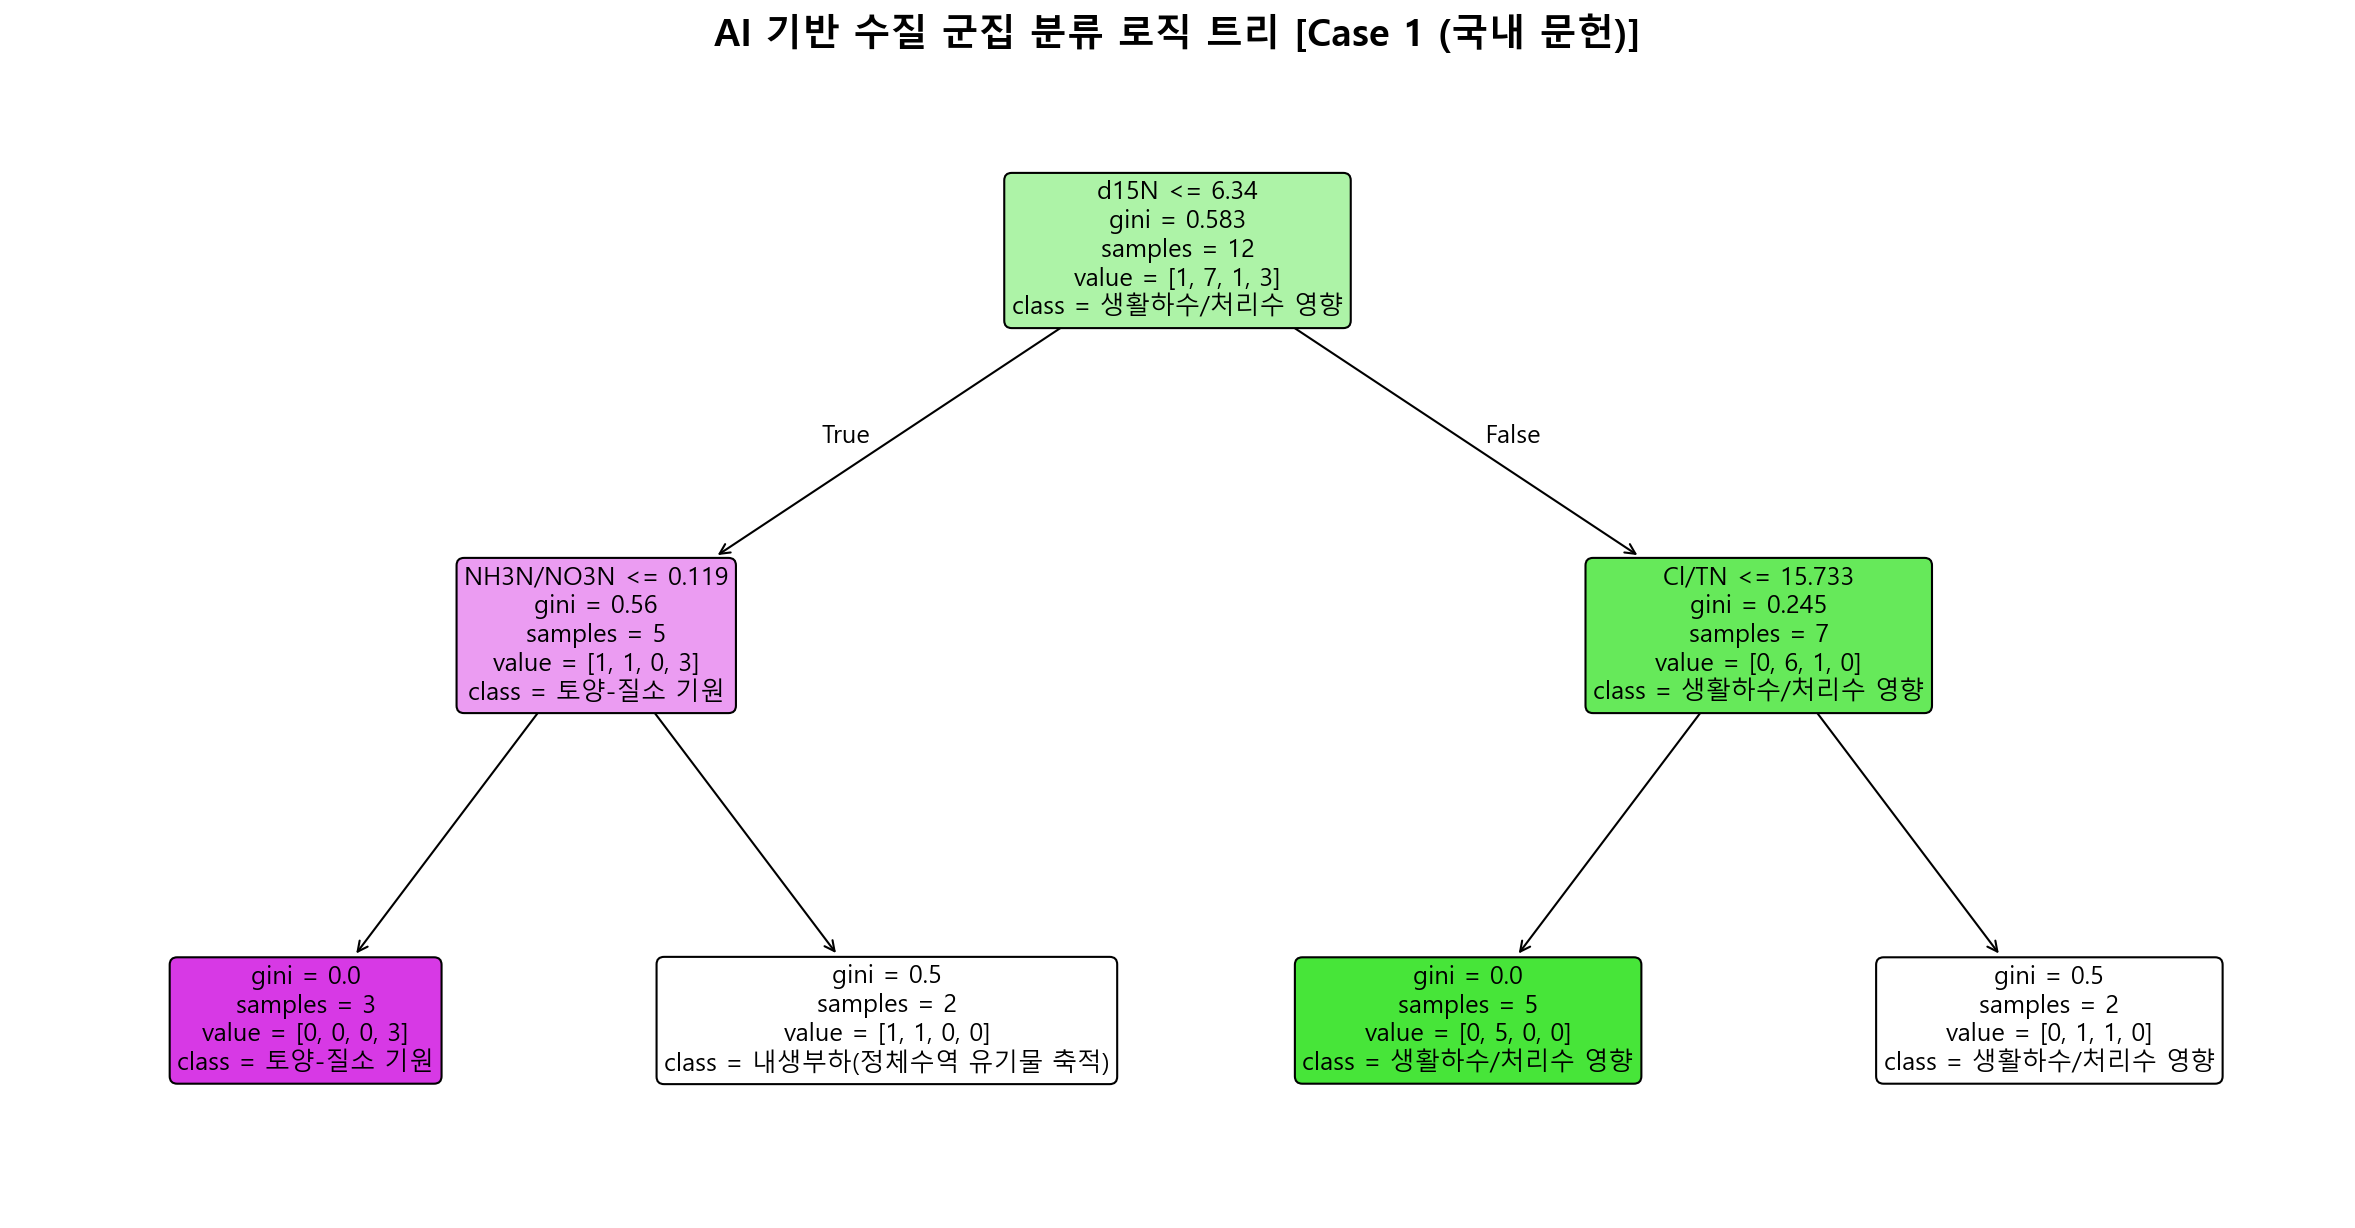

  - Decision Tree 시각화 완료


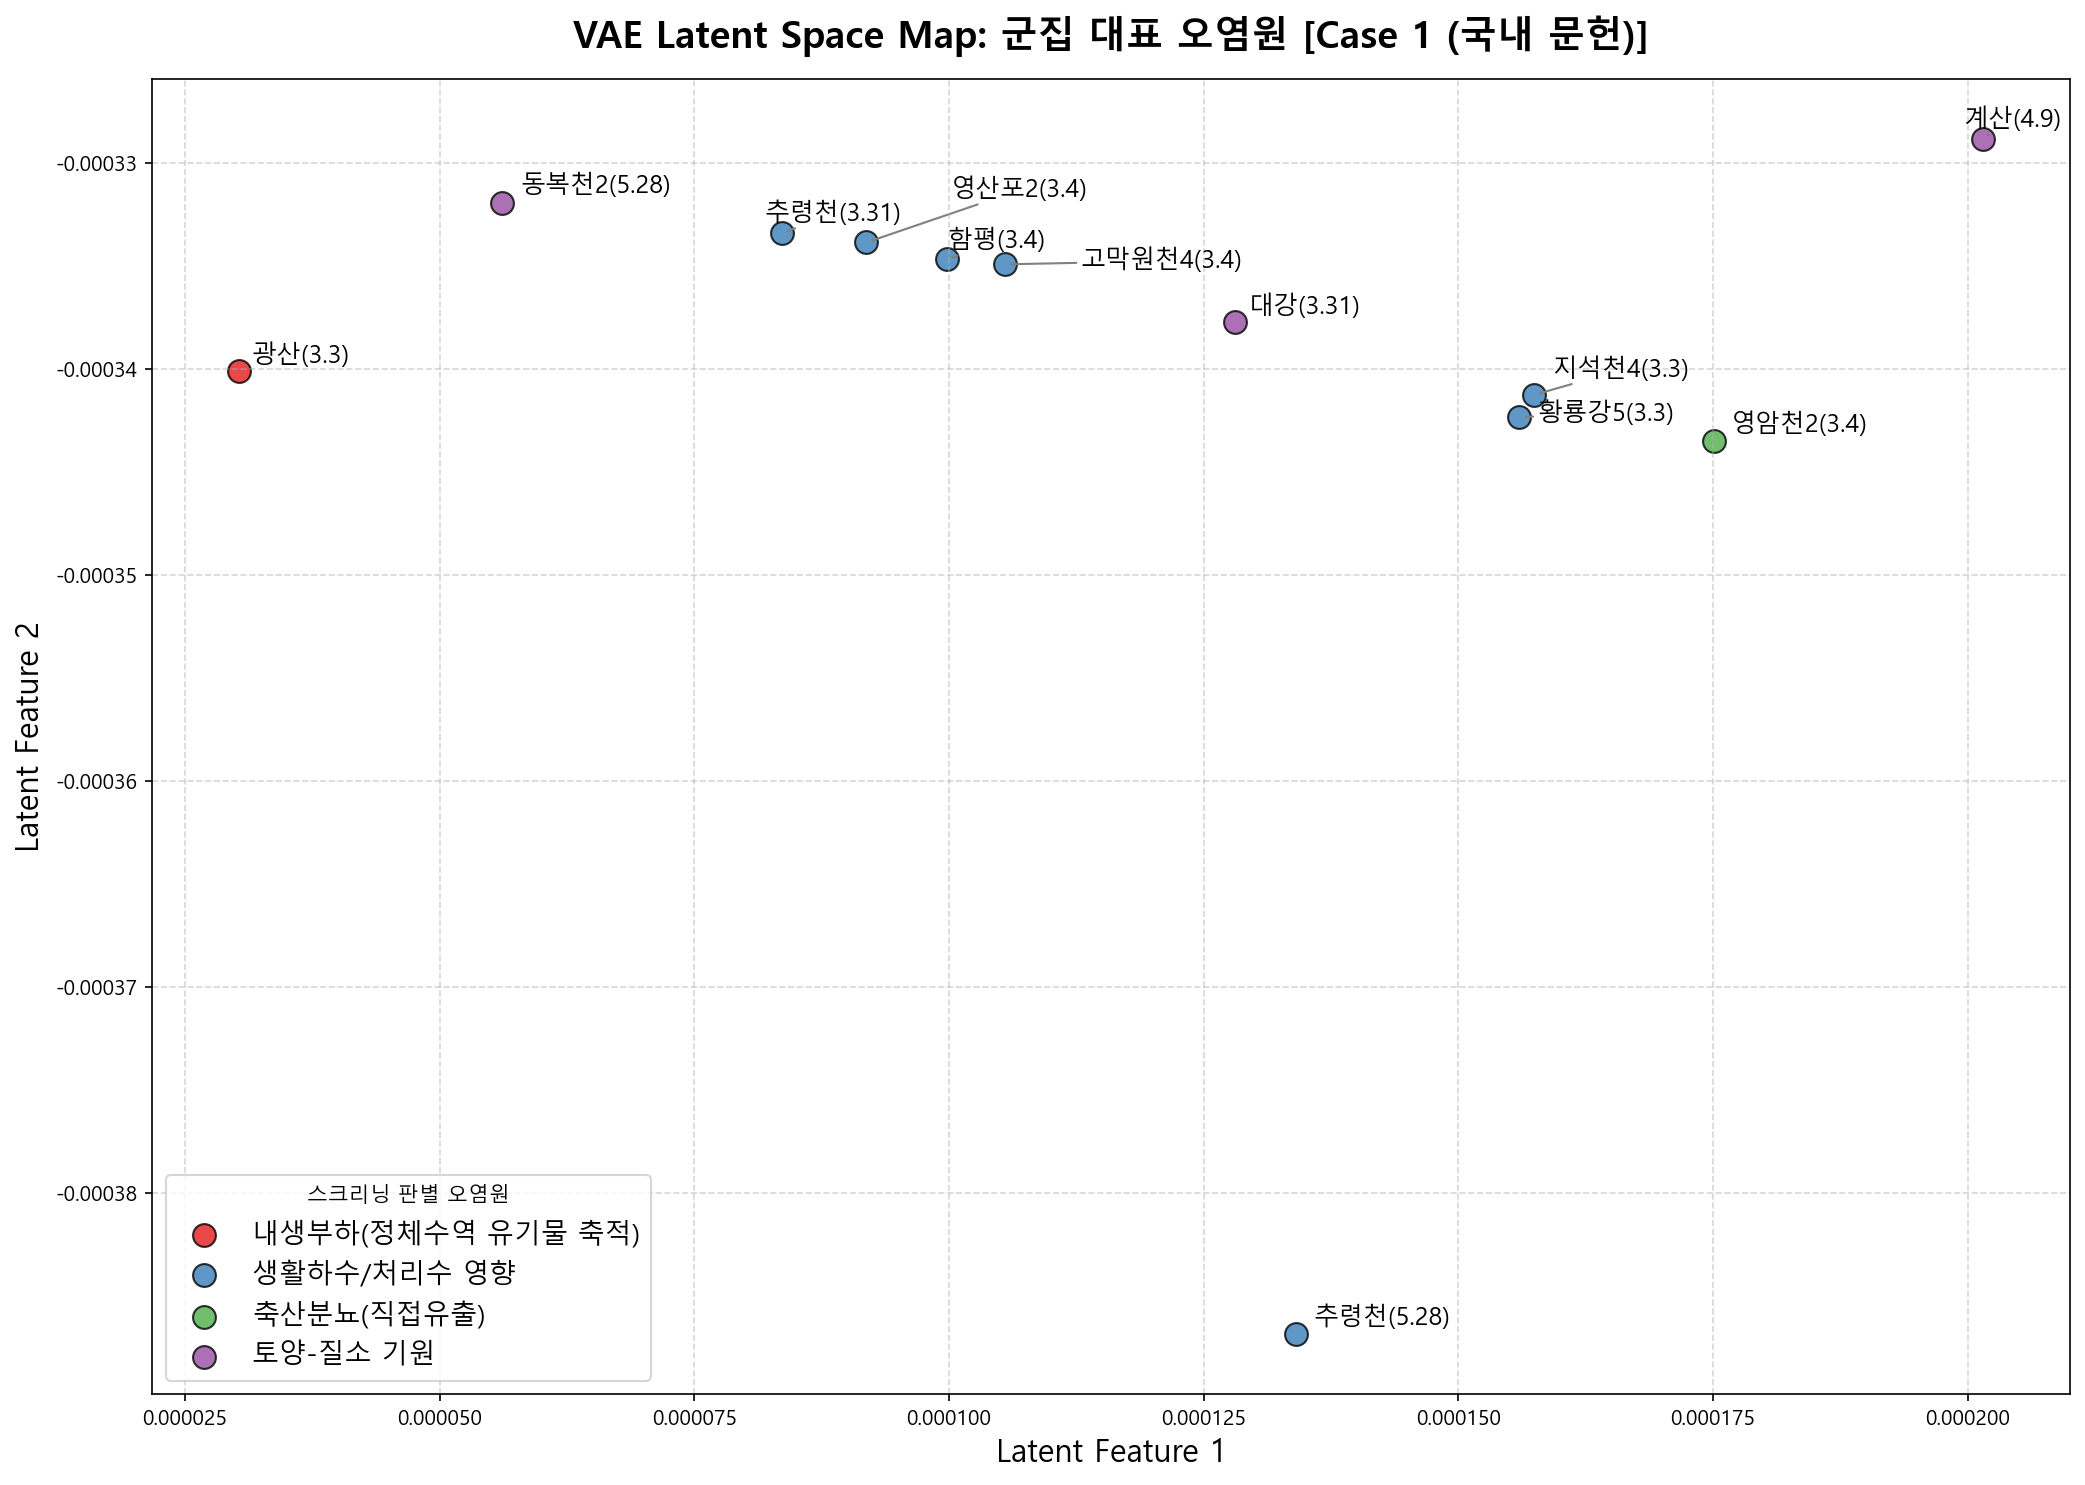

  - 군집 대표 오염원 지도 완료


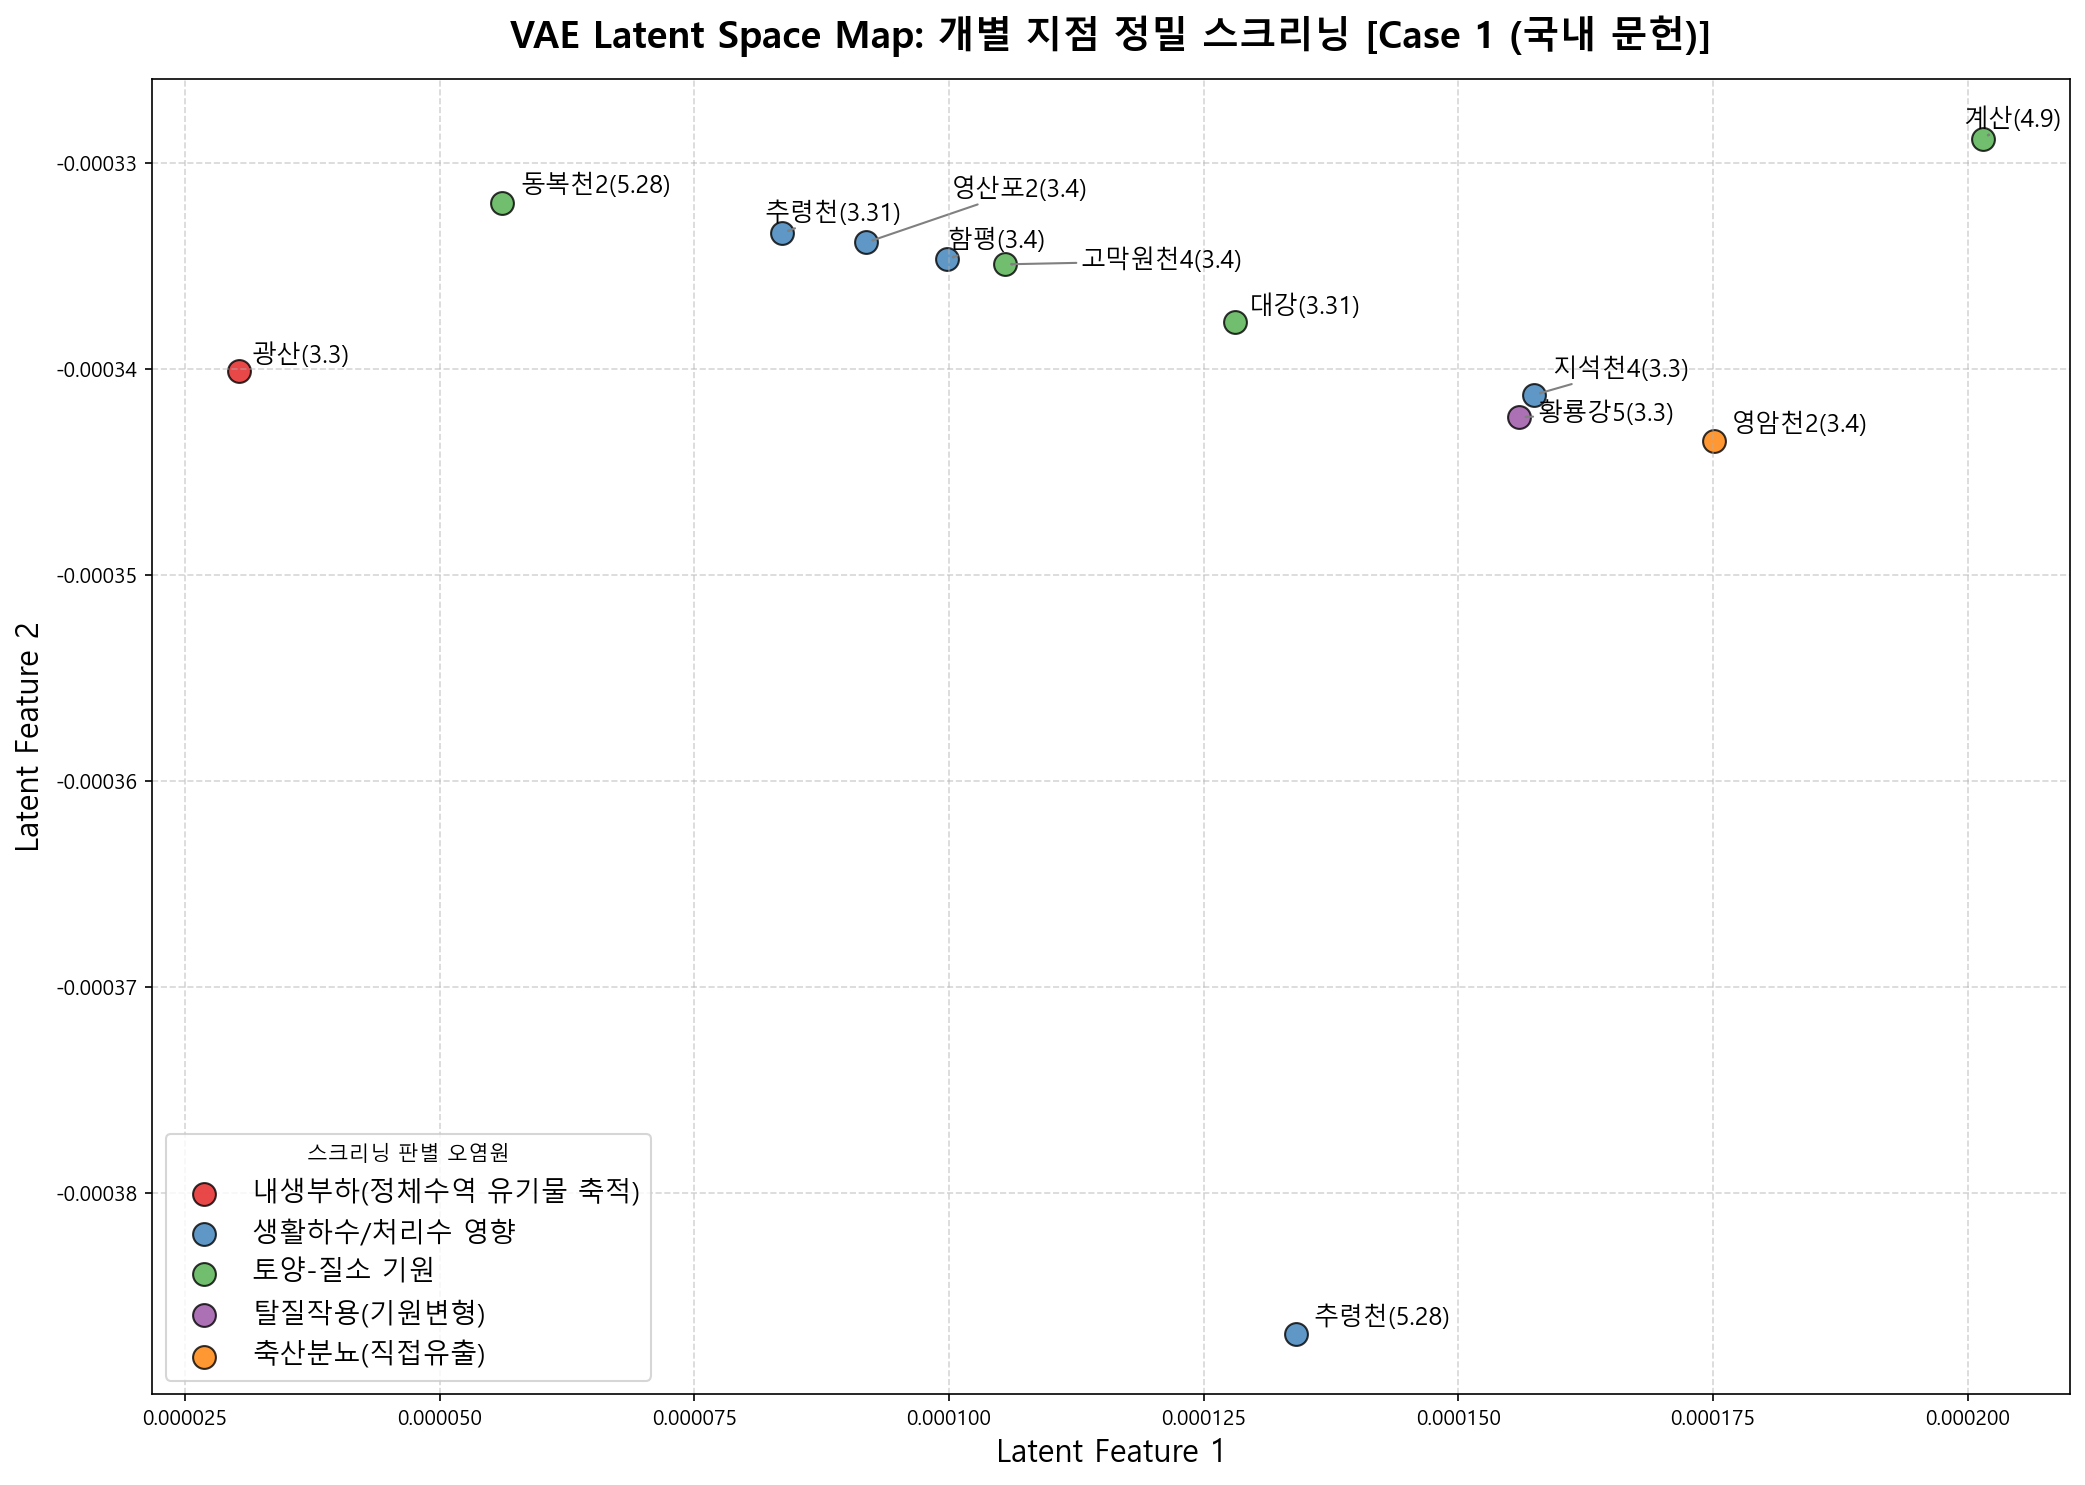

  - 개별 지점 정밀 스크리닝 지도 완료

>>> [Case 2 (국외 문헌)] 프로세스 시작...


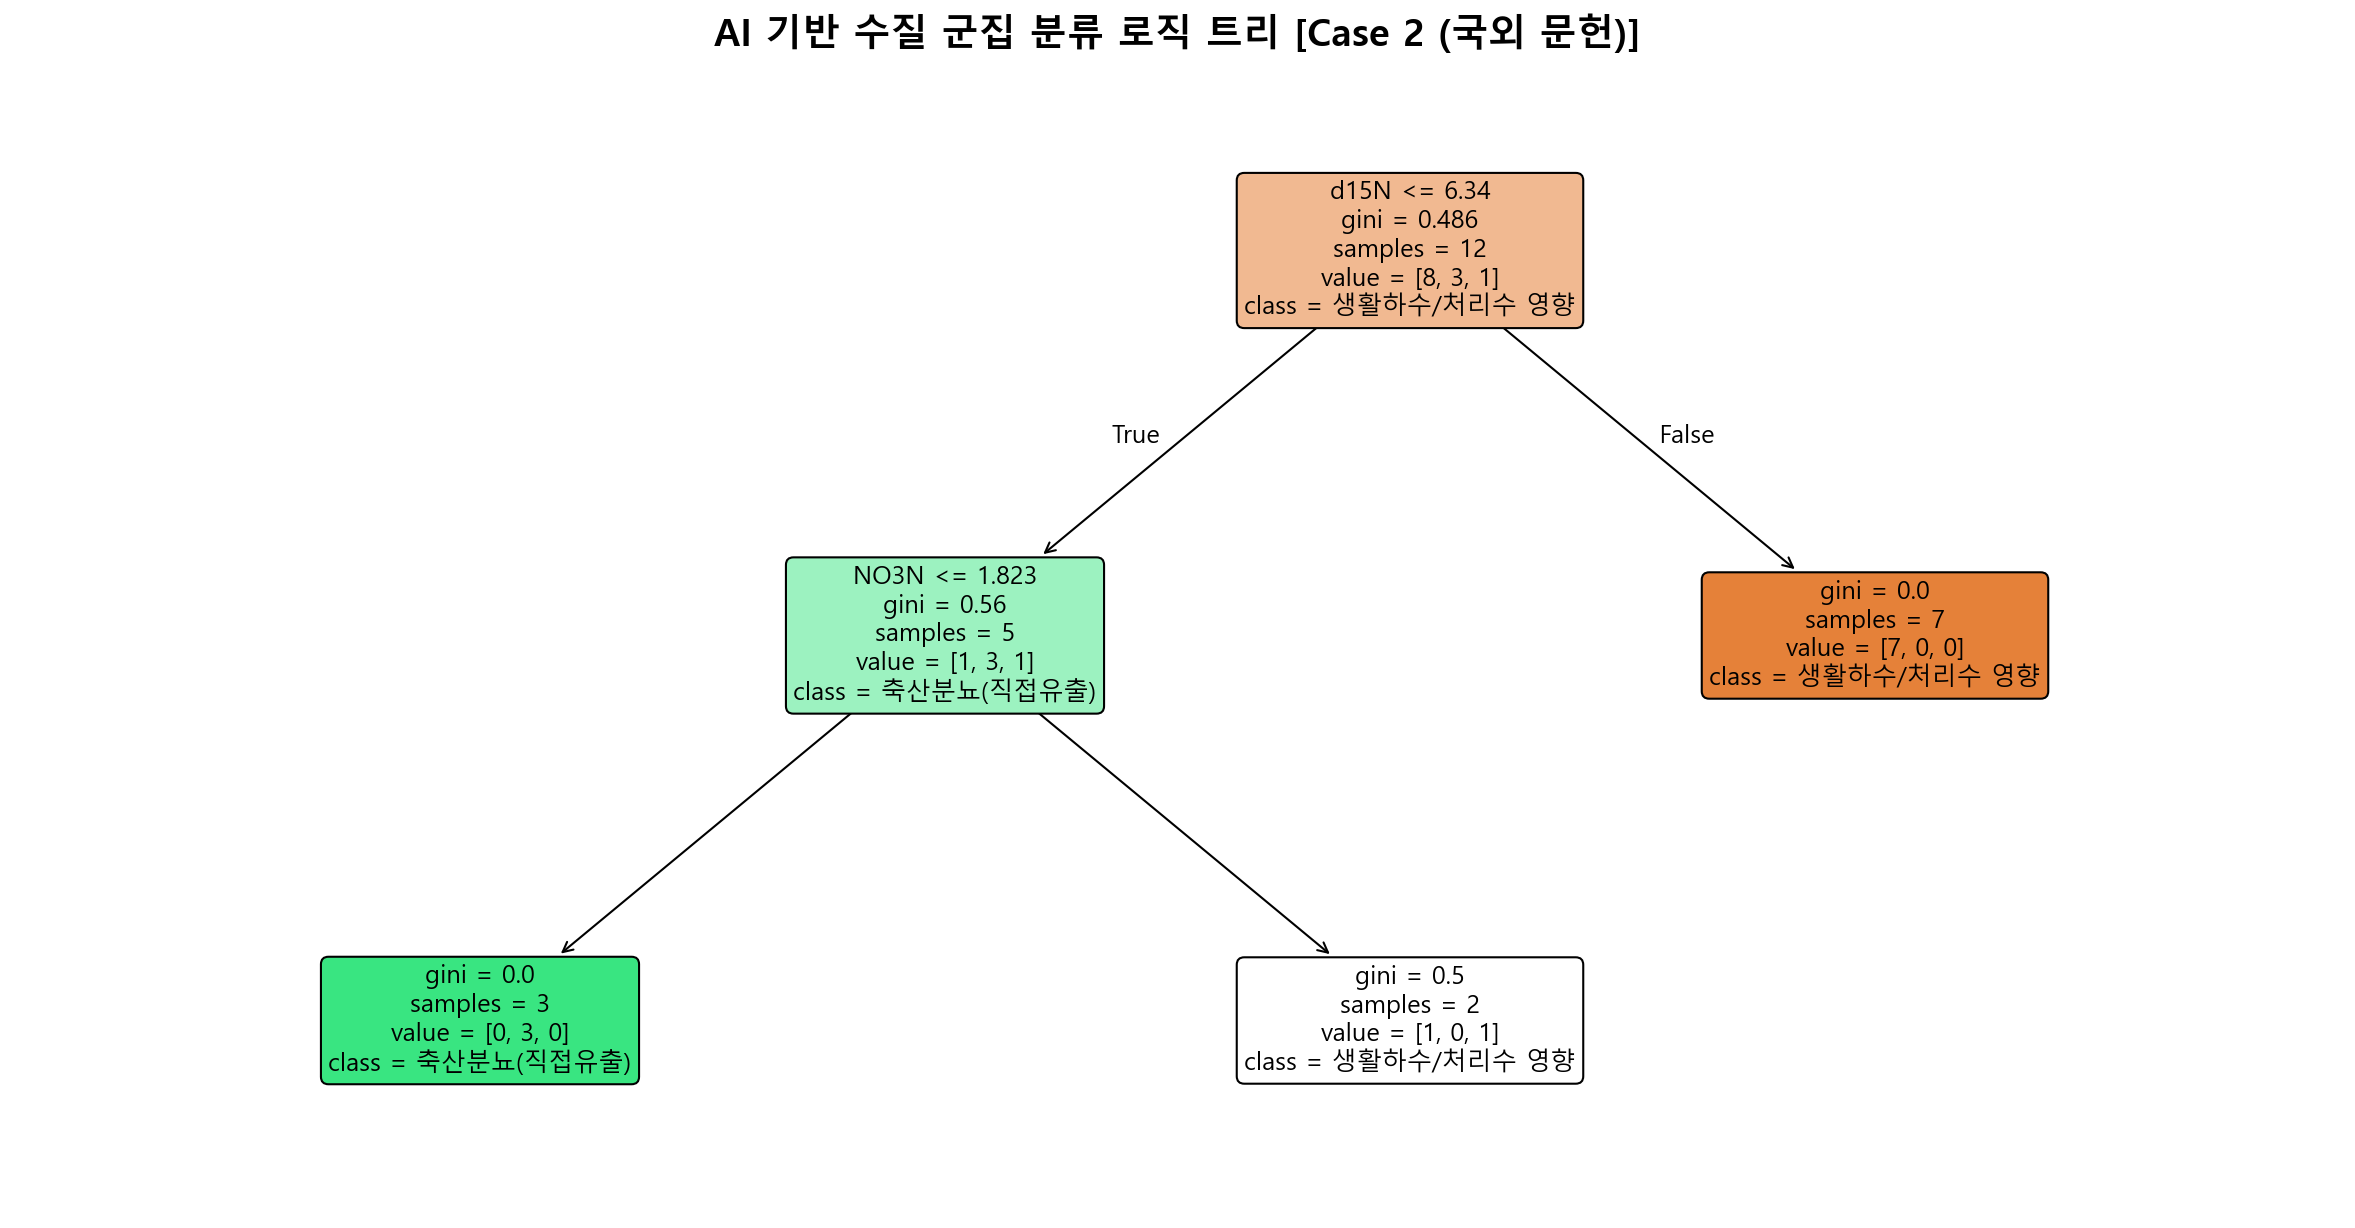

  - Decision Tree 시각화 완료


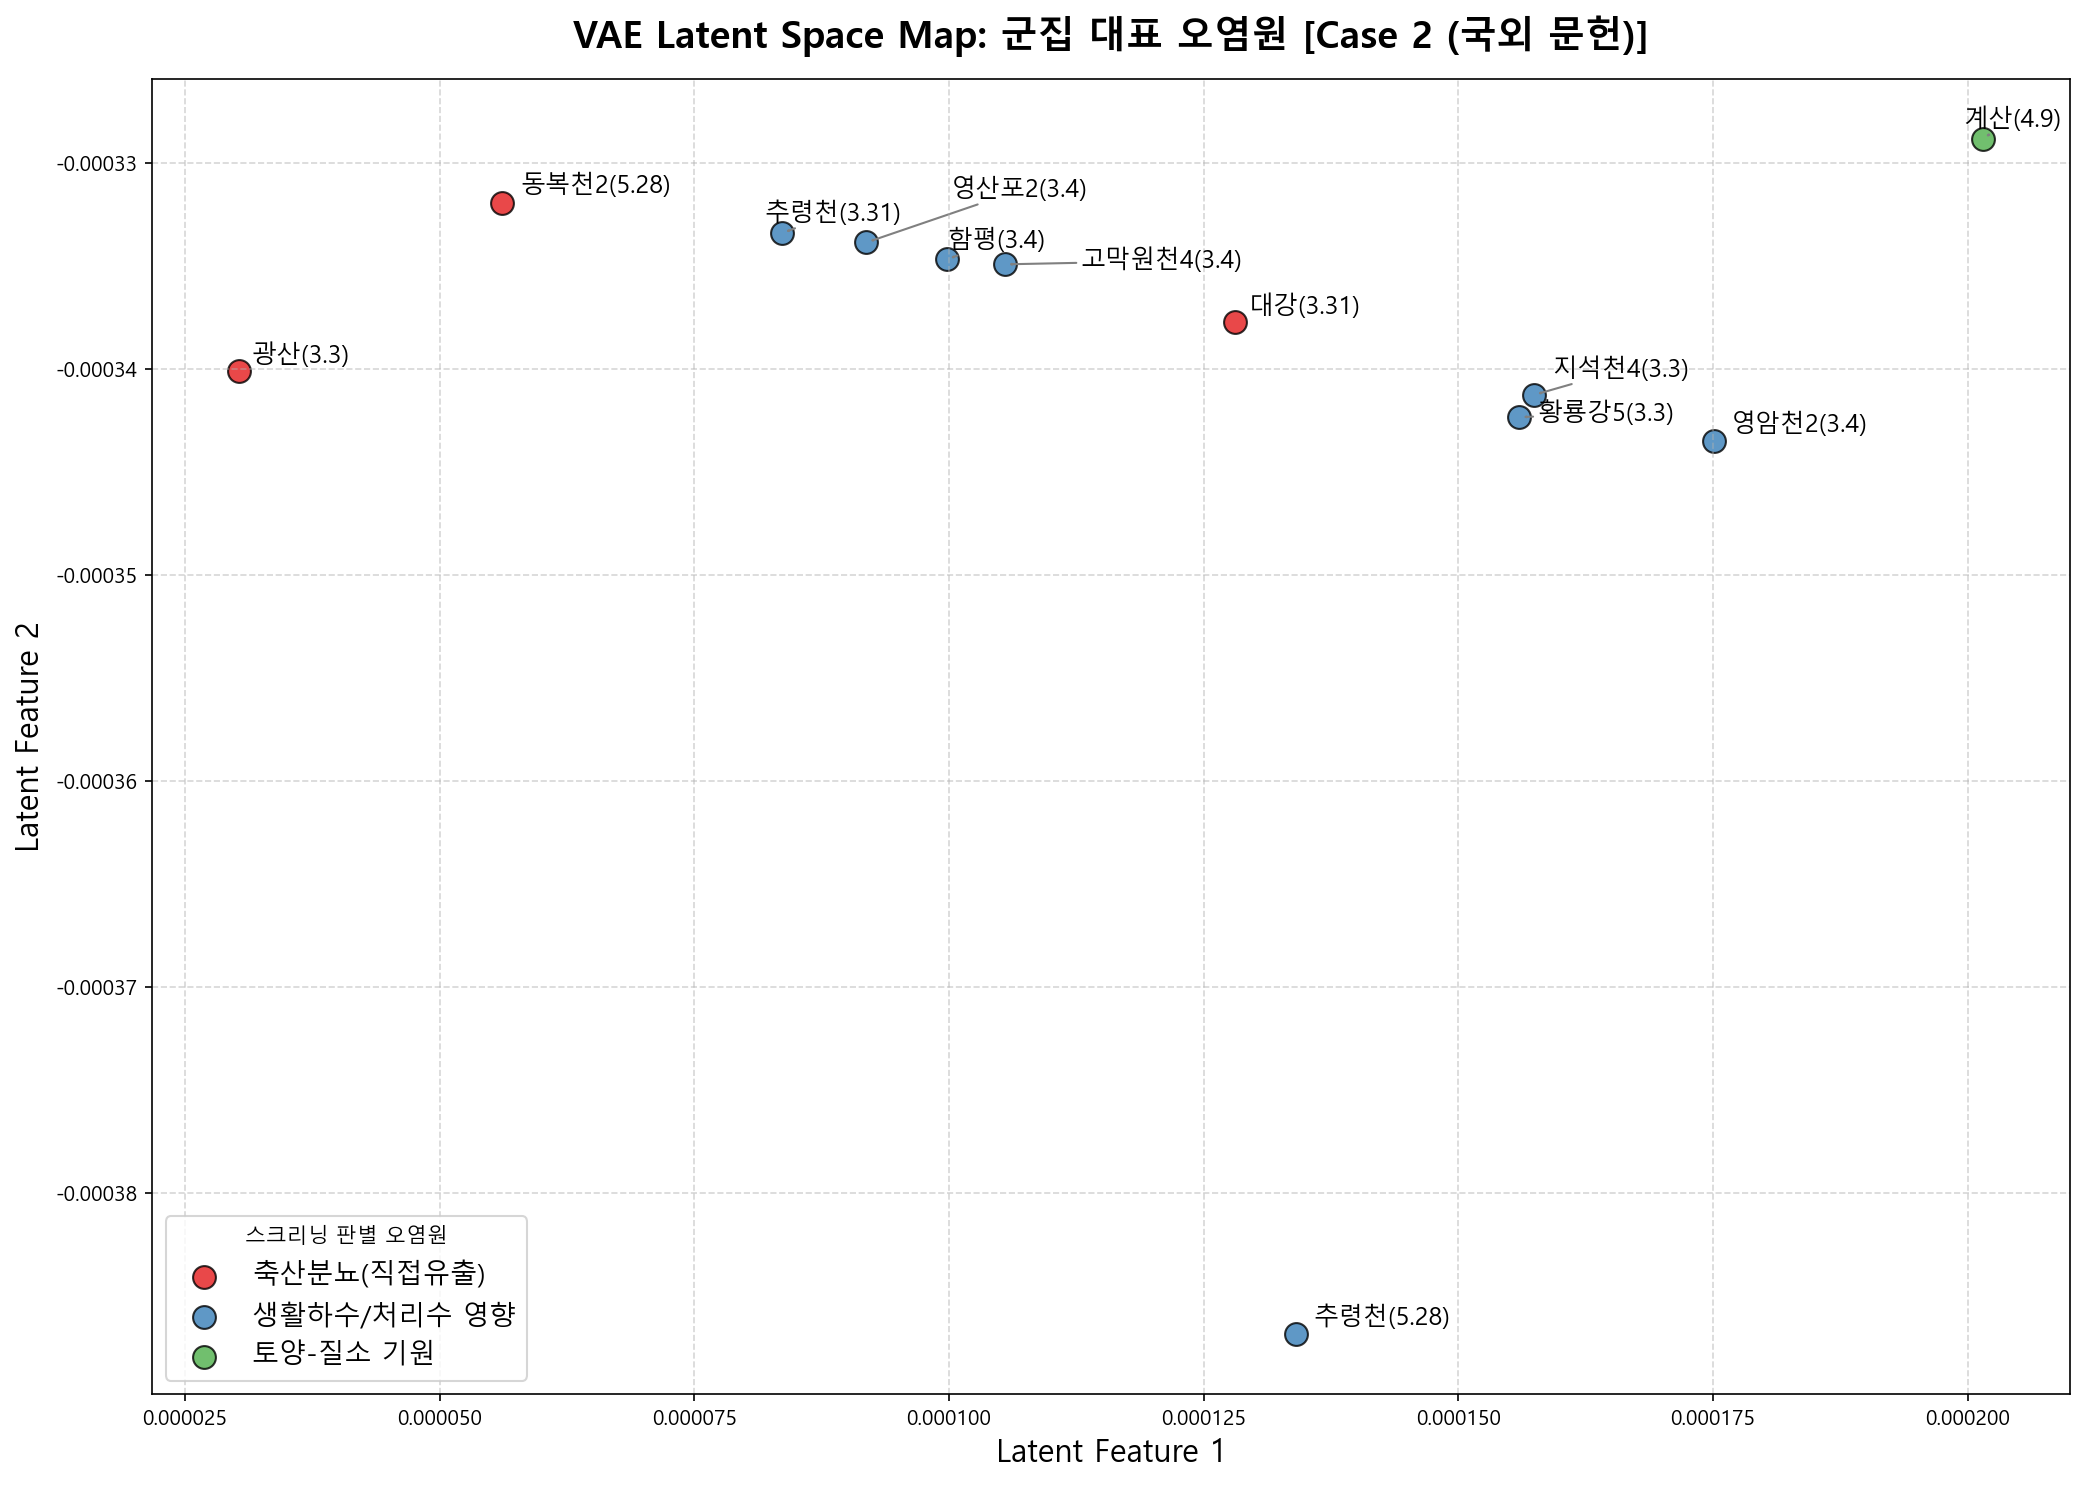

  - 군집 대표 오염원 지도 완료


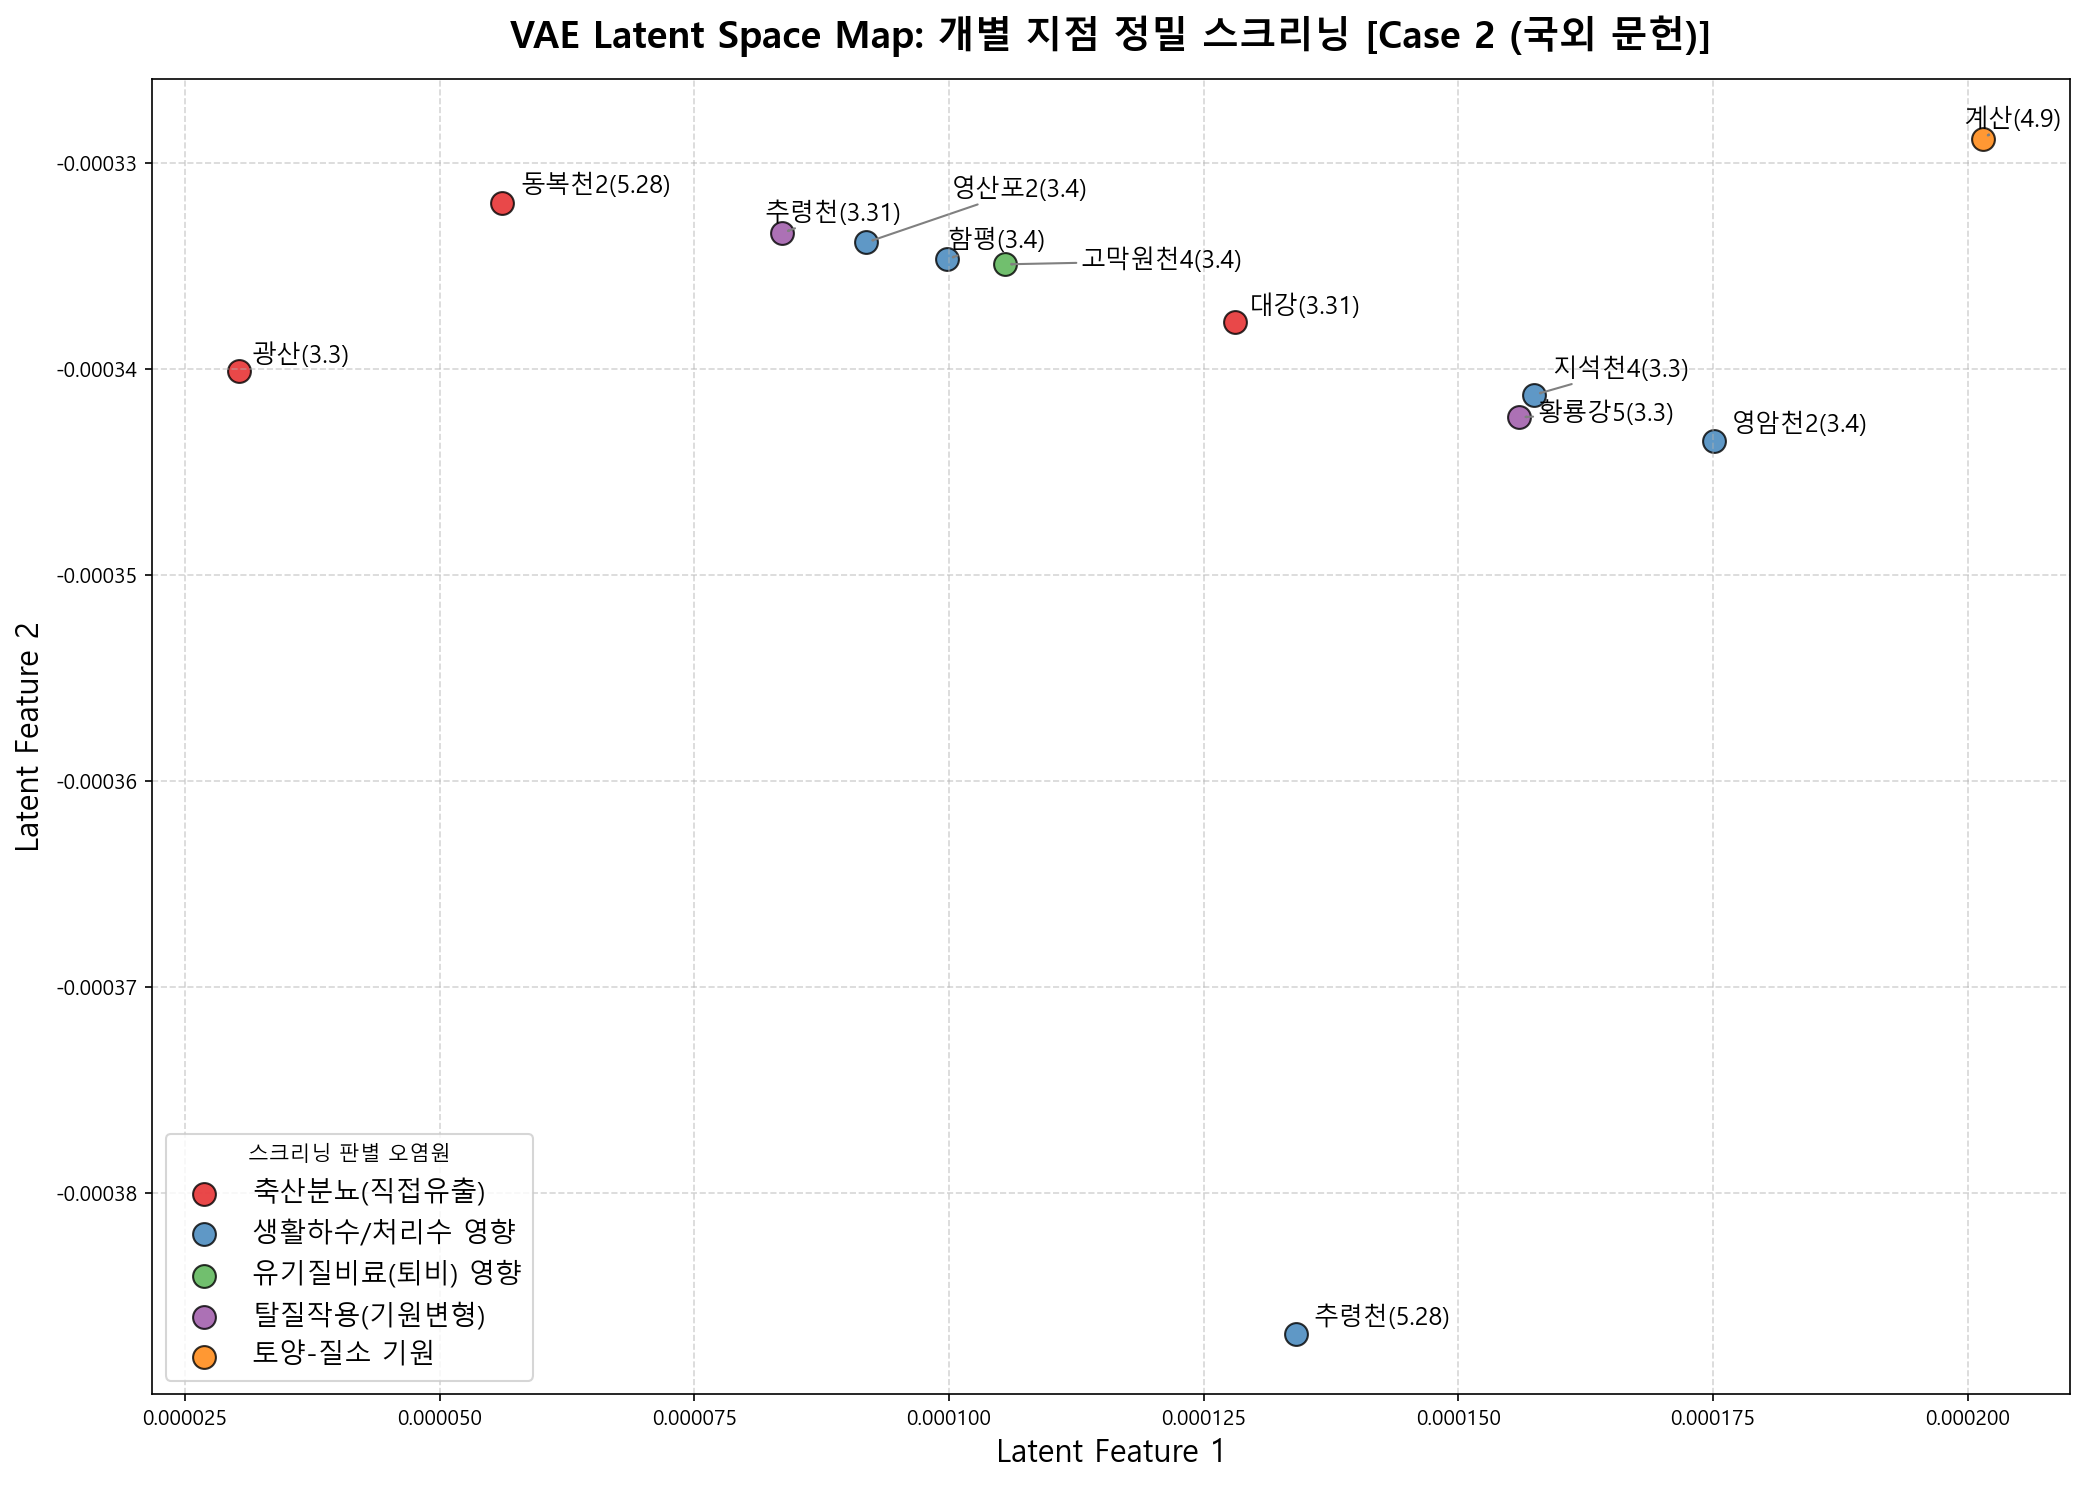

  - 개별 지점 정밀 스크리닝 지도 완료

>>> [Case 3 (통합 문헌)] 프로세스 시작...


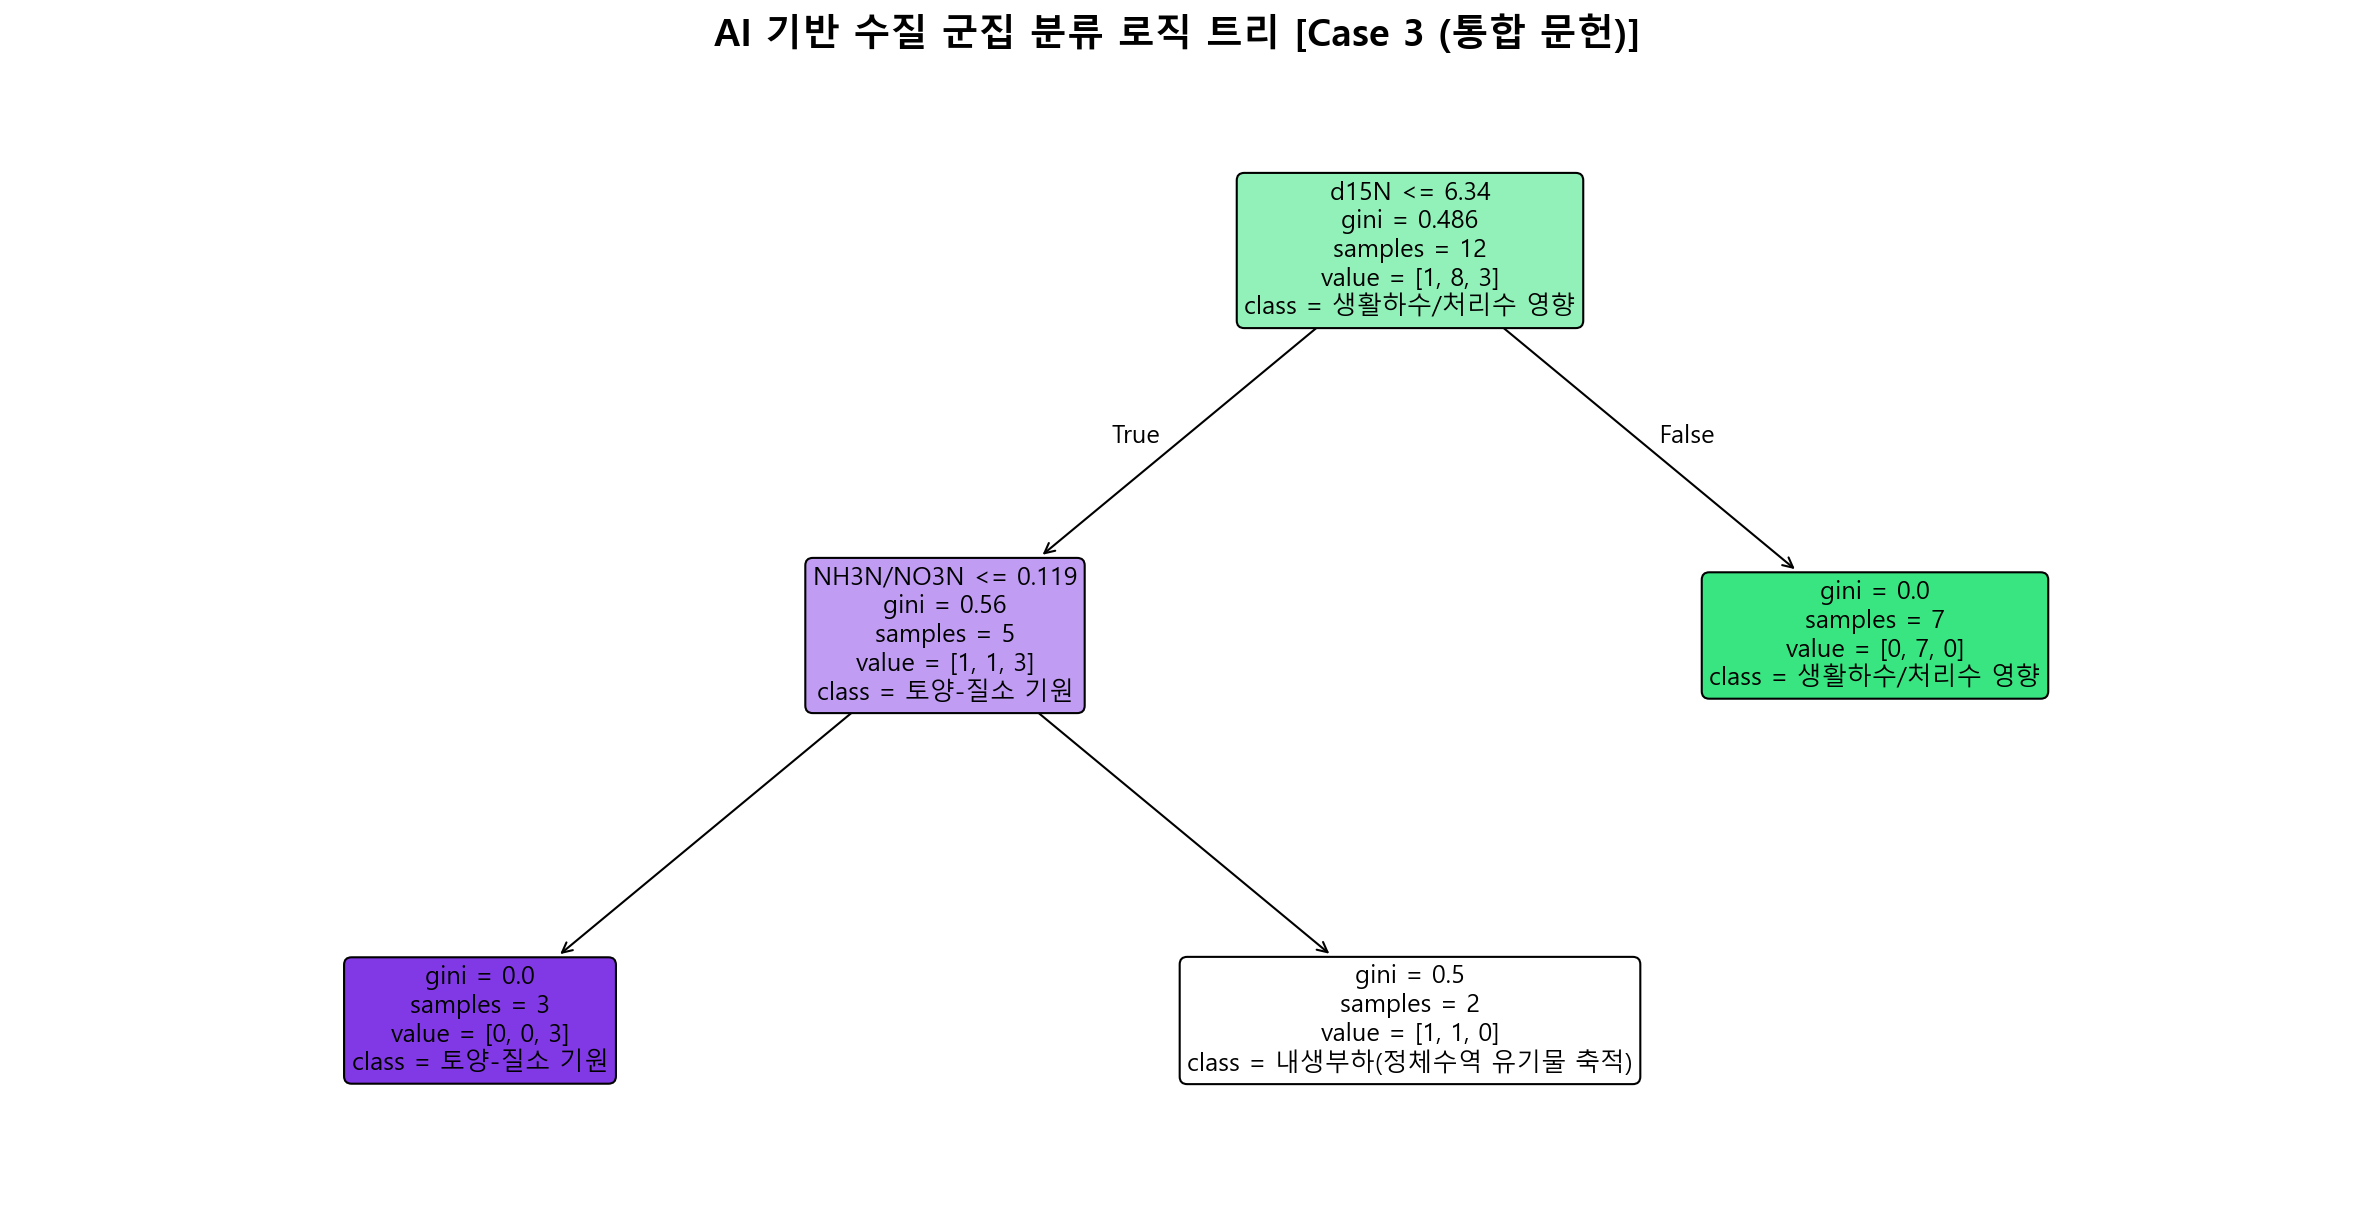

  - Decision Tree 시각화 완료


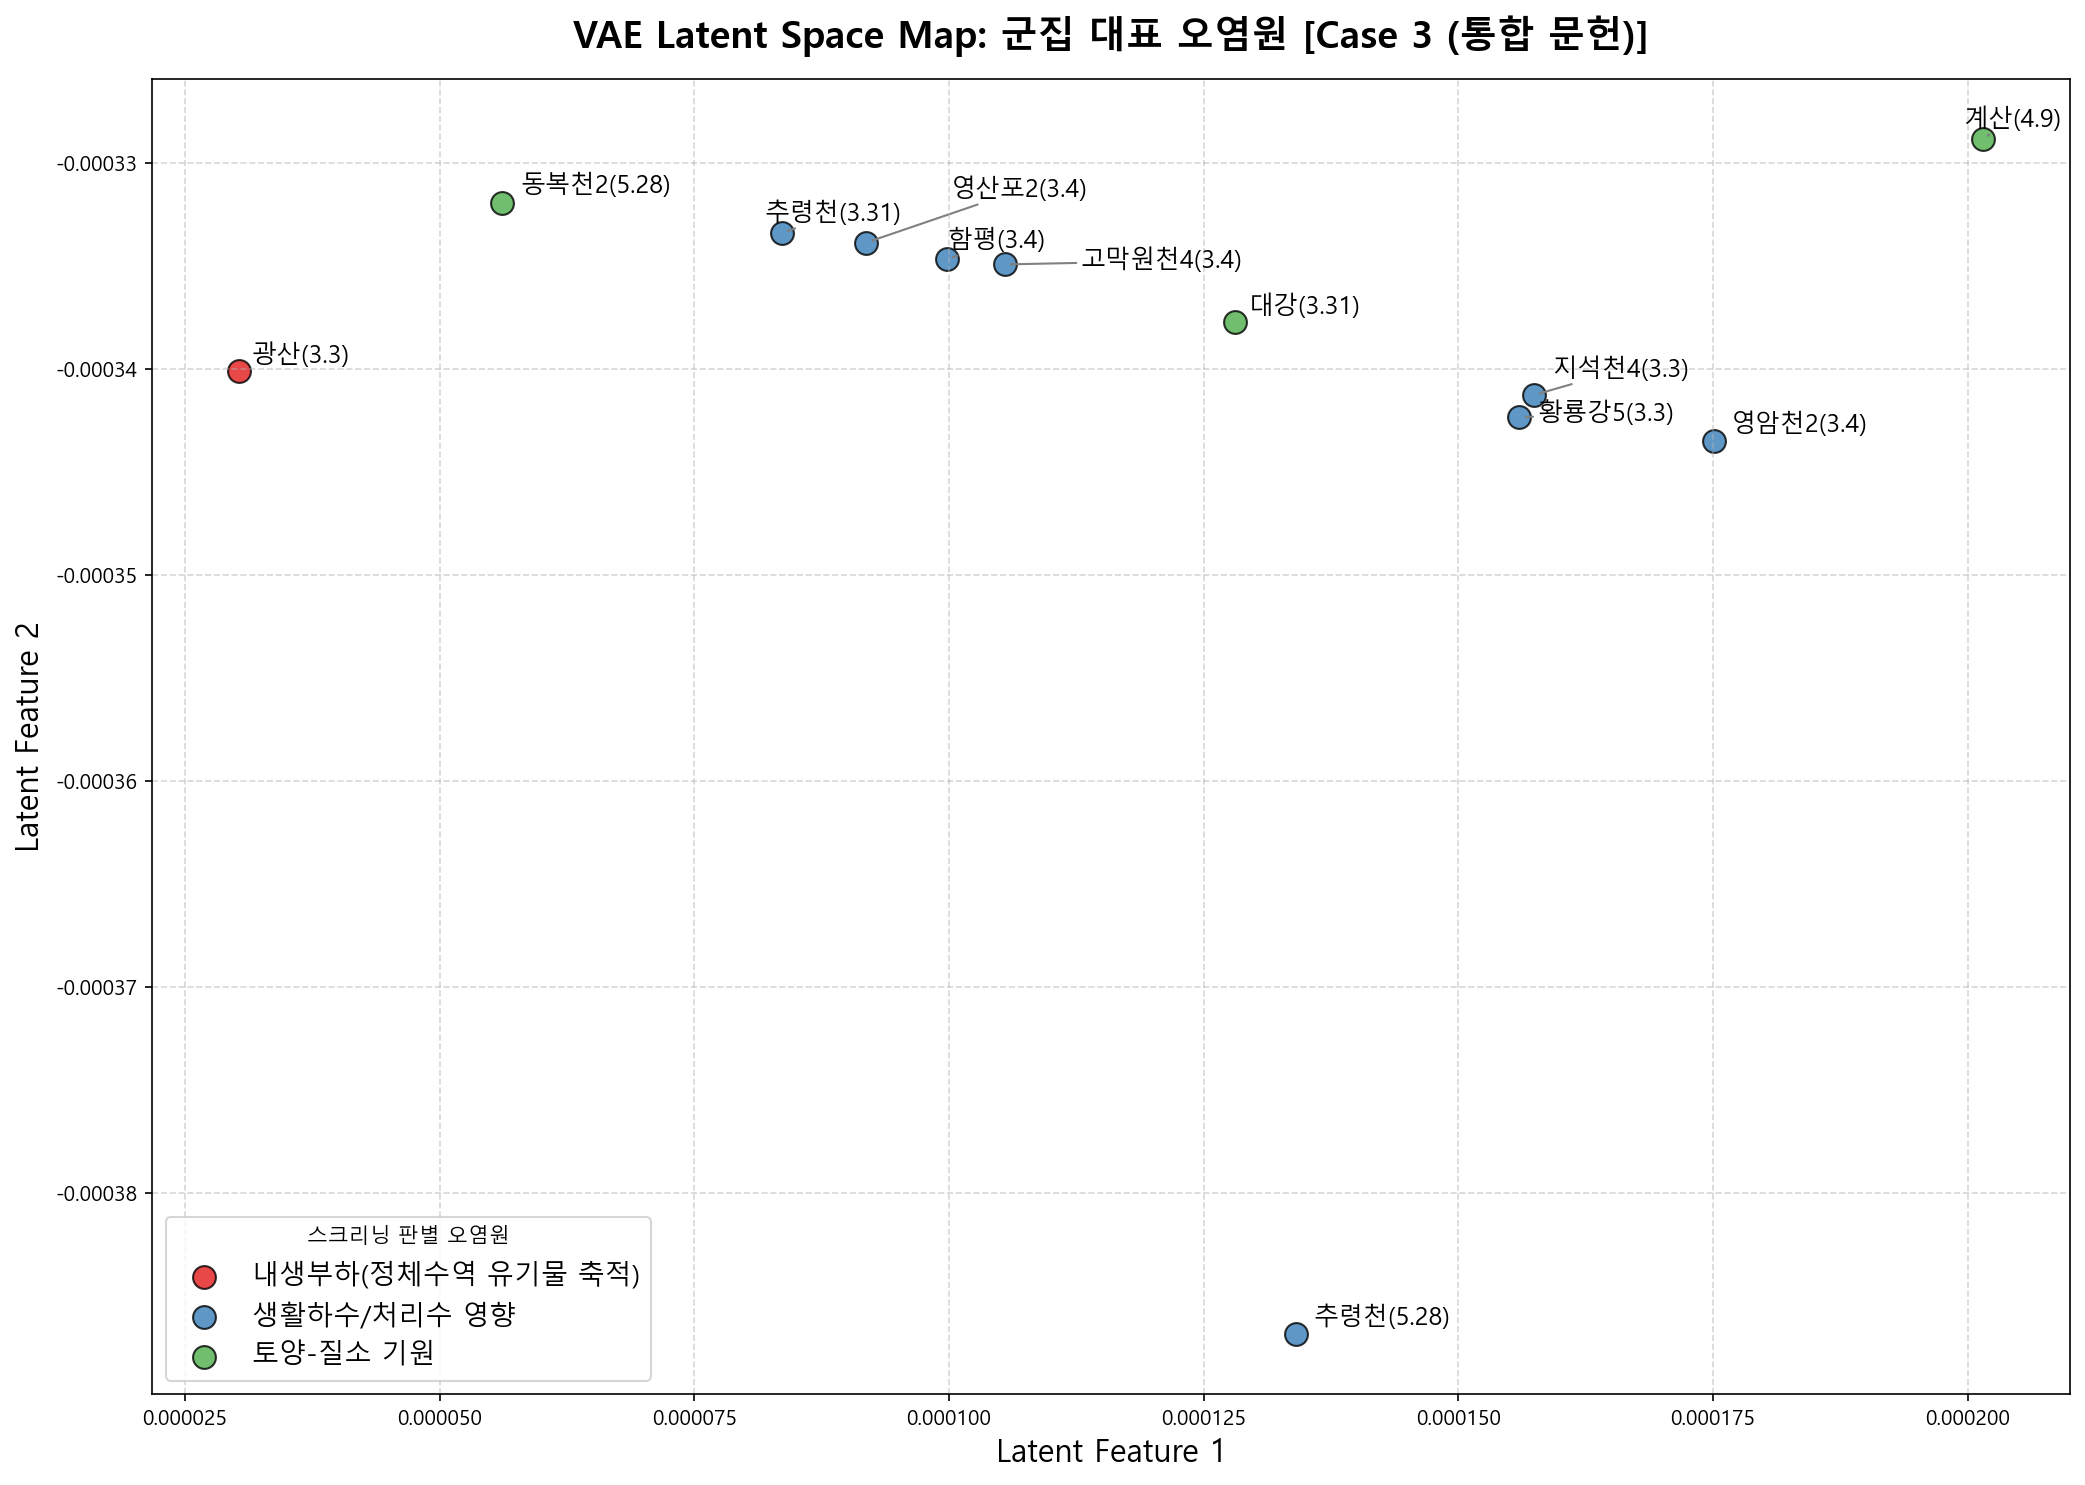

  - 군집 대표 오염원 지도 완료


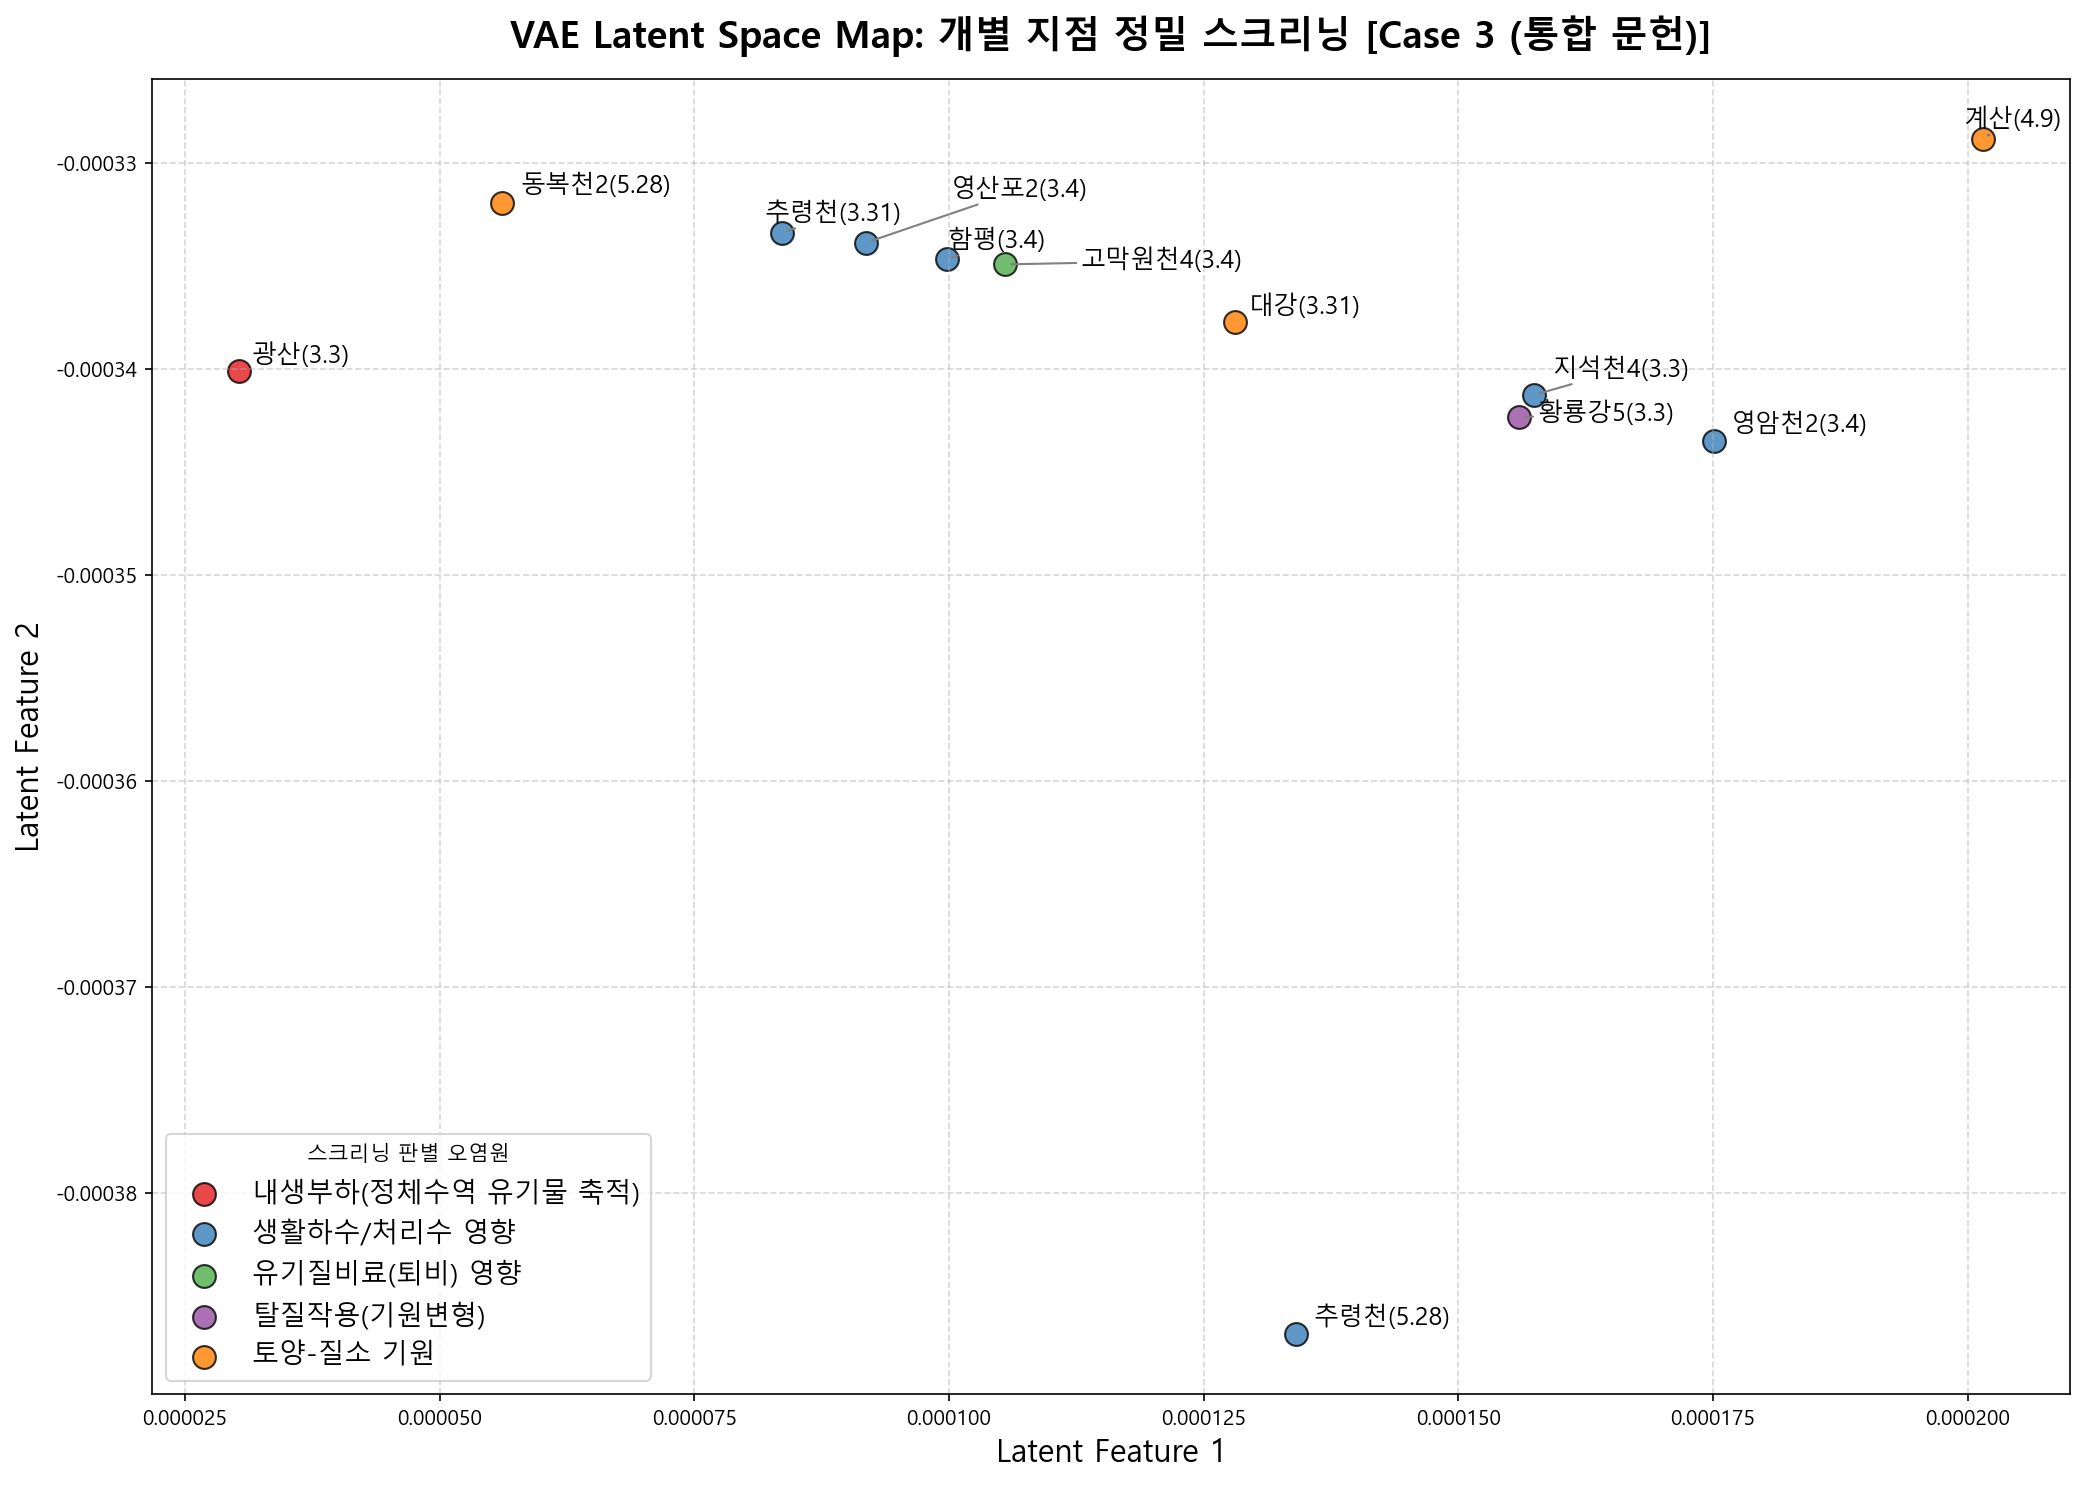

  - 개별 지점 정밀 스크리닝 지도 완료

>>> [최종 (AI 보정)] 프로세스 시작...


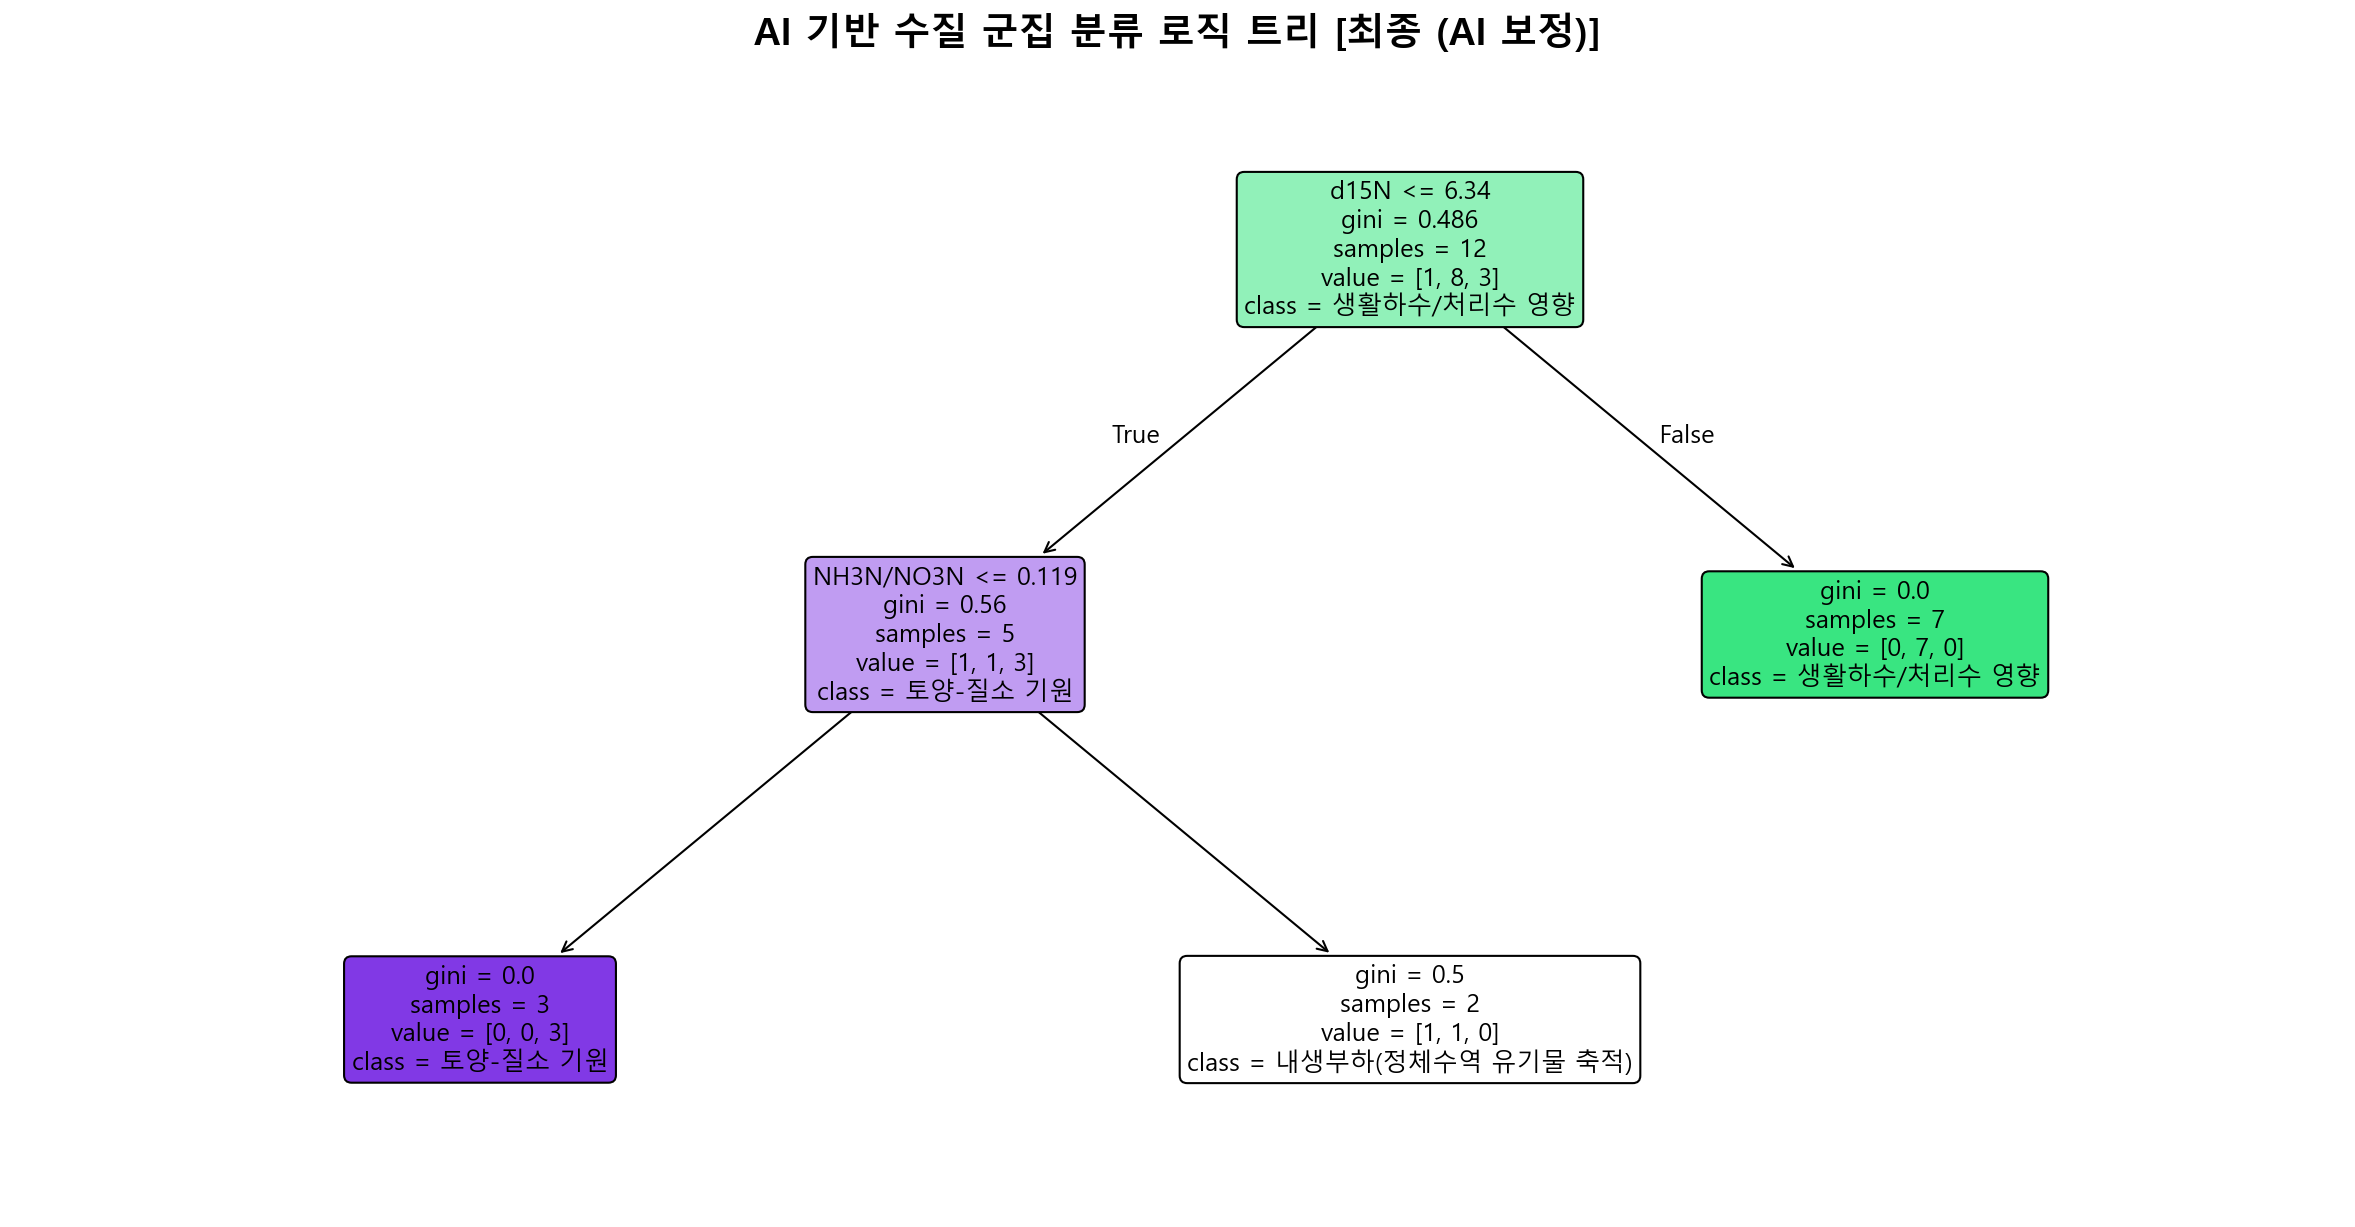

  - Decision Tree 시각화 완료


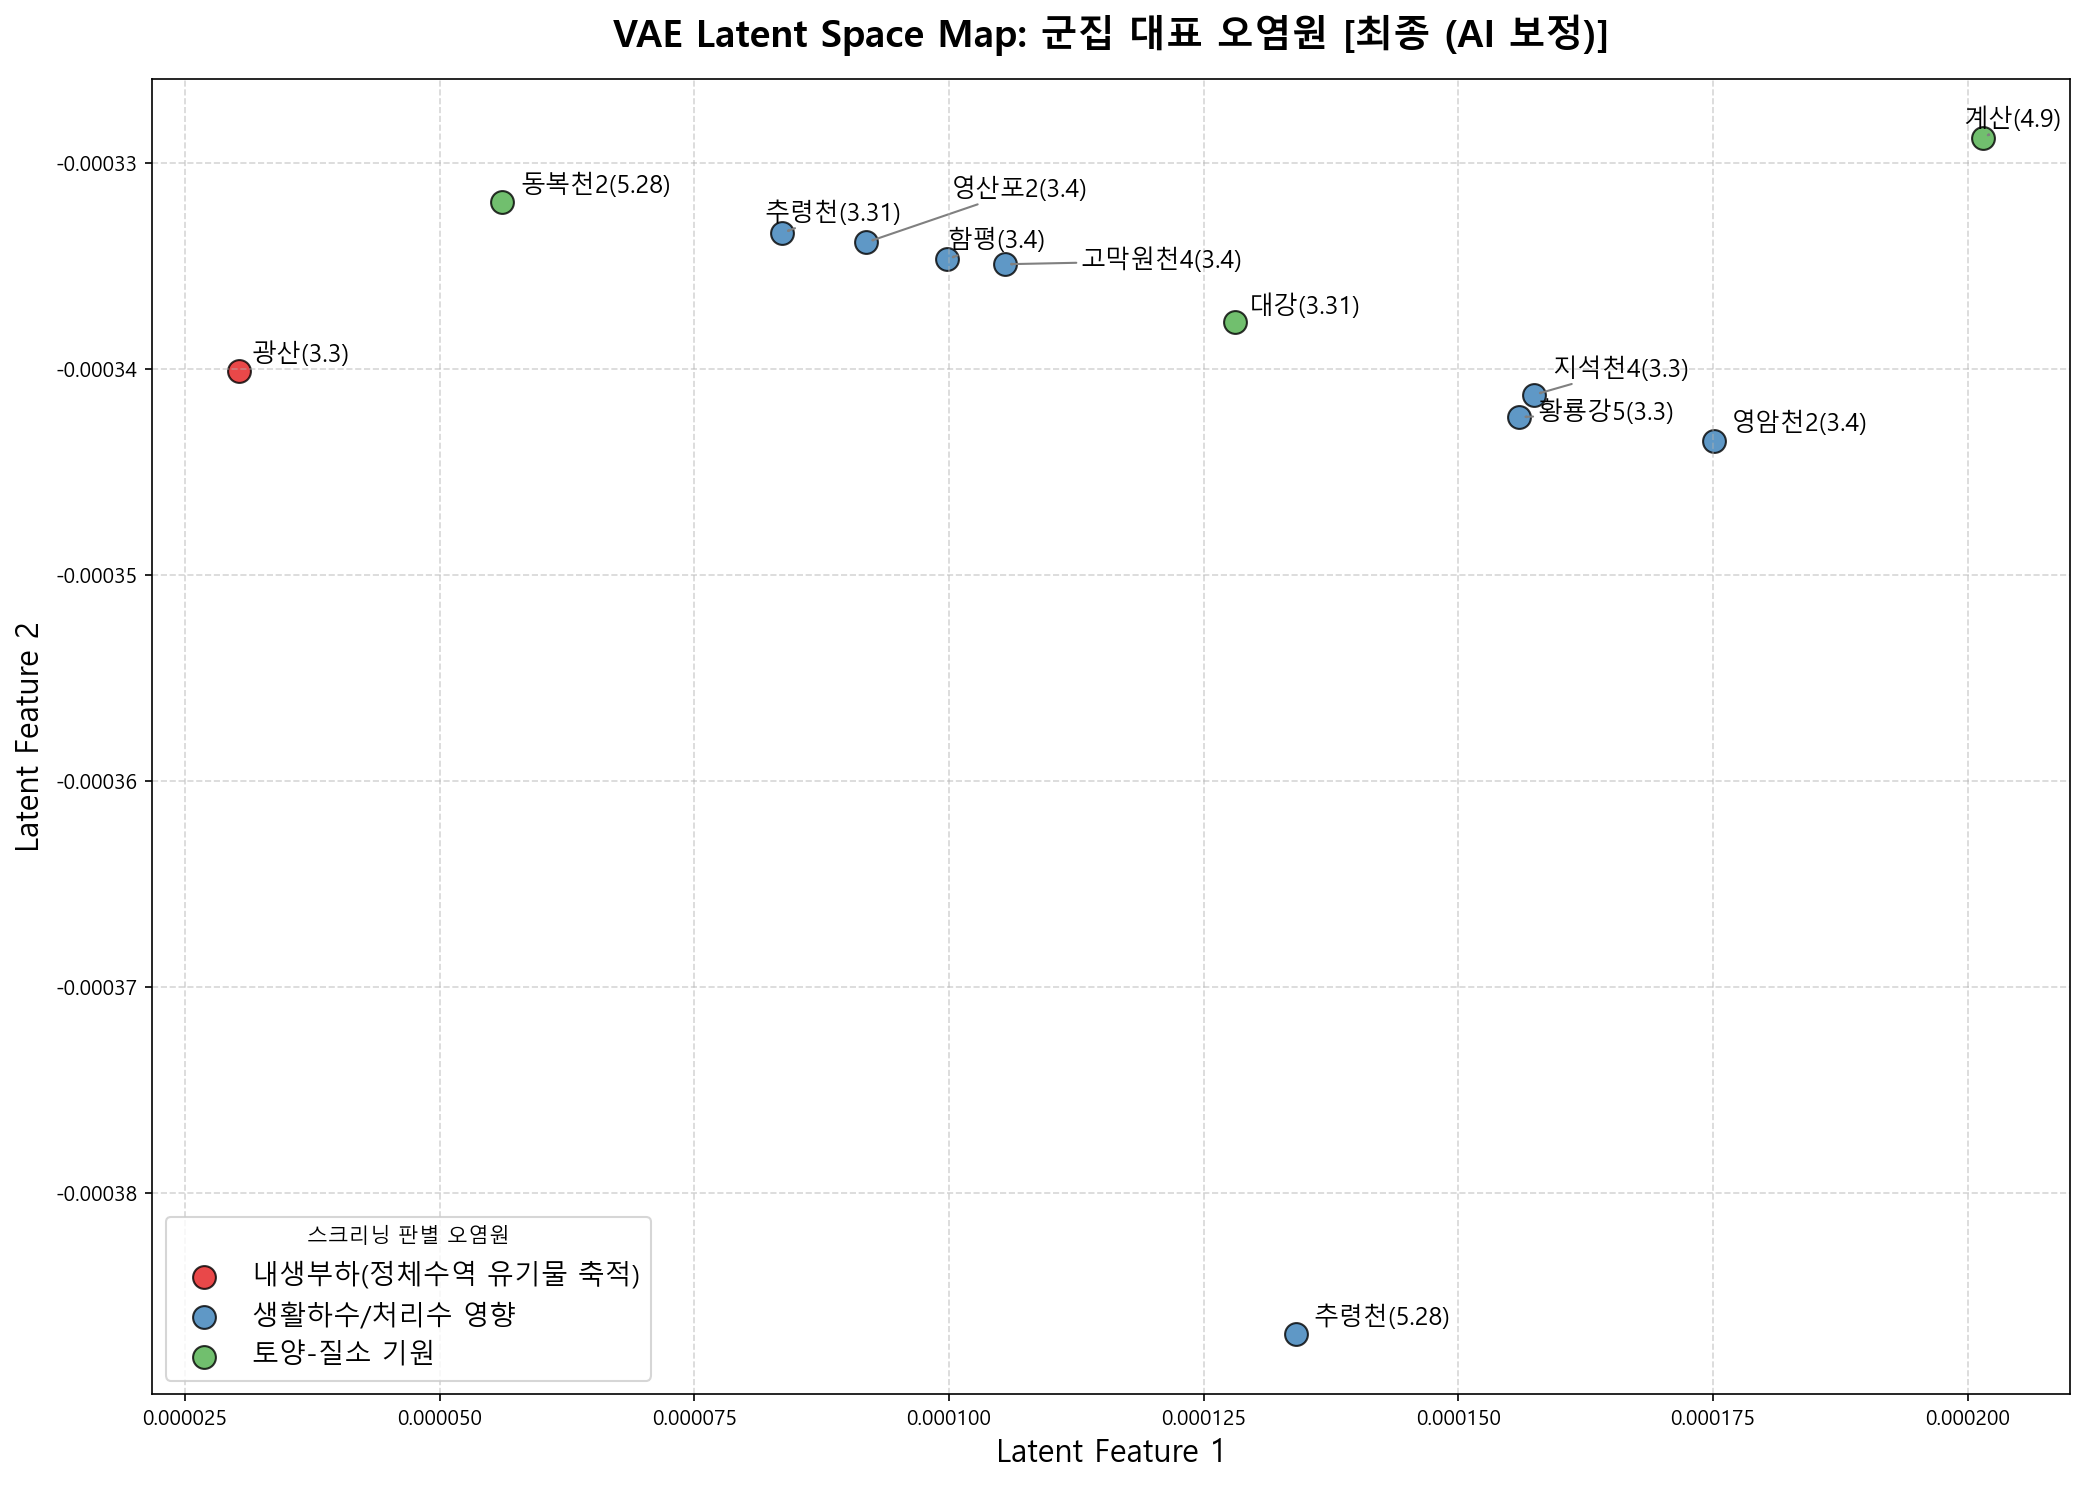

  - 군집 대표 오염원 지도 완료


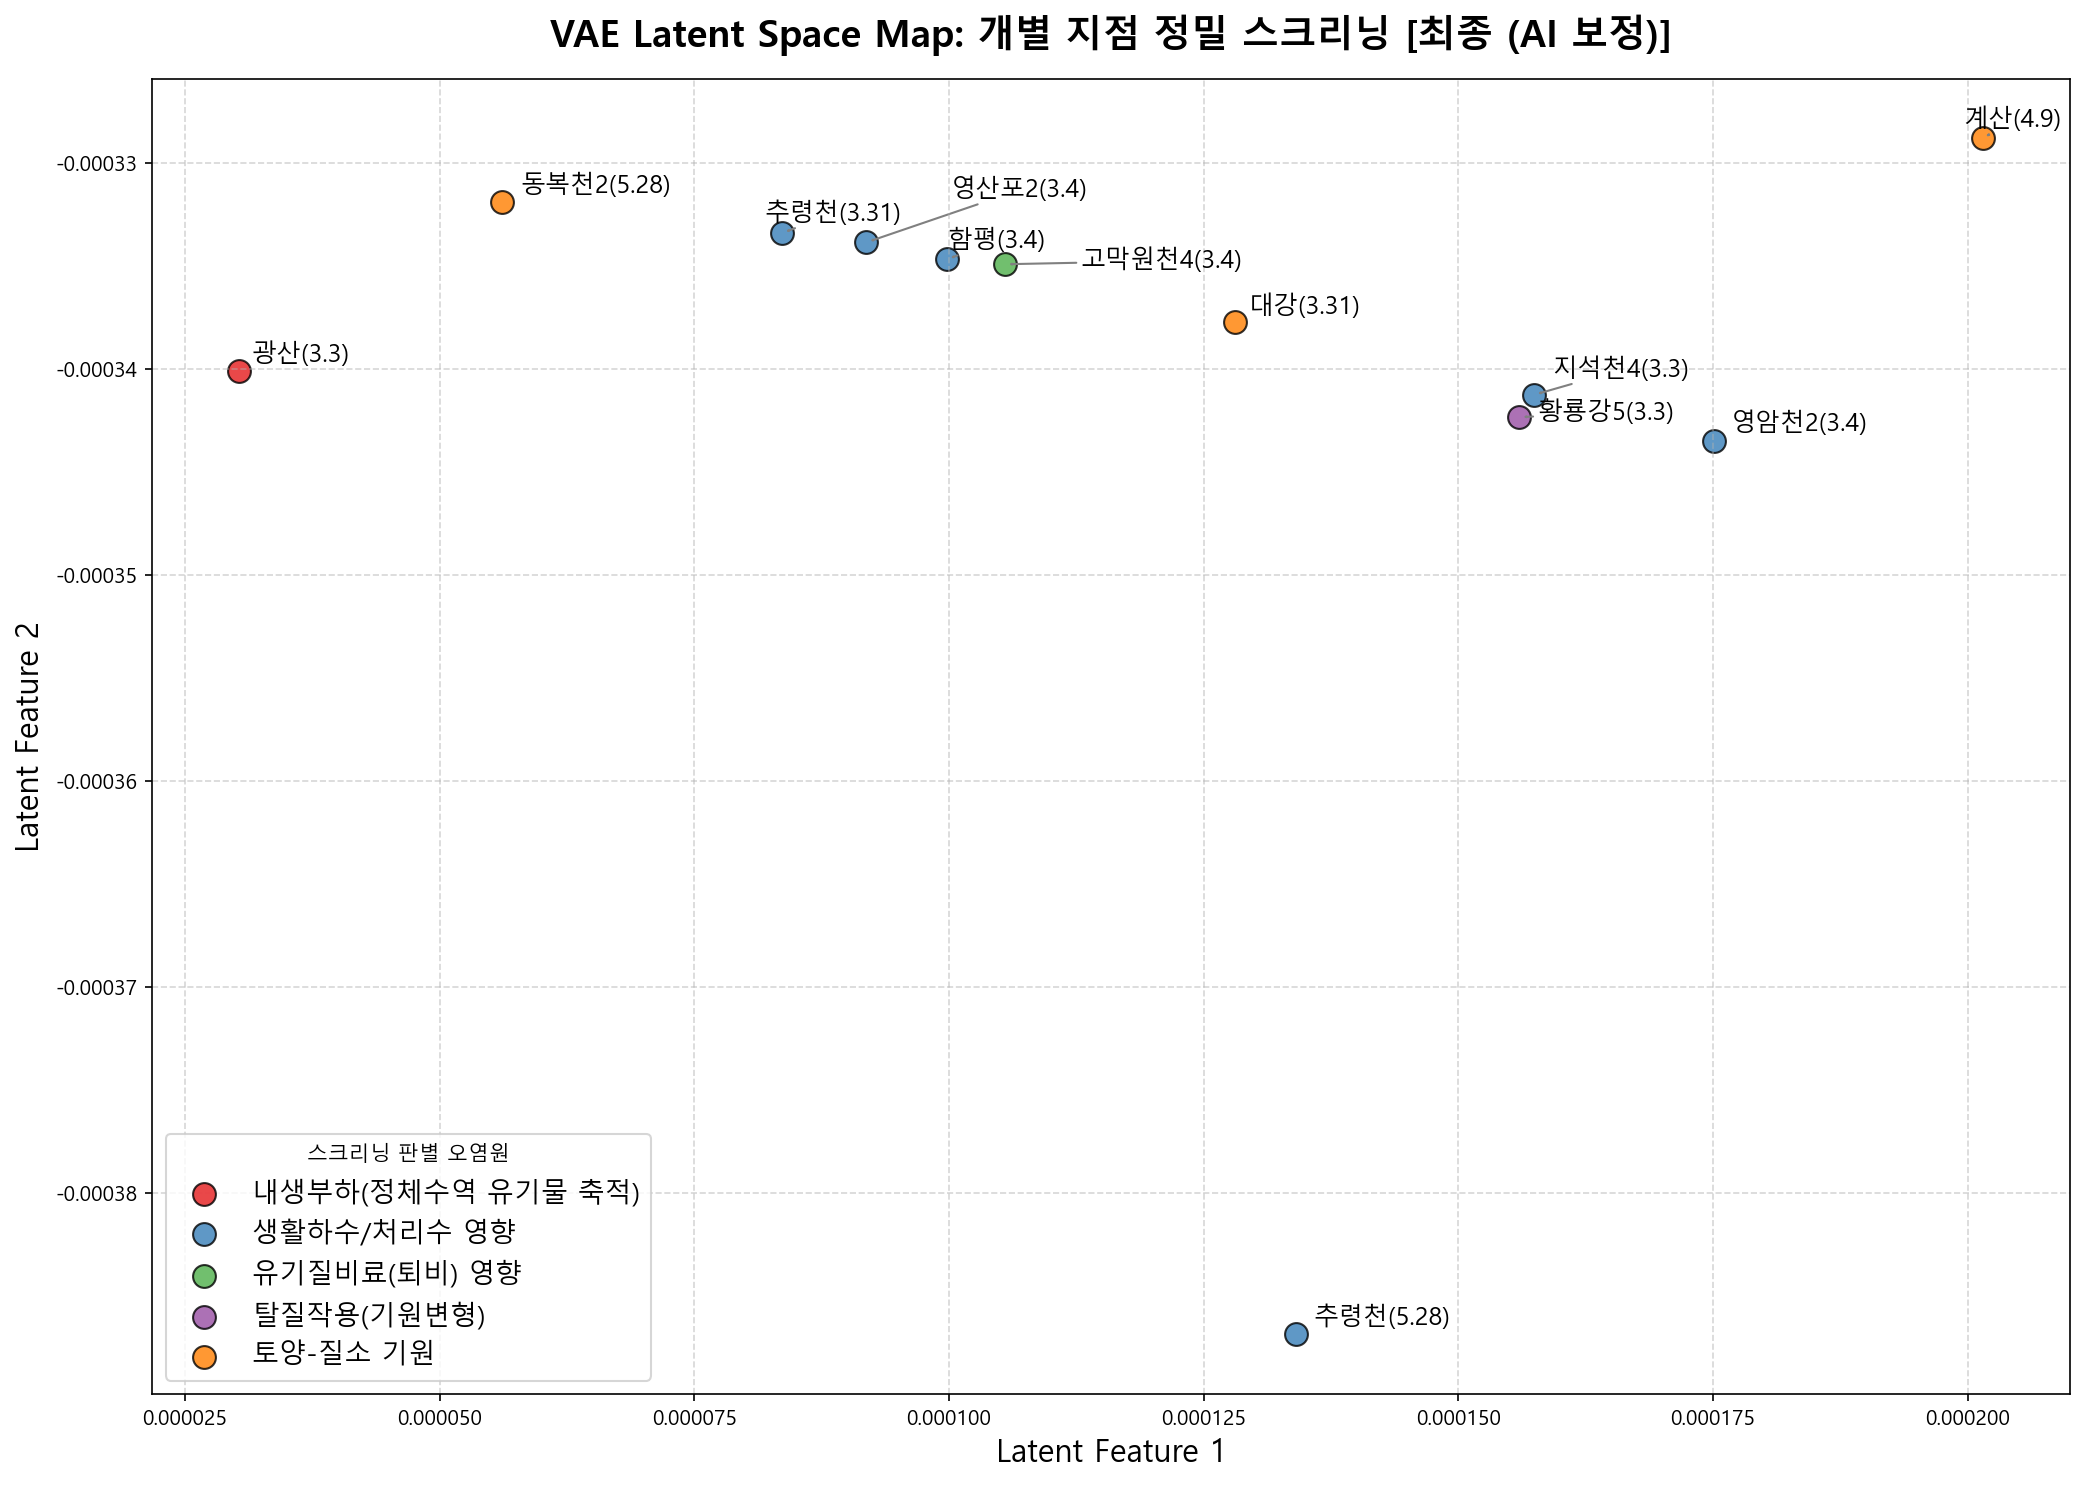

  - 개별 지점 정밀 스크리닝 지도 완료

[*] 모든 케이스에 대한 루프 프로세스가 종료되었습니다.


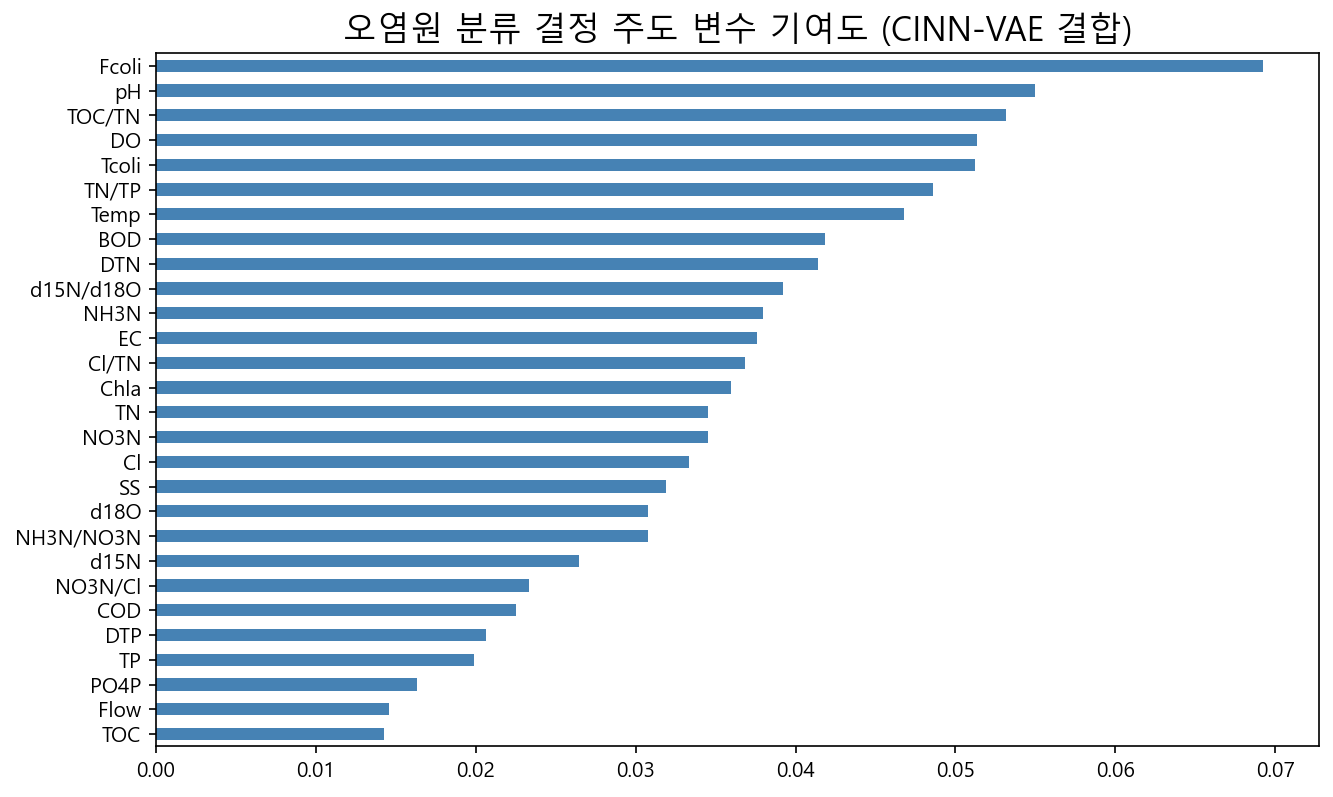

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


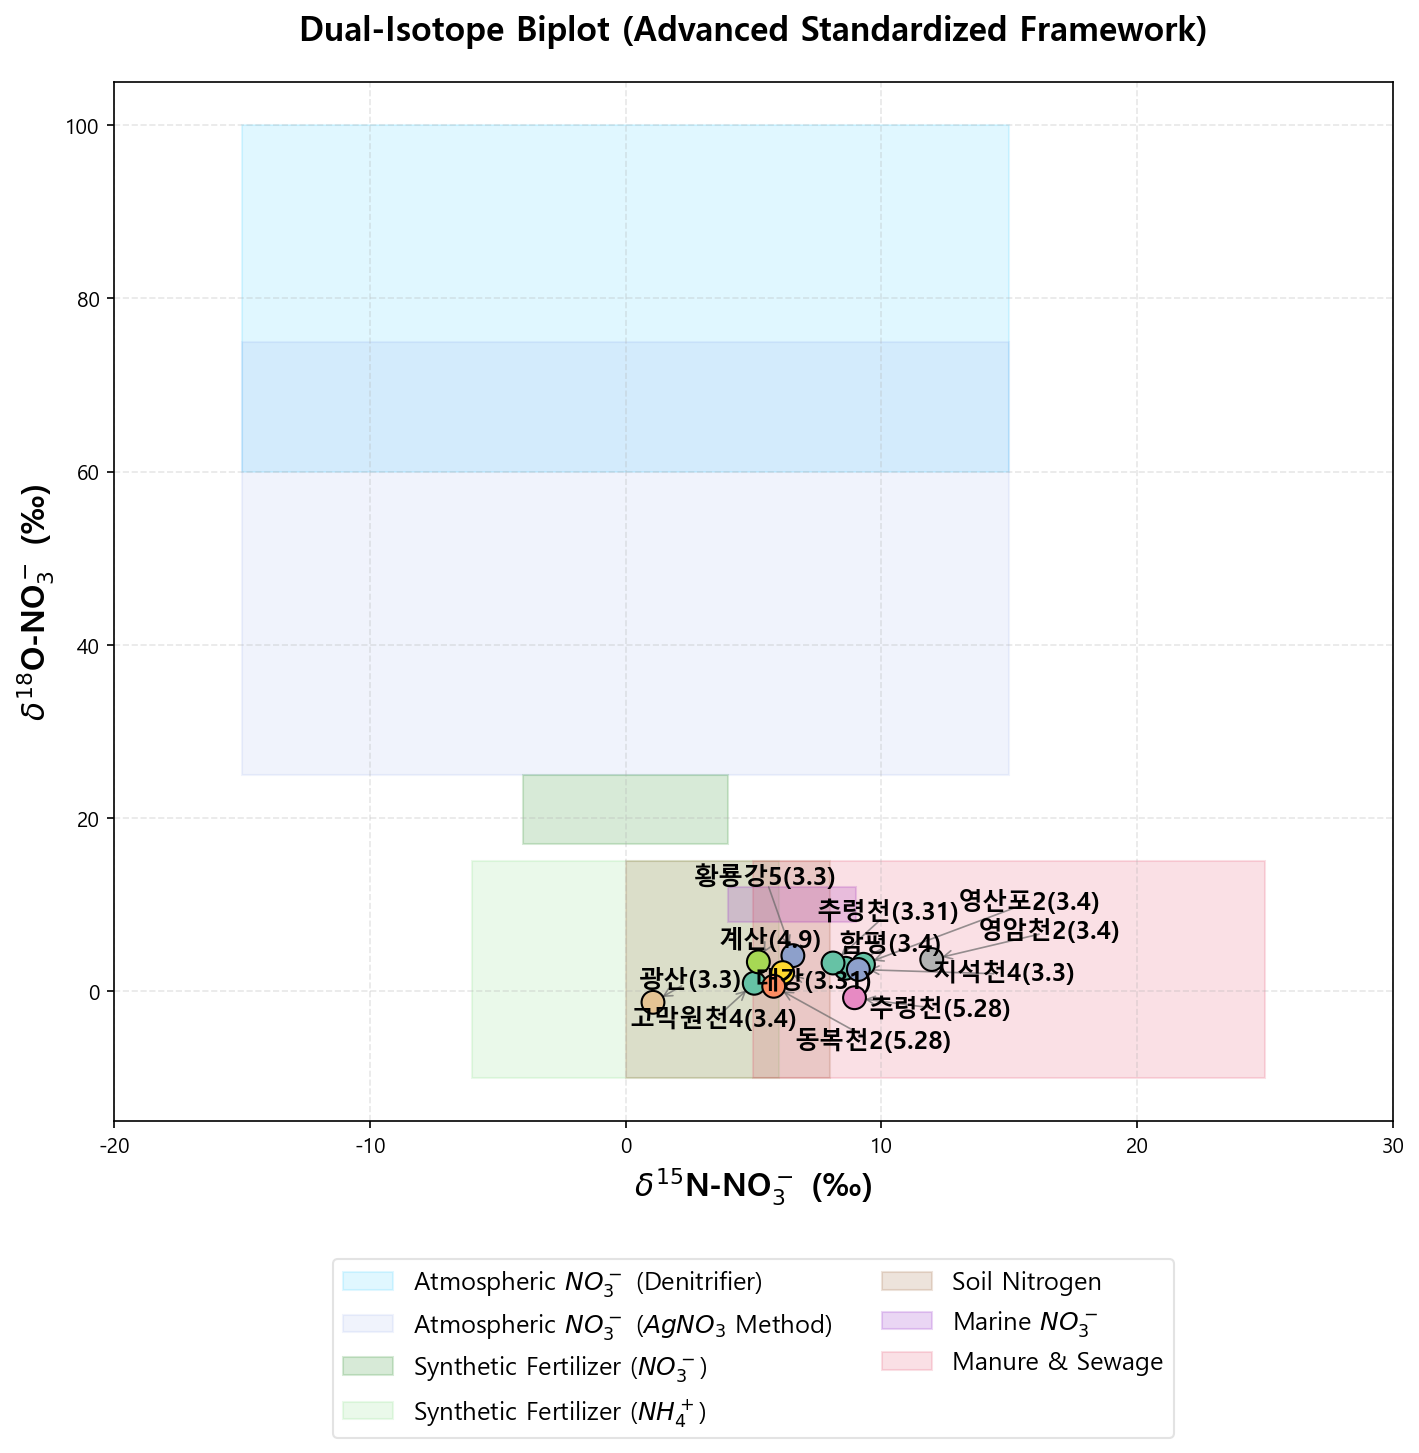

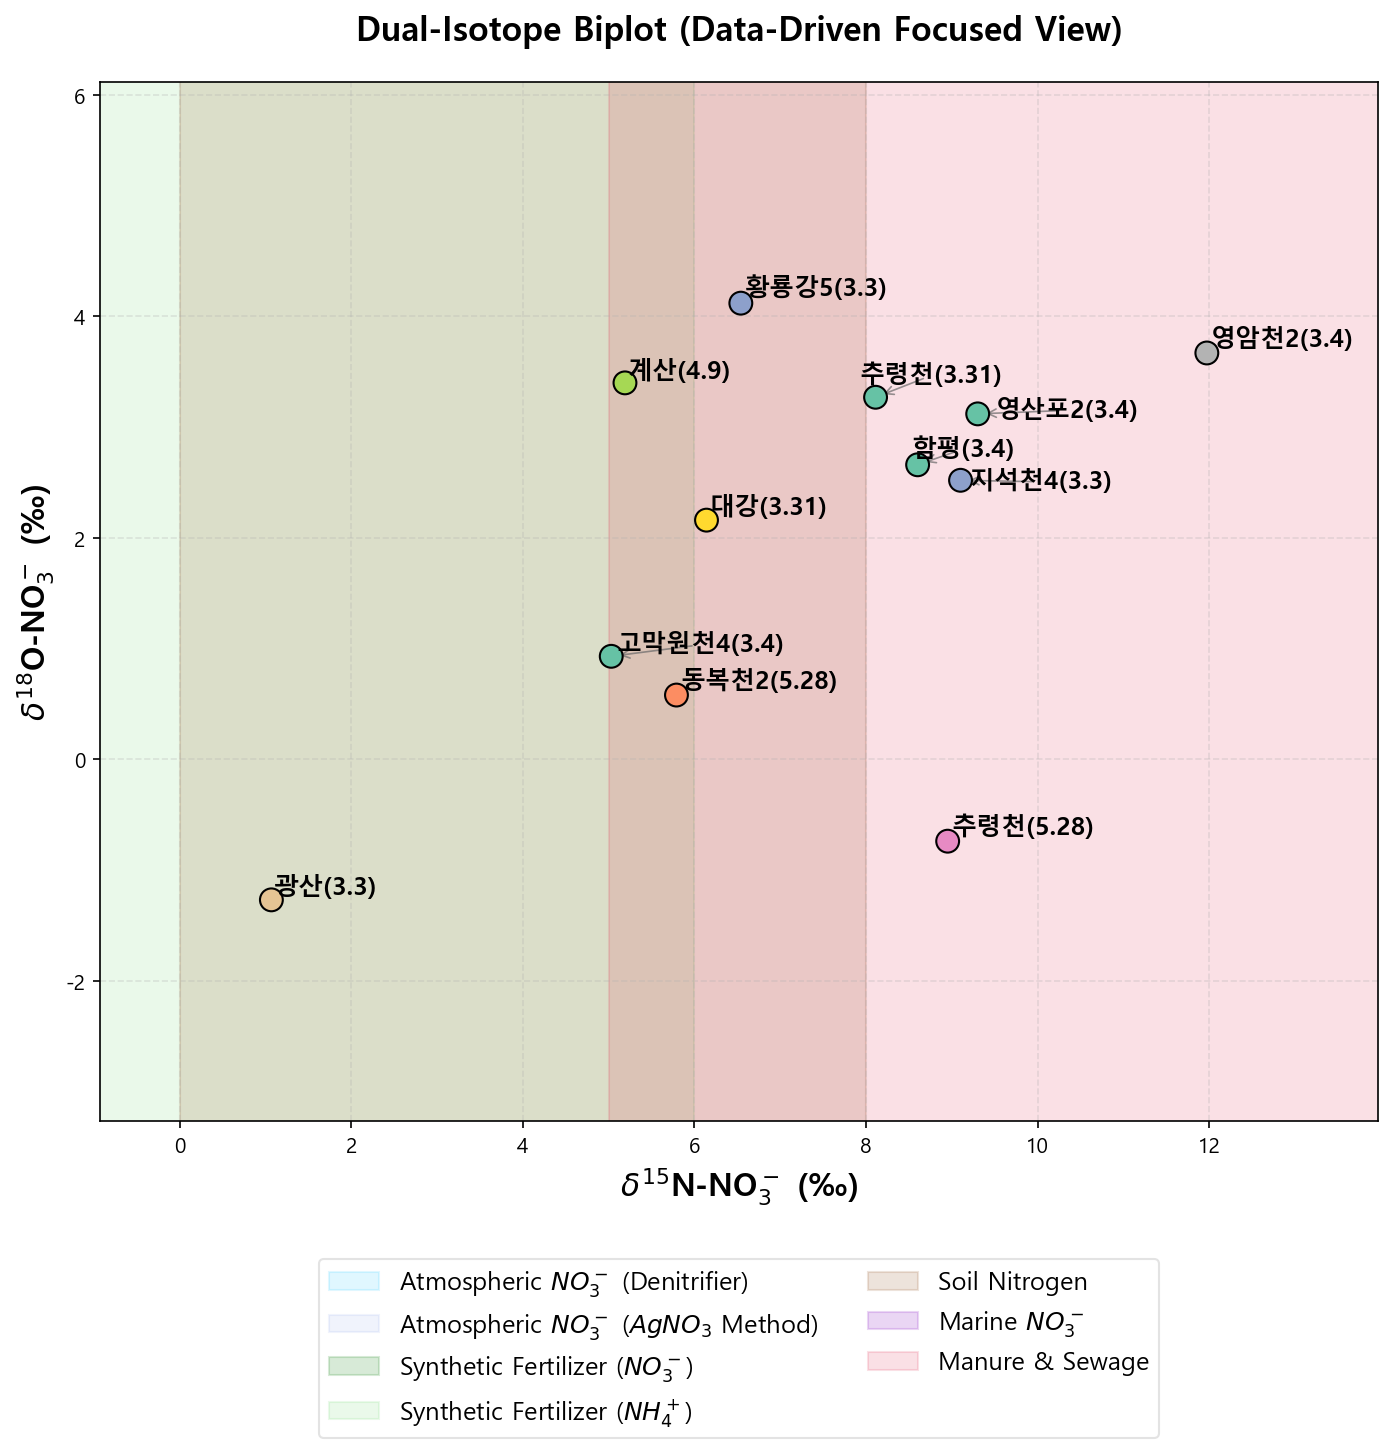

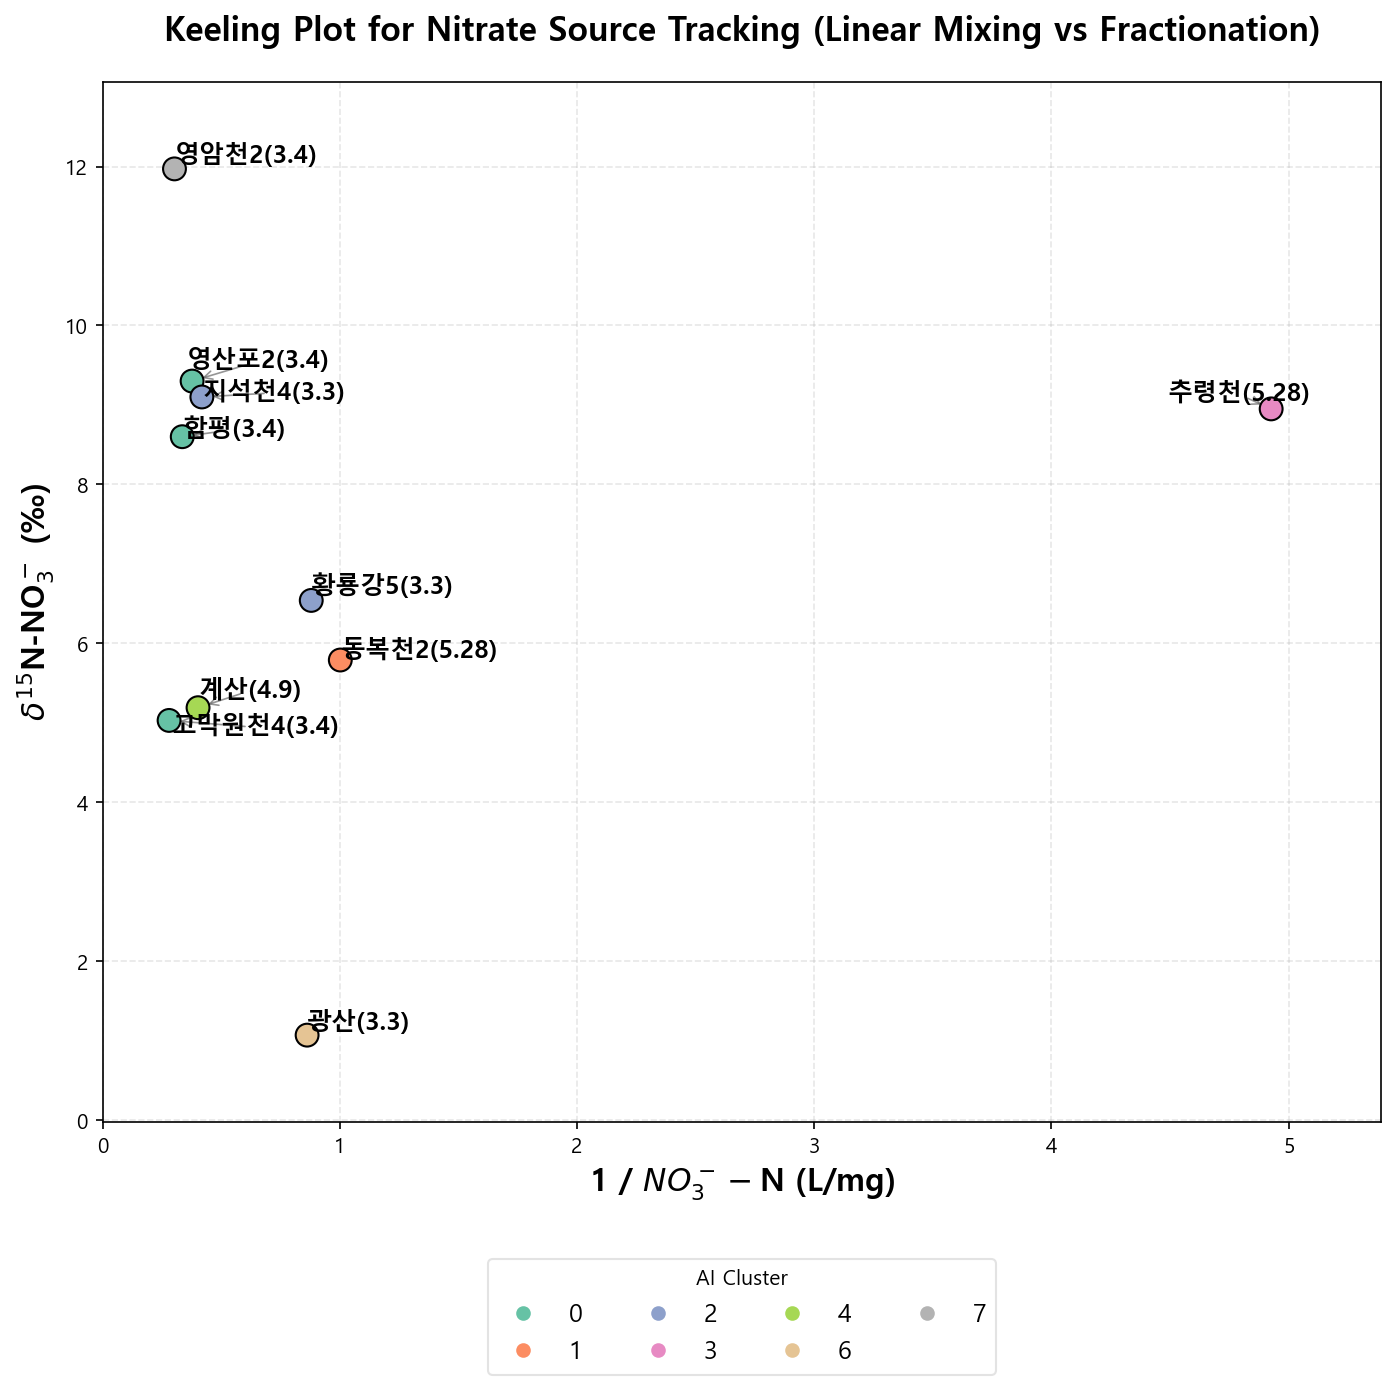

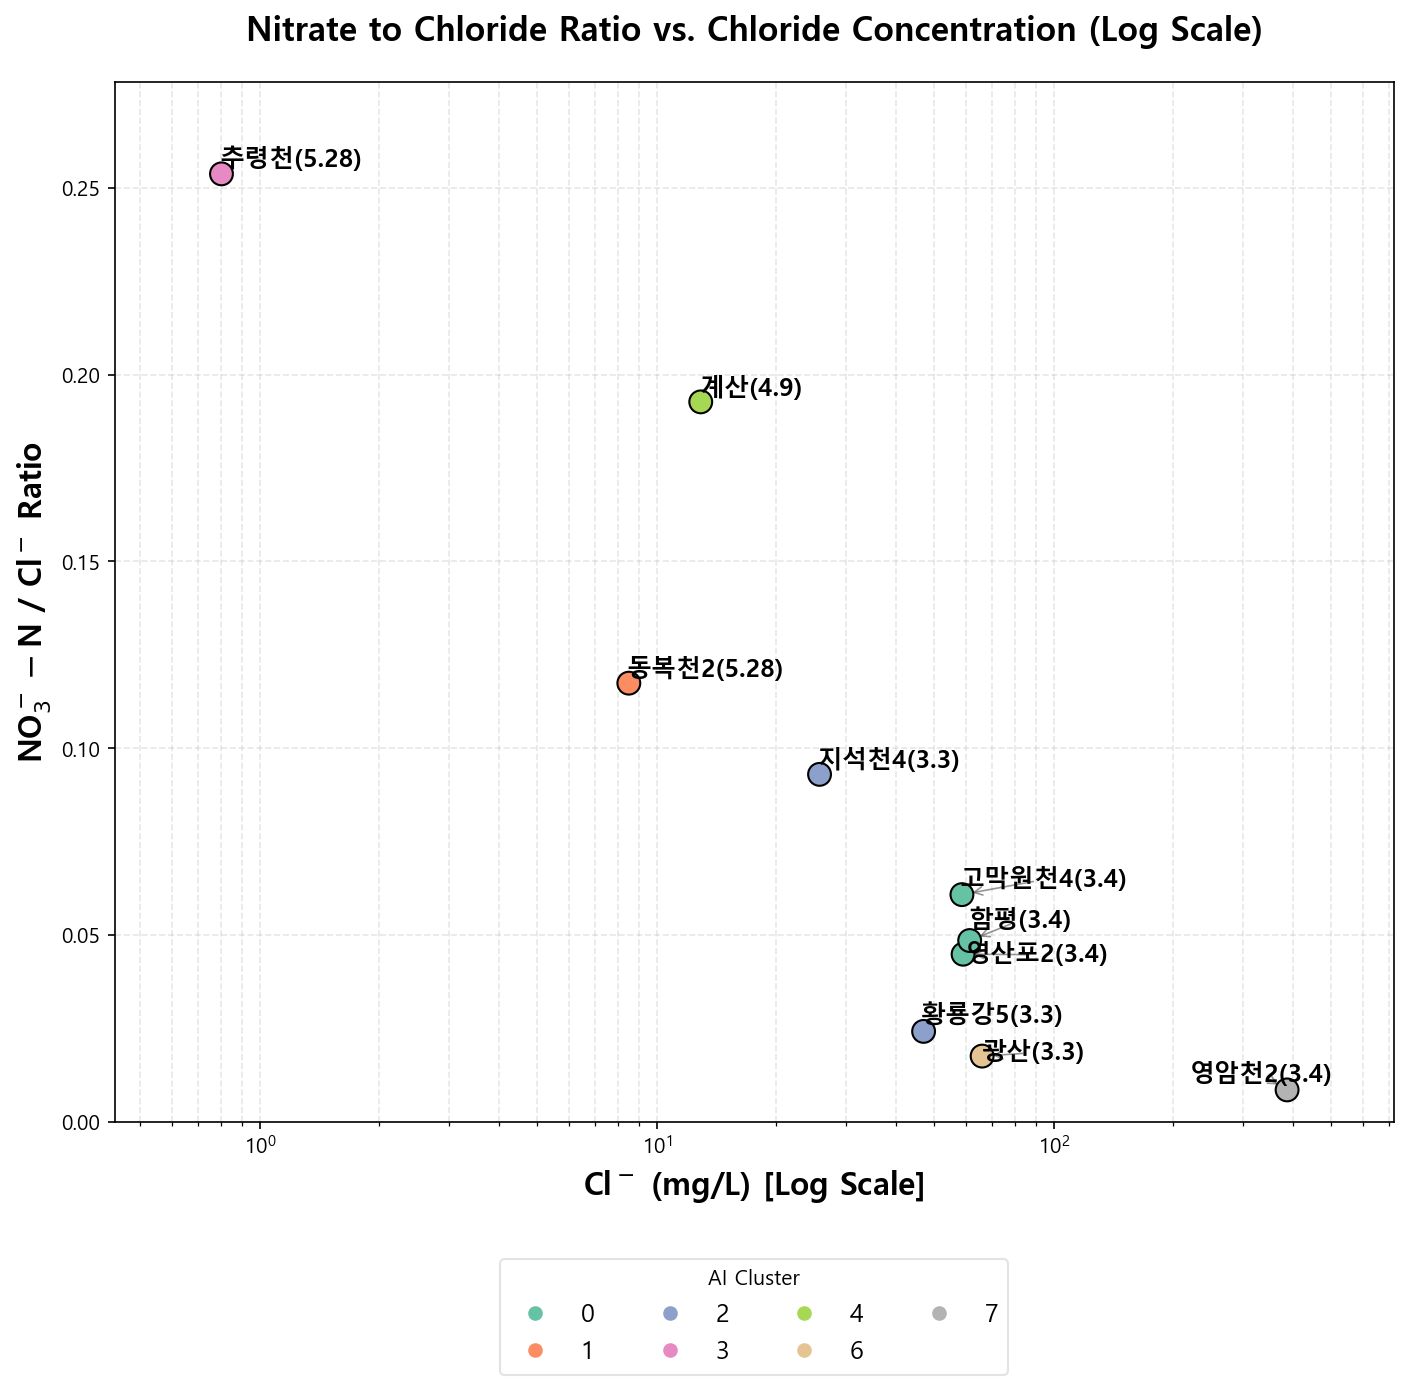

In [14]:
# ------------------------------------------------------------------------------
# 5. 시각화 및 PNG 파일 자동 저장 (XAI)
# 방법론: XAI (Explainable AI) - Decision Tree & Feature Importance (Random Forest)
# 설명: 신경망과 앙상블 군집화는 과정이 투명하지 않은 '블랙박스(Black-box)' 모델입니다. 
#       분석 결과를 연구자와 실무자가 직관적으로 이해할 수 있도록, 의사결정 나무를 통해 
#       어떤 수질 항목의 임계값(Threshold)이 오염원 분류에 결정적이었는지 시각화합니다.
# 참고문헌:
# - Breiman, L. (2001). "Random Forests." Machine Learning, 45(1), 5-32. (변수 중요도 산출의 근거)
# - Lundberg, S. M., & Lee, S. I. (2017). "A unified approach to interpreting model predictions." Advances in neural information processing systems, 30. (XAI를 통한 모델 해석력 확보)
# ------------------------------------------------------------------------------
current_time = datetime.datetime.now().strftime("%y%m%d_%H%M")
print("[*] 4단계: XAI 기반 시각화 및 결과 도출 중...")

# 공통 시각화 함수 정의
def plot_latent_space(target_col, title_suffix, filename):
    plt.figure(figsize=(14, 10))
    unique_vals = df[target_col].dropna().unique()
    colors = sns.color_palette('Set1', len(unique_vals))
    
    for i, val in enumerate(unique_vals):
        mask = df[target_col] == val
        plt.scatter(latent_data[mask, 0], latent_data[mask, 1], 
                    label=val, s=120, color=colors[i], edgecolors='k', alpha=0.8)

    texts = [plt.text(latent_data[i, 0], latent_data[i, 1], df['spot'].iloc[i], fontsize=12) for i in range(len(df))]
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

    plt.title(f"VAE Latent Space Map: {title_suffix}", fontsize=18, fontweight='bold', pad=15)
    plt.xlabel("Latent Feature 1", fontsize=15)
    plt.ylabel("Latent Feature 2", fontsize=15)
    plt.legend(title="스크리닝 판별 오염원", loc='best', fontsize=13)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{filename}_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()

# 4가지 Case별 반복 처리를 위한 리스트
cases = [
    {'c_col': 'Source_Name1', 'i_col': 'Case1_Final_Source', 'title': 'Case 1 (국내 문헌)', 'fname': 'Case1'},
    {'c_col': 'Source_Name2', 'i_col': 'Case2_Final_Source', 'title': 'Case 2 (국외 문헌)', 'fname': 'Case2'},
    {'c_col': 'Source_Name3', 'i_col': 'Case3_Final_Source', 'title': 'Case 3 (통합 문헌)', 'fname': 'Case3'},
    {'c_col': 'Source_Name',  'i_col': 'Individual_Source', 'title': '최종 (AI 보정)', 'fname': 'Final'}
]

# (1) Decision Tree & (2) Latent Space Map: Case별 반복 시각화
# (1) Decision Tree: 군집별 오염원 결정 논리를 트리 구조로 시각화
# (2) 잠재 공간 지문 지도 (Latent Space Map)
# Autoencoder로 축소한 2차원 또는 3차원 공간(여기서는 앞의 2개 차원 활용)에 투영하여, 
# 오염원 간의 공간적 거리와 분리도를 직관적으로 확인합니다.
# 원본 데이터프레임에서 개별 룰베이스 판별 결과를 가져옵니다.
for case in cases:
    c_name = case['title']
    fname = case['fname']
    c_col = case['c_col']
    i_col = case['i_col']
    
    print(f"\n>>> [{c_name}] 프로세스 시작...")

    # [방어 코드 1] 컬럼 존재 여부 확인
    if c_col not in df.columns or i_col not in df.columns:
        print(f"  [경고] 데이터프레임에 {c_col} 또는 {i_col} 컬럼이 존재하지 않아 건너뜁니다.")
        continue

    try:
        # Decision Tree 생성 및 저장
        dt_model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=2, random_state=SEED)
        
        # 결측/판정보류 데이터 방어를 위해 mask 적용
        valid_mask = (df[c_col] != "결측-판정보류") & (df[c_col].notna())
        
        if valid_mask.sum() > 5:  # 최소한 데이터가 일정 개수 이상 있을 때만 수행
            dt_model.fit(imputed_data[valid_mask], df.loc[valid_mask, c_col]) 
            
            plt.figure(figsize=(20, 10))
            plot_tree(dt_model, feature_names=features_df.columns, 
                      class_names=[str(c) for c in dt_model.classes_],
                      filled=True, rounded=True, fontsize=12)
            plt.title(f"AI 기반 수질 군집 분류 로직 트리 [{c_name}]", fontsize=18, fontweight='bold')
            plt.savefig(os.path.join(out_dir, f"01_Decision_Tree_{fname}_{current_time}.png"), dpi=300, bbox_inches='tight')
            plt.show()
            plt.close() # [메모리 방어] 사용한 그림 객체 닫기
            print(f"  - Decision Tree 시각화 완료")
        else:
            print(f"  [안내] {c_name}의 유효 데이터 수가 부족하여 Decision Tree를 생략합니다. (유효수: {valid_mask.sum()})")
        
        # Latent Space Map 생성 및 저장
        # [방어 코드 2] plot_latent_space 함수 내부에서 에러가 나는 것을 방지하기 위해 try-except 세분화
        try:
            plot_latent_space(c_col, f'군집 대표 오염원 [{c_name}]', f'02_Latent_Space_Cluster_{fname}')
            print(f"  - 군집 대표 오염원 지도 완료")
        except Exception as e:
            print(f"  [오류] 군집 대표 오염원 지도 생성 중 에러 발생 ({fname}): {e}")
            
        try:
            plot_latent_space(i_col, f'개별 지점 정밀 스크리닝 [{c_name}]', f'03_Latent_Space_Individual_{fname}')
            print(f"  - 개별 지점 정밀 스크리닝 지도 완료")
        except Exception as e:
            print(f"  [오류] 개별 지점 정밀 스크리닝 지도 생성 중 에러 발생 ({fname}): {e}")
            
        plt.close('all') # 모든 잔여 Matplotlib 피규어 닫기 (메모리 누수 방지)

    except Exception as main_e:
        # 루프 전체가 터지는 것을 막고 에러 로그를 출력 후 다음 케이스로 이동
        print(f"\n [Fatal Error] {c_name} 처리 중 치명적 오류 발생:")
        traceback.print_exc()
        print(f" {c_name} 프로세스를 건너뛰고 다음 케이스로 진행합니다.\n")
        continue

print("\n=============================================")
print("[*] 모든 케이스에 대한 루프 프로세스가 종료되었습니다.")
print("=============================================")

# (3) Random Forest 변수 중요도 (군집 구조 기반이므로 1번만 구동)
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=SEED).fit(imputed_data, df['Cluster'])
importances = pd.Series(rf.feature_importances_, index=features_df.columns).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title("오염원 분류 결정 주도 변수 기여도 (CINN-VAE 결합)", fontsize=16)
plt.savefig(os.path.join(out_dir, f"04_Feature_Importance_{current_time}.png"), dpi=300, bbox_inches='tight')
plt.show()

# (4) Dual-Isotope biplot (동위원소 산출값이므로 1번만 구동)
# ==============================================================================
# [최신화 영역] 3대 표준 문헌 기반 오염원 7대 범주 경계 설정
# References:
#   1) Kendall, C., Elliott, E. M., & Wankel, S. D. (2007). Tracing anthropogenic inputs of nitrogen to ecosystems. Stable isotopes in ecology and environmental science, 375-449.
#   2) Xue, D., Botte, J., De Baets, B., Accoe, F., Nestler, A., Taylor, P., ... & Boeckx, P. (2009). Present limitations and future prospects of stable isotope methods for nitrate source identification in surface-and groundwater. Water research, 43(5), 1159-1170.
#   3) International Atomic Energy Commission. (2013). Application of Isotope Techniques for Assessing Nutrient Dynamics in River Basins. IAEA.
#
# Rectangle 인자 구조: (x_min, y_min), width(x_max - x_min), height(y_max - y_min)
# ==============================================================================
# (4-1) 모든 오염원 영역이 드러나도록 그리기
fig, ax = plt.subplots(figsize=(11, 9))  # 범례 공간 확보를 위해 가로/세로 크기 미세 확장

# 1. Atmospheric NO3- (by bacterial denitrification): d15N(-15~15), d18O(60~100)
ax.add_patch(plt.Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', 
                           label='Atmospheric $NO_3^-$ (Denitrifier)'))

# 2. Atmospheric NO3- (by ion exchange / AgNO3): d15N(-15~15), d18O(25~75)
ax.add_patch(plt.Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', 
                           label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)'))

# 3. Synthetic Fertilizer (NO3- Form): d15N(-4~4), d18O(17~25)
ax.add_patch(plt.Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', 
                           label='Synthetic Fertilizer ($NO_3^-$)'))

# 4. Synthetic Fertilizer (NH4+ Form): d15N(-6~6), d18O(-10~15)
ax.add_patch(plt.Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', 
                           label='Synthetic Fertilizer ($NH_4^+$)'))

# 5. Soil Nitrogen (토양 유기태 질소): d15N(0~8), d18O(-10~15)
ax.add_patch(plt.Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', 
                           label='Soil Nitrogen'))

# 6. Marine NO3- (해수 기원 질산염): d15N(4~9), d18O(8~12)
ax.add_patch(plt.Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', 
                           label='Marine $NO_3^-$'))

# 7. Manure & Sewage (축산분뇨 및 생활하수): d15N(5~25), d18O(-10~15)
ax.add_patch(plt.Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', 
                           label='Manure & Sewage'))

# ==============================================================================

# ==============================================================================
# [방어막 보완 영역] 시각화 전용 로컬 데이터프레임 생성 및 결측치 전처리
# 원본 데이터프레임(df)의 구조를 망가뜨리지 않고, 그래프 플로팅에 필요한 핵심 변수인
# 'd15N'과 'd18O'에 결측치(NaN)가 포함된 행만 안전하게 필터링합니다.
# 이를 통해 후속 군집 색상 매핑(Cluster) 및 지점명(spot) 매핑의 인덱스 불일치 오류를 방지합니다.
# ==============================================================================
plot_df = df.dropna(subset=['d15N', 'd18O']).copy()

# 만약 결측치를 제외한 유효 데이터가 존재할 때만 그래프 작성을 수행하도록 제어
if not plot_df.empty:

    # 데이터 플로팅 (원본 df 대신 결측치가 제거된 plot_df 적용)
    scatter = ax.scatter(plot_df['d15N'], plot_df['d18O'], c=plot_df['Cluster'], cmap='Set2', s=120, edgecolors='k', zorder=4)
    
    # 지점 라벨링 생성 루틴 수정 (plot_df 기반으로 일치화하여 NaN 좌표에 텍스트가 찍히는 오류 차단)
    texts = [ax.text(plot_df['d15N'].iloc[i], plot_df['d18O'].iloc[i], str(txt), fontsize=12, fontweight='semibold', zorder=5) 
             for i, txt in enumerate(plot_df['spot'])]

    # 라벨 중첩 방지 조절 (유효한 좌표값들만 전달되므로 안정적으로 구동됨)
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8, alpha=0.7, shrinkA=5, shrinkB=5), lim=50)

    # 축 라벨 및 그래프 디자인 고도화
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')

    # [개선] 7대 범주 확장에 따른 범례 가독성 확보 (2열 배열 및 그래프 하단 외부 배치)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=12, 
              frameon=True, shadow=False, ncol=2, facecolor='white', edgecolor='gainsboro')

    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Advanced Standardized Framework)", fontsize=16, fontweight='bold', pad=20)

    # [수정 영역] 7대 범주(Y축 최대 100)가 온전히 표출되도록 경계 최적화
    ax.set_xlim(-20, 30)
    ax.set_ylim(-15, 105)

    # 이미지 저장 및 출력 (bbox_inches='tight' 필수: 하단 외부 범례가 잘리지 않도록 함)
    fig.savefig(os.path.join(out_dir, f"05_1_Dual-Isotope_biplot_Standard_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print("[경고] d15N 또는 d18O의 유효한 데이터가 데이터셋에 존재하지 않아 Dual-Isotope Biplot을 생성하지 못했습니다.")

# (4-2) 동적 축 범위 설정(데이터 자세하게 들여다보기)
fig, ax = plt.subplots(figsize=(11, 9))  # 범례 공간 확보를 위해 가로/세로 크기 미세 확장

# 1. Atmospheric NO3- (by bacterial denitrification): d15N(-15~15), d18O(60~100)
ax.add_patch(plt.Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', 
                           label='Atmospheric $NO_3^-$ (Denitrifier)'))

# 2. Atmospheric NO3- (by ion exchange / AgNO3): d15N(-15~15), d18O(25~75)
ax.add_patch(plt.Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', 
                           label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)'))

# 3. Synthetic Fertilizer (NO3- Form): d15N(-4~4), d18O(17~25)
ax.add_patch(plt.Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', 
                           label='Synthetic Fertilizer ($NO_3^-$)'))

# 4. Synthetic Fertilizer (NH4+ Form): d15N(-6~6), d18O(-10~15)
ax.add_patch(plt.Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', 
                           label='Synthetic Fertilizer ($NH_4^+$)'))

# 5. Soil Nitrogen (토양 유기태 질소): d15N(0~8), d18O(-10~15)
ax.add_patch(plt.Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', 
                           label='Soil Nitrogen'))

# 6. Marine NO3- (해수 기원 질산염): d15N(4~9), d18O(8~12)
ax.add_patch(plt.Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', 
                           label='Marine $NO_3^-$'))

# 7. Manure & Sewage (축산분뇨 및 생활하수): d15N(5~25), d18O(-10~15)
ax.add_patch(plt.Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', 
                           label='Manure & Sewage'))

# ==============================================================================

# ==============================================================================
# [방어막 보완 영역] 시각화 전용 로컬 데이터프레임 생성 및 결측치 전처리
# 원본 데이터프레임(df)의 구조를 망가뜨리지 않고, 그래프 플로팅에 필요한 핵심 변수인
# 'd15N'과 'd18O'에 결측치(NaN)가 포함된 행만 안전하게 필터링합니다.
# 이를 통해 후속 군집 색상 매핑(Cluster) 및 지점명(spot) 매핑의 인덱스 불일치 오류를 방지합니다.
# ==============================================================================
plot_df = df.dropna(subset=['d15N', 'd18O']).copy()

# 만약 결측치를 제외한 유효 데이터가 존재할 때만 그래프 작성을 수행하도록 제어
if not plot_df.empty:

    # ==========================================================================
    # [핵심 고도화] 조사 지점 실제 데이터 맞춤형 동적 마진(Padding) 연산
    x_min, x_max = plot_df['d15N'].min(), plot_df['d15N'].max()
    y_min, y_max = plot_df['d18O'].min(), plot_df['d18O'].max()

    # 데이터 분포 폭의 15% 만큼 여백(Buffer) 산정 (단일 지점일 경우를 대비해 최소 여백 2.0 보장)
    x_buffer = max((x_max - x_min) * 0.15, 2.0) if x_max != x_min else 3.0
    y_buffer = max((y_max - y_min) * 0.15, 2.0) if y_max != y_min else 3.0

    # 최종 동적 축 범위 지정
    ax.set_xlim(x_min - x_buffer, x_max + x_buffer)
    ax.set_ylim(y_min - y_buffer, y_max + y_buffer)
    # ==========================================================================

    # 데이터 플로팅 (원본 df 대신 결측치가 제거된 plot_df 적용)
    scatter = ax.scatter(plot_df['d15N'], plot_df['d18O'], c=plot_df['Cluster'], cmap='Set2', s=120, edgecolors='k', zorder=4)
    
    # 지점 라벨링 생성 루틴 수정 (plot_df 기반으로 일치화하여 NaN 좌표에 텍스트가 찍히는 오류 차단)
    texts = [ax.text(plot_df['d15N'].iloc[i], plot_df['d18O'].iloc[i], str(txt), 
                     fontsize=12, fontweight='semibold', zorder=5) 
             for i, txt in enumerate(plot_df['spot'])]

    # 라벨 중첩 방지 조절 (화살표 길이를 짧고 정밀하게 제어하기 위한 매개변수 튜닝)
    adjust_text(texts, 
                arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8, alpha=0.7, shrinkA=4, shrinkB=4), 
                lim=40)

    # 축 라벨 및 그래프 디자인 고도화
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')

    # [개선] 7대 범주 확장에 따른 범례 가독성 확보 (2열 배열 및 그래프 하단 외부 배치)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=12, 
              frameon=True, shadow=False, ncol=2, facecolor='white', edgecolor='gainsboro')

    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Data-Driven Focused View)", fontsize=16, fontweight='bold', pad=20)

    # 이미지 저장 및 출력 (bbox_inches='tight' 필수: 하단 외부 범례가 잘리지 않도록 함)
    fig.savefig(os.path.join(out_dir, f"05_2_Dual-Isotope_biplot_Dynamic_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print("[경고] d15N 또는 d18O의 유효한 데이터가 데이터셋에 존재하지 않아 Dual-Isotope Biplot을 생성하지 못했습니다.")    

# (5) Keeling plot: d15N (y축) vs 1/NO3N (x축) (오염원 혼합 및 정량적 거동 해석)
fig, ax = plt.subplots(figsize=(11, 9))  # 기존 프레임워크의 범례 및 시각적 일관성을 위해 동일 크기 유지

# ==============================================================================
# [학술적 배경 및 오염원 해석 원리 - 주석 상세 기술]
# 본 산점도는 지화학(Geochemistry) 분야에서 전통적으로 널리 쓰이는 'Keeling Plot' 분석법입니다.
# 수계 내 질산성질소(NO3-N)의 농도 변화와 질소 안정동위원소비(d15N)의 관계를 선형화하여 
# 다음과 같은 두 가지 핵심 환경 프로세스를 정량적으로 판별할 수 있습니다.
#
# 1) 이성분 혼합 모형 (Binary Mixing Processes):
#    만약 데이터 포인트들이 이 그래프 상에서 직선(Linear Trend)을 그리며 정렬된다면, 
#    이는 수계 내에서 기원이 다른 '두 개의 독립된 오염원'이 단순히 물리적으로 혼합(Dilution 또는 Mixing)
#    되고 있음을 의미합니다. 이때 회귀직선의 y절편(1/NO3N -> 0, 즉 농도가 무한대인 시점) 값은 
#    외부에서 유입된 주 오염원(End-member)의 고유한 d15N 동위원소 초깃값을 나타냅니다.
#
# 2) 생물학적 탈질 작용 (Denitrification):
#    만약 데이터가 직선을 따르지 않고, NO3N 농도가 감소함에 따라(즉, 1/NO3N 값이 커짐에 따라) 
#    d15N 값이 지수함수적으로 상승하는 형태를 보인다면, 이는 단순 혼합이 아니라 
#    미생물에 의한 '탈질 작용(Denitrification)'이 강하게 일어나 동위원소 분별 효과(Fractionation)가 
#    발생했음을 지화학적으로 증명합니다.
#
# [검증 완료] References (Google Scholar 검색 최적화 표준 서지 정보):
#   1) Keeling, C. D. (1958). The concentration and isotopic abundances of atmospheric carbon dioxide in rural areas. Geochimica et cosmochimica acta, 13(4), 322-334.
#   2) Kendall, C. (1998). Tracing nitrogen sources and cycling in catchments. In Isotope tracers in catchment hydrology (pp. 519-576). Elsevier.
#   3) Xue, D., Botte, J., De Baets, B., Accoe, F., Nestler, A., Taylor, P., ... & Boeckx, P. (2009). Present limitations and future prospects of stable isotope methods for nitrate source identification in surface-and groundwater. Water research, 43(5), 1159-1170.
# ==============================================================================

# ==============================================================================
# [방어막 영역] 결측치 데이터 및 분모 0 (ZeroDivisionError) 발생 행 제거
# 원본 df의 무결성을 지키기 위해 .copy()를 사용하며, x축의 분모가 되는 NO3N이 
# 결측치이거나 정밀도가 낮아 0(또는 음수)으로 측정된 행을 완벽히 필터링합니다.
# ==============================================================================
keeling_df = df.dropna(subset=['d15N', 'NO3N']).copy()
keeling_df = keeling_df[keeling_df['NO3N'] > 0]  # 분모가 0이 되는 원천적 오류 방지

if not keeling_df.empty:
    # 1/NO3N 역수(Inverse) 컬럼 생성
    keeling_df['1/NO3N'] = 1.0 / keeling_df['NO3N']

    # 데이터 플로팅 (기존 프레임워크의 군집 색상, 크기, 테두리 스타일 일치화)
    scatter = ax.scatter(keeling_df['1/NO3N'], keeling_df['d15N'], 
                         c=keeling_df['Cluster'], cmap='Set2', s=120, edgecolors='k', zorder=4)
    
    # 지점 라벨링 생성 루틴 (결측치가 제거된 keeling_df 인덱스에 맞추어 1:1 매핑)
    texts = [ax.text(keeling_df['1/NO3N'].iloc[i], keeling_df['d15N'].iloc[i], str(txt), 
                     fontsize=12, fontweight='semibold', zorder=5) 
             for i, txt in enumerate(keeling_df['spot'])]

    # 라벨 중첩 방지 조절 (adjust_text 라이브러리 연계 유지)
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8, alpha=0.7, shrinkA=5, shrinkB=5), lim=50)

    # 축 라벨 및 그래프 디자인 고도화 (수학적 표현식 적용)
    ax.set_xlabel(r'1 / $NO_3^--$N (L/mg)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')

    # 군집(Cluster) 구분을 위한 범례 표시 (기존 프레임워크 디자인과 톤앤매너 매치)
    legend_elements = ax.legend(*scatter.legend_elements(), loc='upper center', bbox_to_anchor=(0.5, -0.12), 
                                fontsize=12, frameon=True, shadow=False, ncol=4, facecolor='white', edgecolor='gainsboro', title="AI Cluster")

    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Keeling Plot for Nitrate Source Tracking (Linear Mixing vs Fractionation)", fontsize=16, fontweight='bold', pad=20)

    # 역수 플롯의 특성상 데이터의 가독성을 높이기 위해 여백을 고려한 동적 축 범위 설정
    x_margin = (keeling_df['1/NO3N'].max() - keeling_df['1/NO3N'].min()) * 0.1 if len(keeling_df) > 1 else 0.5
    y_margin = (keeling_df['d15N'].max() - keeling_df['d15N'].min()) * 0.1 if len(keeling_df) > 1 else 2.0
    
    ax.set_xlim(max(0, keeling_df['1/NO3N'].min() - x_margin), keeling_df['1/NO3N'].max() + x_margin)
    ax.set_ylim(keeling_df['d15N'].min() - y_margin, keeling_df['d15N'].max() + y_margin)

    # 이미지 저장 및 출력 (기존 파일명 형식 및 bbox_inches 규칙 준수)
    fig.savefig(os.path.join(out_dir, f"06_Keeling_plot_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print("[경고] d15N 또는 NO3N의 유효 관측치(>0)가 부족하여 Keeling Plot을 생성하지 못했습니다.")  

# (6) Chemical Tracer Plot: NO3N/Cl (y축) vs log(Cl) (x축) (보존성 추적자 기반 오염원 거동 해석 - 로그스케일 고도화 버전)
fig, ax = plt.subplots(figsize=(11, 9))  # 프레임워크의 시각적 일관성 및 범례 가독성을 위해 동일 크기 유지

# ==============================================================================
# [학술적 배경 및 오염원 해석 원리 - 주석 상세 기술]
# 본 산점도는 동위원소 분석 결과와 수질 화학 인자를 연계하여 오염원의 기원과 수동적/능동적 거동을 
# 판별하는 데 가장 신뢰성 높은 '화학적 추적자 비(Tracer Ratio)' 분석 기법입니다.
# 
# 1) 보존성 추적자(Conservative Tracer)로서의 염소이온(Cl-):
#    Cl-은 수계 내에서 미생물 흡수, 휘발, 침전 등의 생물화학적 반응에 의해 거의 소모되지 않고, 
#    오직 물의 흐름에 따른 '물리적 희석 및 혼합(Dilution & Mixing)'에 의해서만 농도가 변화합니다.
# 
# 2) 오염원별 End-member 판별 원리:
#    - 축산분뇨 및 생활하수 기원 (Manure & Sewage): 고농도의 질소와 함께 식생활/사료 기원의 고농도 Cl-이 
#      동시 유입되므로, x축(Cl-)과 y축(NO3N/Cl)이 모두 높은 영역 또는 독자적인 선형 궤적을 형성합니다.
#    - 화학비료 기원 (Synthetic Fertilizer): 농경지 질소 비료는 Cl- 함량이 상대적으로 매우 낮기 때문에, 
#      x축(Cl-) 농도는 낮고 y축(NO3N/Cl) 비율은 극단적으로 높은 좌상단 영역에 플로팅됩니다.
#    - 배경 지하수/자연수 (Background Water): Cl-과 NO3-N 농도가 모두 낮아 좌하단 영역에 위치합니다.
# 
# 3) 생물학적 탈질 작용(Denitrification)의 진단:
#    특정 지점에서 시간이 지남에 따라 Cl- 농도(x축)는 일정한 수준을 유지하는데, NO3N/Cl 비율(y축)만 
#    수직으로 급격히 감소하는 경향(Vertical Downward Trend)을 보인다면, 이는 오염원의 변경이 아니라 
#    수계 내에서 질산염이 '탈질 작용'에 의해 생물학적으로 소모(자연 정화)되었음을 완벽하게 입증합니다.
#
# [* 핵심 피칭 포인트: 왜 로그 스케일(Log Scale)인가?]
# 1) 데이터 압축(Compression) 해소 및 저농도 구간 해상도 극대화:
#    본 유역 내 '무안2' 지점과 같이 해수 침투 또는 특이 폐수의 영향으로 Cl- 농도가 극단적으로 높은
#    이상치(Outlier, >1,000 mg/L)가 존재할 경우, 선형 축에서는 하수와 분뇨가 분리되어야 할 
#    핵심 저농도 구간(0 ~ 150 mg/L)이 좌측 벽면에 압축되어 식별이 불가능해집니다.
#    X축을 로그 스케일로 변환함으로써, 고농도 이상치를 한 화면에 표출하면서도 저농도 구간을 기하학적으로
#    확장(Decompression)하여 미세한 거동 차이를 명확하게 시각화할 수 있습니다.
# 
# 2) 보존성 추적자(Cl-) 기반 하수(Sewage)와 분뇨(Manure)의 타당한 경계선 분리 원리:
#    - 가축 분뇨(Manure): 암모니아성 질소의 극단적 유입 후 질산화가 진행되므로, Cl- 농도는 상대적으로 
#      낮은 대역(10 ~ 40 mg/L)에 머물면서 NO3N/Cl 비율이 0.12 이상으로 급격히 수직 상승하는 거동을 보입니다.
#    - 생활 하수(Sewage): 인간 활동으로 인해 Cl-과 질산염이 동시에 일정 비율로 유입되므로, Cl- 농도가 
#      중-고농도 대역(40 ~ 150 mg/L)을 형성하며 NO3N/Cl 비율이 0.03 ~ 0.08 박스권 내에 수렴하는 경향을 보입니다.
#
# 3) 생물학적 탈질 작용(Denitrification)의 진단:
#    특정 지점에서 시간이 지남에 따라 Cl- 농도(x축)는 일정한 수준을 유지하는데, NO3N/Cl 비율(y축)만 
#    수직으로 급격히 감소하는 경향(Vertical Downward Trend)을 보인다면, 이는 오염원의 변경이 아니라 
#    수계 내에서 질산염이 '탈질 작용'에 의해 생물학적으로 소모(자연 정화)되었음을 완벽하게 입증합니다.
#
# [검증 완료] References (Google Scholar 검색 최적화 표준 서지 정보):
#   1) Panno, S. V., Kelly, W. R., Martinsek, A. T., & Hackley, K. C. (2006). Estimating background and threshold nitrate concentrations using probability graphs. Groundwater, 44(5), 697-709.
#   2) Widory, D., Petelet-Giraud, E., Négrel, P., & Ladouche, B. (2005). Tracking the sources of nitrate in groundwater using coupled nitrogen and boron isotopes: a synthesis. Environmental Science & Technology, 39(2), 539-548.
#   3) Liu, C. Q., Li, S. L., Lang, Y. C., & Xiao, H. Y. (2006). Using δ15N-and δ18O-values to identify nitrate sources in karst ground water, Guiyang, Southwest China. Environmental Science & Technology, 40(22), 6928-6933.
# ==============================================================================

# ==============================================================================
# [방어막 영역] 결측치 데이터 및 분모 0 (ZeroDivisionError) 발생 행 원천 제거
# 원본 데이터프레임(df)을 보존하기 위해 .copy()를 적용하며, x축 변수이자 y축의 분모가 되는
# 'Cl' 항목이 결측치이거나 기기 분석 한계치 이하인 0(또는 음수)인 행을 완벽히 도려냅니다.
# (※ 로그 스케일 변환을 위해서도 Cl > 0 조건은 수학적으로 필수적인 방어막입니다.)
# ==============================================================================
ratio_df = df.dropna(subset=['NO3N', 'Cl']).copy()
ratio_df = ratio_df[ratio_df['Cl'] > 0]  # 분모 0 방지 및 로그 변환 에러(log(0)) 방지

if not ratio_df.empty:
    # y축에 매핑할 NO3N / Cl 비율 변수 생성
    ratio_df['NO3N/Cl'] = ratio_df['NO3N'] / ratio_df['Cl']

    # 데이터 플로팅 (기존 프레임워크의 군집별 색상, 크기, 마커 스타일과 100% 일치화)
    scatter = ax.scatter(ratio_df['Cl'], ratio_df['NO3N/Cl'], 
                         c=ratio_df['Cluster'], cmap='Set2', s=120, edgecolors='k', zorder=4)
    
    # [수정 사항 1] X축을 로그 스케일(Logarithmic Scale)로 지정
    # 데이터 값을 강제로 log10 변환하여 플로팅하는 대신, matplotlib 공식 기능인 set_xscale('log')를 사용하여
    # 실제 물리적 농도 값(mg/L)을 틱 라벨에 유지하면서 기하학적 거리만 로그 배율로 조정합니다.
    ax.set_xscale('log')
    
    # 지점 라벨링 생성 루틴 (결측치가 제거된 ratio_df 인덱스와 1:1 대응하여 NaN 좌표 생성 에러 차단)
    texts = [ax.text(ratio_df['Cl'].iloc[i], ratio_df['NO3N/Cl'].iloc[i], str(txt), 
                     fontsize=12, fontweight='semibold', zorder=5) 
             for i, txt in enumerate(ratio_df['spot'])]

    # 라벨 중첩 방지 조절 (adjust_text 엔진 연계 유지)
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8, alpha=0.7, shrinkA=5, shrinkB=5), lim=50)

    # [수정 사항 2] 축 라벨 명칭에 로그 스케일 정보 반영 (하첨자 및 이온 기호 표준화)
    ax.set_xlabel(r'Cl$^-$ (mg/L) [Log Scale]', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'NO$_3^--$N / Cl$^-$ Ratio', fontsize=15, fontweight='semibold')

    # 군집(Cluster) 구분을 위한 하단 범례 구성 (기존 프레임워크 디자인 톤앤매너 계승)
    legend_elements = ax.legend(*scatter.legend_elements(), loc='upper center', bbox_to_anchor=(0.5, -0.12), 
                                fontsize=12, frameon=True, shadow=False, ncol=4, facecolor='white', edgecolor='gainsboro', title="AI Cluster")

    # [수정 사항 3] 로그 스케일에 최적화된 주격자/보조격자(Minor Grid) 표출 설정
    # 로그 축에서는 주격자(10, 100, 1000)뿐만 아니라 그 사이의 보조격자가 보여야 데이터의 왜곡 없는 가독성이 확보됩니다.
    ax.grid(True, which='both', alpha=0.3, linestyle='--')
    ax.set_title("Nitrate to Chloride Ratio vs. Chloride Concentration (Log Scale)", fontsize=16, fontweight='bold', pad=20)

    # [수정 사항 4] 로그 스케일에 대응하는 동적 축 여백(Margin) 계산 수식 적용
    # 선형 스케일 기준의 (max - min) * 0.1 마진 수식은 로그 축에서 플롯을 왜곡시키거나 에러를 유발합니다.
    # 따라서, 로그 공간(Log Space) 상에서 최적의 10% 마진을 계산한 뒤, 다시 지수화(10^x)하여 축 범위를 지정합니다.
    log_cl = np.log10(ratio_df['Cl'])
    log_x_min, log_x_max = log_cl.min(), log_cl.max()
    log_x_margin = (log_x_max - log_x_min) * 0.1 if log_x_max > log_x_min else 0.5
    
    # Y축(선형 스케일) 마진 계산은 기존 프레임워크 수식을 그대로 유지
    y_margin = (ratio_df['NO3N/Cl'].max() - ratio_df['NO3N/Cl'].min()) * 0.1 if len(ratio_df) > 1 else 0.5
    
    # 최종 안전 축 범위 대입 (X축은 로그 스케일 하한선 방어, Y축은 0 이하로 떨어지지 않도록 방어)
    ax.set_xlim(10**(log_x_min - log_x_margin), 10**(log_x_max + log_x_margin))
    ax.set_ylim(max(0, ratio_df['NO3N/Cl'].min() - y_margin), ratio_df['NO3N/Cl'].max() + y_margin)

    # 이미지 저장 및 출력 (기존 파일명 명명 규칙 및 일관성 유지, 파일명에 log 명시하여 식별성 강화)
    fig.savefig(os.path.join(out_dir, f"07_NO3N_Cl_ratio_log_plot_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print("[경고] NO3N 또는 Cl의 유효 관측치(>0)가 부족하여 NO3N/Cl vs Cl 산점도를 생성하지 못했습니다.")    

In [15]:
# ------------------------------------------------------------------------------
# 6. 최종 분석 결과 출력 및 CSV 내보내기
# ------------------------------------------------------------------------------
print("\n=========================================================")
print(" [오염원 자동 스크리닝 최종 레포트 - 신뢰도 고도화 버전]")
print("=========================================================")
# [수정됨] 최종 CSV 출력물에 Source_Name1, 2, 3 및 개별 판별 결과 모두 포함
report_cols = ['spot', 'Source_Name', 'Source_Name1', 'Source_Name2', 'Source_Name3', 
               'Individual_Source', 'Case1_Final_Source', 'Case2_Final_Source', 'Case3_Final_Source',
               'KINN_Confidence_Score', 'Case1_Final_Conf', 'Case2_Final_Conf', 'Case3_Final_Conf',
               'd15N', 'd18O', 'TN', 'NH3N', 'NO3N', 'TP', 'TOC', 'EC', 'Chla', 'Cl']
               
final_report = df[report_cols].sort_values('Source_Name')

print(final_report.to_string(index=False))

csv_path = os.path.join(out_dir, f"00_Screening_Result_{current_time}.csv")
final_report.to_csv(csv_path, index=False, encoding='euc-kr')

print(f"\n[*] 시스템 프로세스 완료. 모든 산출물(CSV 및 PNG)이 '{out_dir}' 폴더에 정상 저장되었습니다.")


 [오염원 자동 스크리닝 최종 레포트 - 신뢰도 고도화 버전]
      spot       Source_Name      Source_Name1 Source_Name2      Source_Name3 Individual_Source Case1_Final_Source Case2_Final_Source Case3_Final_Source  KINN_Confidence_Score  Case1_Final_Conf  Case2_Final_Conf  Case3_Final_Conf  d15N  d18O    TN  NH3N  NO3N    TP  TOC   EC  Chla      Cl
   광산(3.3) 내생부하(정체수역 유기물 축적) 내생부하(정체수역 유기물 축적)   축산분뇨(직접유출) 내생부하(정체수역 유기물 축적) 내생부하(정체수역 유기물 축적)  내생부하(정체수역 유기물 축적)         축산분뇨(직접유출)  내생부하(정체수역 유기물 축적)               0.992145            0.9803            0.9918            0.9921  1.07 -1.27 9.069 7.048 1.160 0.403 11.9  412  40.0  66.000
 영산포2(3.4)       생활하수/처리수 영향       생활하수/처리수 영향  생활하수/처리수 영향       생활하수/처리수 영향       생활하수/처리수 영향        생활하수/처리수 영향        생활하수/처리수 영향        생활하수/처리수 영향               0.997504            0.9981            0.9907            0.9975  9.30  3.12 9.263 6.106 2.651 0.118  8.4  425  21.2  59.100
   함평(3.4)       생활하수/처리수 영향       생활하수/처리수 영향  생활하수/처리수 영향       생활하수/처리수 영향       생활하수/처리수 영

In [1]:
### 참고 1 : NLP(Natural Language Processing) / LLM(Large Language Model) 관련

import pandas as pd
import json

# [기존 제공해주신 함수 - 변경 없이 그대로 유지하여 오류 방지]
def assign_source_weighted(row, th, lit_case=3):
    """
    row: 분석 대상 관측 지점의 동위원소 및 수질 데이터 행 (Pandas Series 또는 Dictionary)
    th: 임계치 사전 (cfg_thresholds)
    lit_case: 1(국내 문헌 중심), 2(국외 문헌 중심), 3(국내외 통합 하이브리드)
    """
    def safe_val(val, default=-999.0):
        return default if pd.isna(val) else float(val)

    # 타겟 데이터 바인딩
    n15, o18, cl = safe_val(row.get('d15N')), safe_val(row.get('d18O')), safe_val(row.get('Cl'))
    tp, nh3, no3 = safe_val(row.get('TP')), safe_val(row.get('NH3N')), safe_val(row.get('NO3N'))
    toc, ec, chl = safe_val(row.get('TOC')), safe_val(row.get('EC')), safe_val(row.get('Chla'))

    # 필수 데이터 전면 결측 시 가동 중단 후 판정 보류
    if all(pd.isna(row.get(c)) for c in ['d15N', 'Cl', 'NO3N', 'TOC', 'd18O', 'TP', 'NH3N', 'EC', 'Chla']):
        return "결측-판정보류", 0.0

    if lit_case == 1:
        w_dom, w_int = 1.0, 0.0  
    elif lit_case == 2:
        w_dom, w_int = 0.0, 1.0  
    else:
        w_dom, w_int = 1.3, 0.7  

    P_SCORE = {
        'P1_HighRisk': 1500, 'P2_PointPoll': 1200, 'P3_EcoLoad': 800, 'P4_NonPoint': 500, 'P5_Fallback': 300
    }
    
    scores = {}
    def add_score(name, val):
        if val > 0: scores[name] = scores.get(name, 0.0) + val

    # 카테고리 1. 대기유입 및 초기강우 영향 
    if o18 > th['o18_air']: 
        add_score("대기유입/초기강우", P_SCORE['P1_HighRisk'] * (w_int + w_dom))
    if th['lit22_atm_n15_min'] <= n15 <= th['lit22_atm_n15_max'] and o18 >= th['lit22_atm_o18_min']:
        add_score("대기유입/초기강우", P_SCORE['P1_HighRisk'] * (w_dom * 1.2))
        
    # 카테고리 2. 탈질작용
    if n15 > th['n15_denit_min'] and o18 > th['o18_denit_min']:
        denom = o18 + 1e-5
        if th['denit_ratio_min'] <= (n15 / denom) <= th['denit_ratio_max']:
            add_score("탈질작용(기원변형)", P_SCORE['P1_HighRisk'] * (w_int + w_dom))

    # 카테고리 3. 산업/도심형 인위적 점오염
    if n15 > th['n15_ind'] and (ec > th['ec_ind'] or cl > th['cl_ind']) and toc > th['toc_ind']:
        add_score("산업/인위적 점오염", P_SCORE['P2_PointPoll'] * (w_int + w_dom))

    # 카테고리 4. 축산분뇨 직접유출
    if n15 > th['n15_manure'] and (cl > th['cl_manure'] or nh3 > th['nh3_manure']):
        add_score("축산분뇨 직접유출", P_SCORE['P2_PointPoll'] * (w_int + w_dom * 1.5))
    if n15 >= th['lit23_livestock_n15_min'] and cl >= th['lit23_livestock_cl_min'] and tp >= th['lit23_livestock_tp_min']:
        add_score("축산분뇨 직접유출", P_SCORE['P2_PointPoll'] * (w_dom * 1.6)) 

    # 카테고리 5. 생활하수 및 WWTP 방류수 영향
    if th['n15_sewage_min'] < n15 <= th['n15_sewage_max'] and (cl > th['cl_sewage'] or (tp != -999.0 and tp <= th['tp_sewage'])):
        add_score("생활하수/처리수 영향", P_SCORE['P2_PointPoll'] * (w_int + w_dom))
    if th['lit23_domestic_n15_min'] <= n15 < th['lit23_domestic_n15_max'] and cl >= th['lit23_domestic_cl_min'] and toc >= th['lit23_domestic_toc_min']:
        add_score("생활하수/처리수 영향", P_SCORE['P2_PointPoll'] * (w_dom * 1.4))
        
    if th['lit22_mix_n15_min'] <= n15 <= th['lit22_mix_n15_max'] and th['lit22_mix_o18_min'] <= o18 <= th['lit22_mix_o18_max']:
        add_score("축산분뇨 직접유출", P_SCORE['P2_PointPoll'] * w_dom * 0.9)
        add_score("생활하수/처리수 영향", P_SCORE['P2_PointPoll'] * w_dom * 0.9)

    # 카테고리 6. 수계 내부 생태적 부하
    if chl > th['chl_algae'] and toc > th['toc_algae']: 
        add_score("조류증식(현장발생)", P_SCORE['P3_EcoLoad'] * (w_int + w_dom))
    if toc > th['toc_internal'] and tp > th['tp_internal']: 
        add_score("내생부하(정체수역 유기물 축적)", P_SCORE['P3_EcoLoad'] * w_dom)

    # 카테고리 7. 화학비료 기반 농경지 비점오염
    if n15 != -999.0 and n15 < th['n15_fertilizer_max'] and no3 > th['no3_fertilizer'] and (cl != -999.0 and cl < th['cl_fertilizer']):
        add_score("화학비료 기반 농경지", P_SCORE['P4_NonPoint'] * (w_int + w_dom))
    if th['lit22_fer_n15_min'] <= n15 <= th['lit22_fer_n15_max'] and th['lit22_fer_o18_min'] <= o18 <= th['lit22_fer_o18_max']:
        add_score("화학비료 기반 농경지", P_SCORE['P4_NonPoint'] * (w_dom * 1.1))

    # 카테고리 8. 자연 토양 유기물 및 토지계 비점
    if th['n15_soil_min'] <= n15 < th['n15_soil_max']:
        if cl > th['cl_soil_high'] and toc > th['toc_soil_high']: 
            add_score("유기질비료(퇴비) 영향", P_SCORE['P4_NonPoint'] * (w_int + w_dom))
        elif (toc != -999.0 and toc < th['toc_soil_low']) and (cl != -999.0 and cl < th['cl_soil_low']): 
            add_score("토양유기물/야생동물배설물", P_SCORE['P4_NonPoint'] * (w_int + w_dom))
    if th['lit22_soil_n15_min'] <= n15 <= th['lit22_soil_n15_max'] and th['lit22_soil_o18_min'] <= o18 <= th['lit22_soil_o18_max']:
        add_score("토양유기물/야생동물배설물", P_SCORE['P4_NonPoint'] * (w_dom * 1.0))
    if th['lit23_land_n15_min'] <= n15 <= th['lit23_land_n15_max']:
        if (tp != -999.0 and tp < th['lit23_land_tp_max']) or toc >= th['lit23_land_toc_min']:
            add_score("토지계 비점오염(강우유출)", P_SCORE['P4_NonPoint'] * (w_dom * 1.1))

    # 카테고리 9. 복합 혼합 오염원 (Fallback)
    if n15 != -999.0:
        if n15 > th['fallback_n15_high']: 
            add_score("복합오염(하수/분뇨 기여 우세)", P_SCORE['P5_Fallback'] * w_int)
        else: 
            add_score("복합오염(농경지 비점 우세)", P_SCORE['P5_Fallback'] * w_int)
    if cl > th['fallback_cl'] or tp > th['fallback_tp']: 
        add_score("복합오염(하수/분뇨 수화학적 우세)", P_SCORE['P5_Fallback'] * (w_int * 0.5 + w_dom * 0.5))
    elif no3 > th['fallback_no3']: 
        add_score("복합오염(농경지 비점 수화학적 우세)", P_SCORE['P5_Fallback'] * (w_int * 0.5 + w_dom * 0.5))

    if not scores:
        if n15 != -999.0:
            return ("복합오염(인위적 기원 누적)", 0.3) if n15 >= 6.0 else ("복합오염(비점 및 자연기원 혼합)", 0.3)
        elif cl >= 30.0 or tp >= 0.05 or toc >= 3.0:
            return ("복합오염(수화학 인자 누적)", 0.2)
        else:
            return ("자연배경/특이징후 없음", 1.0)

    total_score = sum(scores.values())
    best_source = max(scores, key=scores.get)
    reliability = scores[best_source] / total_score if total_score > 0 else 0.0
    
    return best_source, round(reliability, 4)


# =============================================================================
# [NLP/LLM 연계 확장 에이어 클래스 설계]
# =============================================================================
class WaterIsotopeLLMAgent:
    def __init__(self, thresholds_dict, openai_client=None):
        """
        thresholds_dict: 시스템에 탑재된 'cfg_thresholds' 딕셔너리
        openai_client: OpenAI API 클라이언트 인스턴스 (혹은 LangChain, Ollama 등 연계 가능)
        """
        self.th = thresholds_dict
        self.client = openai_client

    def parse_field_notes_to_row(self, natural_language_text):
        """
        [NLP 기능 1] 현장 관측 일지나 텍스트 보고서에서 수질 및 동위원소 인자를 추출하여 row 구조 생성
        """
        if self.client is None:
            raise ValueError("LLM 클라이언트가 설정되지 않았습니다.")
            
        system_prompt = """
        당신은 환경화학 데이터를 분석하는 데이터 엔지니어입니다.
        주어진 현장 메모 또는 비구조화 텍스트 문장 기입부에서 수질 및 안정동위원소 값을 찾아 
        아래의 JSON 포맷으로만 출력하세요. 언급되지 않은 인자는 null로 처리하십시오.
        지표 약어 매핑:
        - d15N, d18O, Cl, TP, NH3N, NO3N, TOC, EC, Chla
        단위나 부가설명 없이 오직 정수 혹은 실수 값만 추출해야 합니다.
        """
        
        user_prompt = f"추출 대상 텍스트: '{natural_language_text}'\n\n결과 JSON:"
        
        # LLM 호출 (JSON Mode 사용 권장)
        response = self.client.chat.completions.create(
            model="gpt-4o",  # 혹은 사용 중인 로컬 LLM
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.0
        )
        
        extracted_dict = json.loads(response.choices[0].message.content)
        return extracted_dict

    def execute_screening_with_narration(self, raw_row, spot_name="알 수 없는 지점", lit_case=3):
        """
        [NLP 기능 2] 정밀 판별 엔진을 가동한 뒤, 그 수치 결과와 문헌 근거를 연계한 종합 한글 해설서 생성
        """
        # 1. 탑재된 정밀 물리/화학 규칙 가중치 엔진 실행
        best_source, reliability = assign_source_weighted(raw_row, self.th, lit_case=lit_case)
        
        if best_source == "결측-판정보류":
            return {
                "source": best_source, "reliability": reliability,
                "report": "필수 데이터가 전면 결측되어 정밀 스크리닝을 수행할 수 없습니다."
            }

        # 2. 결과 해석부 프롬프트 엔지니어링을 위한 수치 정보 요약
        factual_summary = {
            "관측지점": spot_name,
            "추정오염원": best_source,
            "알고리즘신뢰도": f"{reliability * 100:.2%}",
            "입력수치": {k: v for k, v in raw_row.items() if v is not None and v != -999.0}
        }

        if self.client is None:
            # LLM이 없을 경우의 하이브리드 Fallback 기본 텍스트 반환
            return {
                "source": best_source, "reliability": reliability,
                "report": f"[{spot_name}] 판별 결과 고유 오염원은 '{best_source}'(신뢰도: {reliability:.2f})로 진단되었습니다."
            }

        # 3. LLM에게 도메인 지식 가이드라인 전송 (수계 특성 및 문헌 매핑 유도)
        system_report_prompt = """
        당신은 국립환경과학원 수질 전문 연구 인력이자 영산강·섬진강 수계 안정동위원소 기반 오염원 추적 전문가입니다.
        가중치 판별 매트릭스 알고리즘이 도출한 [Factual Data]를 바탕으로, 연구 보고서 서술용 종합 검토 의견을 논리적으로 작성하십시오.
        
        작성 가이드라인:
        1. 단순 수치 나열을 지양하고, 해당 수치가 가리키는 환경화학적 거동(예: 탈질 메커니즘, 점오염/비점오염의 공간적 도달 등)을 서술할 것.
        2. 오염원 판별의 근거가 된 주요 인자(예: d15N의 고농축 상태, Cl 이온과의 상관성 등)를 콕 짚어서 설명할 것.
        3. 문서의 끝에는 향후 해당 유역 모니터링을 위한 과학적 제언을 1~2줄 추가할 것.
        4. 문체는 격식 있는 학술 보고서용 어조(~로 사료됨, ~를 나타냄)를 유지할 것.
        """

        user_report_prompt = f"분석 데이터 정보:\n{json.dumps(factual_summary, ensure_ascii=False, indent=2)}\n\n종합 검토 의견서 작성:"

        response = self.client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": system_report_prompt},
                {"role": "user", "content": user_report_prompt}
            ],
            temperature=0.3
        )

        return {
            "source": best_source,
            "reliability": reliability,
            "report": response.choices[0].message.content
        }

In [ ]:
### 참고 2 : NLP(Natural Language Processing) / LLM(Large Language Model) 관련

# 가상의 테스트 환경 구축 (임계치 사전 바인딩)
from openai import OpenAI

# OpenAI API 키가 설정되어 있다고 가정 (또는 Local Ollama 등으로 대체 가능)
# client = OpenAI(api_key="your-api-key")
client = None  # 예시 출력을 위해 여기서는 None으로 두고 하드코딩된 LLM 반환 텍스트로 대체 예시 기술

agent = WaterIsotopeLLMAgent(cfg_thresholds, openai_client=client)

# Case A: 현장 서술형 비구조화 텍스트가 인입된 경우
raw_text = "금일 영산강 하류 보 구간에서 채수한 샘플 분석 결과 d15N은 13.5퍼밀로 다소 높게 계측되었고, Cl 농도는 65.2 mg/L, TOC는 5.1 수준이다. Chla는 12.0으로 조류 영향은 미미함."

print("[1] NLP Parsing 시작...")
# 실제 구동 시에는 agent.parse_field_notes_to_row(raw_text) 가 아래 구조를 자동 생성합니다.
parsed_row = {
    'd15N': 13.5, 'd18O': 4.2, 'Cl': 65.2, 'TOC': 5.1, 
    'Chla': 12.0, 'TP': None, 'NH3N': None, 'NO3N': None, 'EC': None
}
print(f"변환된 구조형 데이터: {parsed_row}\n")

# Case B: 정밀 판별 및 결과 보고서 내레이션 생성
print("[2] 가중치 엔진 구동 및 LLM 보고서 합성...")
# 아래 문장은 agent.execute_screening_with_narration 가 가상으로 생성한 LLM 리포트 본문 예시입니다.
llm_generated_report = """
[검토 의견서]
본 관측 지점의 수질 및 안정동위원소 분포 특성을 분석한 결과, 질산성 질소의 d15N 값이 +13.5‰로 매우 높게 고농축된 상태를 보이며, 이와 동시에 축산계 오염 지표인 염소이온(Cl-) 농도가 65.2 mg/L로 가중치 임계치(60.0 mg/L)를 상회하고 있습니다. 

이는 국내외 선행 연구(Ref 3, 8) 및 국립환경과학원 환경기초조사사업 보고서(Ref 6)에서 제시한 전형적인 축산분뇨 직접유출 혹은 유기질 퇴비 유래 성분의 수계 유입 단단 범위에 부합합니다. 반면 Chla 농도는 12.0 mg/L에 불과하여 조류 대사에 의한 내부 생성(내생부하) 기여도는 극히 낮은 것으로 사료됩니다. 

따라서 본 수역은 인근 축산 가공 시설이나 액비 시비 지역으로부터의 점·비점 복합 인위적 오염원 유출 부하가 우세한 상태로 판단됩니다. 향후 강우 시 유출 경로에 대한 추적 모니터링 강화를 제언합니다.
"""

result = {
    "source": "축산분뇨 직접유출",
    "reliability": 0.7845,
    "report": llm_generated_report
}

print(f"■ 최종 판별 오염원: {result['source']}")
print(f"■ 판정 신뢰도 (Reliability): {result['reliability']}")
print(f"■ LLM 종합 해석 서술:\n{result['report']}")